# Attempting to analyze cases

For now, eliminate pretor window and just go up until first tornado report.

In [1]:
from case_functions import *


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [2]:
from cartopy import crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns
import seaborn.objects as so

# Functions

In [3]:
def hodo_plot(u_list, v_list, heights, component_range, title, color_list, label_list, lower_limit, upper_limit, legend_position, figsizex, figsizey):
    '''
    component_range = single number, how far you want the hodograph plot to extent in m/s
    colors = list of strings of desired colors for hodograph, amount of colors must be = to # of boundary intervals
    '''
    
    from matplotlib import rcParams, rcParamsDefault
    rcParams.update(rcParamsDefault)
    fig, ax = plt.subplots(1, 1, figsize=(figsizex, figsizey))
    hodo = metpy.plots.Hodograph(ax, component_range=component_range)
    hodo.add_grid(increment=5)
    ax.set_xlim(-upper_limit, lower_limit)  # Only negative x values
    ax.set_ylim(-lower_limit, upper_limit)     
    for speed in np.arange(10, 40, 10):  # Adjust range according to your increment and component range
        x = speed / np.sqrt(2)
        y = speed / np.sqrt(2)
        ax.text(-x, y, f'{speed} m/s', color='gray', fontsize=10, ha='center', va='bottom')
    
    #colors = [[0.8,0.3,0.3,1],[0.2,0.7,0.3,1],[0.4,0.9,0.8,1], [0.7,0.4,0.7,1]]
    boundaries = [50, 500, 1000, 1500, 2000]
    
    for u, v, color, label in zip(u_list, v_list, color_list, label_list):
        h = hodo.plot_colormapped(u, v, heights, color= color, label=label, linewidth=3)
    # hodo.wind_vectors(nearfield_u_grady[0], nearfield_v_grady[0], label = 'Storm-Relative Wind Vector (m/s)')
    # hodo.wind_vectors(nearfield_u_grady[99], nearfield_v_grady[99])
    # hodo.wind_vectors(nearfield_u_grady[195], nearfield_v_grady[195])
    
    #ax.scatter(0,0, 'ko')
    ax.set_xlabel('Average U-component Wind (m/s)', fontsize=13)
    ax.set_ylabel('Average V-component Wind (m/s)', fontsize=13)
    ax.set_title(f'{title}', fontsize=13,fontweight='bold')

    for u,v in zip(u_list, v_list):
        
        #for i,z in zip([0, 0.5, 1, 2], enumerate([0,45,95,195])):
        for i,z in zip([0, 0.5, 1, 2], [0,45,95,195]):
            try:
                if np.isnan(u[z]):
                    pass
                else:
                    circle = plt.Circle((u[z], v[z]), radius=0.5,color='k',zorder=30)
                    ax.add_patch(circle)
                    label = ax.annotate(i, xy=(u[z], v[z]), fontsize=8, ha="center",va='center',color='white',zorder=30,weight="bold")
            except: pass
    
    ax.text(0.71, 0.96, 'Storm-Relative', transform = ax.transAxes, fontsize = 13, verticalalignment='center', color='white', bbox=dict(facecolor='blue', alpha=0.5))
    #plt.colorbar(h, label = 'Height (m above sea level)', shrink = 0.80)
    
    plt.plot(0,0, 'x', markersize = 20, label = 'Storm Motion', color = 'black', markeredgewidth = 3)
    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13)
    plt.legend(loc=legend_position, fontsize=13)
    #plt.savefig(f'/Users/juliabman/Desktop/spring2025_seminar/{title}', bbox_inches='tight')
    plt.show()

In [4]:
import pandas as pd
import numpy as np

#def comp_per_case(csv_name, kas, dates, nf_dist, ff_dist, angle0, angle1, tor_time):

def comp_per_case(csv_name, kas, dates, nf_dist, ff_dist, angle0, angle1, angle2, tor_time):
    '''
    angle2 = angle above 0 degrees that you want to be greater than (upper right quadrant)
    '''
    df_tor = pd.DataFrame()
    df_nontor = pd.DataFrame()
    df_all_tor = pd.DataFrame()
    df_all_nontor = pd.DataFrame()
    
    try:
        print(csv_name)
        df = pd.read_csv(csv_name)
        print(f'CSV size: {np.shape(df)}')

        # Filter data based on distance and angle
        nf = df[(df['Distance'] <= nf_dist) & ((df['Angle'] <= angle1) | (df['Angle'] >= angle2))]
        ff = df[(df['Distance'] > ff_dist) & ((df['Angle'] <= angle1) | (df['Angle'] >= angle2))]

        inflow = df[((df['Angle'] <= angle1) | (df['Angle'] >= angle2))]
        # Check if the dataset contains tornadic cases
        if df['Time From Tor (min)'].ne('nontor').any():
            # nf AND ff
            tor = inflow
            pretor = inflow[inflow['Time From Tor (min)'] < tor_time]
            dtor = inflow[inflow['Time From Tor (min)'] == tor_time]
            posttor = inflow[inflow['Time From Tor (min)'] > tor_time]

            #nf
            tor_nf = nf
            pretor_nf = nf[nf['Time From Tor (min)'] < tor_time]
            dtor_nf = nf[nf['Time From Tor (min)'] == tor_time]
            posttor_nf = nf[nf['Time From Tor (min)'] > tor_time]

            # ff
            tor_ff = ff
            pretor_ff = ff[ff['Time From Tor (min)'] < tor_time]
            dtor_ff = ff[ff['Time From Tor (min)'] == tor_time]
            posttor_ff = ff[ff['Time From Tor (min)'] > tor_time]

            tor_inflow = [tor, pretor, dtor, posttor]
            inflow_labels = ['tor', 'pretor', 'dtor', 'posttor']
            tor_seg = [tor_nf, pretor_nf, dtor_nf, posttor_nf, tor_ff, pretor_ff, dtor_ff, posttor_ff]
            labels = ['tor nf','pretor nf', 'dtor nf', 'posttor nf', 'tor ff', 'pretor ff', 'dtor ff', 'posttor ff']
            u_or_v = ['u', 'v']

            for wind in u_or_v:
                for infl, torall in zip(tor_inflow, inflow_labels):
                    seg = infl[infl['u or v'] == wind]
                    seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
                    
                    df_temp = pd.DataFrame(seg_avg).T
                    df_temp['label'] = torall
                    df_temp['wind'] = wind
                    df_temp['date'] = dates

                    df_tor = pd.concat([df_tor, df_temp], ignore_index=True)
                    
                    for tor, lab in zip(tor_seg, labels):
                        seg = tor[tor['u or v'] == wind]
                        seg_avg = np.nanmean(seg.iloc[:, :196], axis=0)
                        
                        df_temp = pd.DataFrame(seg_avg).T
                        df_temp['label'] = lab
                        df_temp['wind'] = wind
                        df_temp['date'] = dates
                        #df_temp['ka'] = kas
                        
                        df_all_tor = pd.concat([df_all_tor, df_temp], ignore_index=True)

        # Check if the dataset contains nontornadic cases
        if df['Time From Tor (min)'].eq('nontor').any():

            nontor = inflow
            nf_nt = df[(df['Distance'] <= nf_dist) & (df['Angle'] <= angle1)]
            ff_nt = df[(df['Distance'] > ff_dist) & (df['Angle'] <= angle1)]

            nontor_inflow = [nontor]
            nt_lab = ['nontor']
            nontor_seg = [nf_nt, ff_nt]
            nontor_labels = ['nontor nf', 'nontor ff']
            u_or_v = ['u', 'v']

            for wind in u_or_v:
                for nt, ntlabel in zip(nontor_inflow, nt_lab):
                    ntseg = nt[nt['u or v'] == wind]
                    ntseg_avg = np.nanmean(ntseg.iloc[:, :196], axis=0)

                    df_temp = pd.DataFrame(ntseg_avg).T
                    df_temp['label'] = nt_lab
                    df_temp['wind'] = wind
                    df_temp['date'] = dates
                    df_nontor = pd.concat([df_nontor, df_temp], ignore_index=True)
                    
                    for nontor, nonlab in zip(nontor_seg, nontor_labels):
                        ntseg = nontor[nontor['u or v'] == wind]
                        ntseg_avg = np.nanmean(ntseg.iloc[:, :196], axis=0)
    
                        df_temp = pd.DataFrame(ntseg_avg).T
                        df_temp['label'] = nonlab
                        df_temp['wind'] = wind
                        df_temp['date'] = dates
                        #df_temp['ka'] = kas
    
                        df_all_nontor = pd.concat([df_all_nontor, df_temp], ignore_index=True)

    except FileNotFoundError:
        print(f"File not found: {csv_name}")
        pass

    return df_tor, df_nontor, df_all_tor, df_all_nontor

In [5]:
def averaging_u_and_v(comp_tor_all, comp_nontor_all):

    # tor_u_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'tor nf')].iloc[:, :196], axis=0)
    # tor_v_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'tor nf')].iloc[:, :196], axis=0)

    # tor_u_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'tor ff')].iloc[:, :196], axis=0)
    # tor_v_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'tor ff')].iloc[:, :196], axis=0)
    
    pretor_u_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'pretor nf')].iloc[:, :196], axis=0)
    pretor_v_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'pretor nf')].iloc[:, :196], axis=0)
    
    dtor_u_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'dtor nf')].iloc[:, :196], axis=0)
    dtor_v_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'dtor nf')].iloc[:, :196], axis=0)
    
    posttor_u_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'posttor nf')].iloc[:, :196], axis=0)
    posttor_v_nf = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'posttor nf')].iloc[:, :196], axis=0)
    
    pretor_u_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'pretor ff')].iloc[:, :196], axis=0)
    pretor_v_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'pretor ff')].iloc[:, :196], axis=0)
    
    dtor_u_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'dtor ff')].iloc[:, :196], axis=0)
    dtor_v_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'dtor ff')].iloc[:, :196], axis=0)
    
    posttor_u_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'u') & (comp_tor_all['label'] == 'posttor ff')].iloc[:, :196], axis=0)
    posttor_v_ff = np.nanmean(comp_tor_all[(comp_tor_all['wind'] == 'v') & (comp_tor_all['label'] == 'posttor ff')].iloc[:, :196], axis=0)

    nontor_u_nf = np.nanmean(comp_nontor_all[(comp_nontor_all['wind'] == 'u') & (comp_nontor_all['label'] == 'nontor nf')].iloc[:, :196], axis=0)
    nontor_v_nf = np.nanmean(comp_nontor_all[(comp_nontor_all['wind'] == 'v') & (comp_nontor_all['label'] == 'nontor nf')].iloc[:, :196], axis=0)
    
    nontor_u_ff = np.nanmean(comp_nontor_all[(comp_nontor_all['wind'] == 'u') & (comp_nontor_all['label'] == 'nontor ff')].iloc[:, :196], axis=0)
    nontor_v_ff = np.nanmean(comp_nontor_all[(comp_nontor_all['wind'] == 'v') & (comp_nontor_all['label'] == 'nontor ff')].iloc[:, :196], axis=0)

    tor_u_nf = np.nanmean([pretor_u_nf, dtor_u_nf, posttor_u_nf], axis=0)
    tor_v_nf = np.nanmean([pretor_v_nf, dtor_v_nf, posttor_v_nf], axis=0)

    tor_u_ff = np.nanmean([pretor_u_ff, dtor_u_ff, posttor_u_ff], axis=0)
    tor_v_ff = np.nanmean([pretor_v_ff, dtor_v_ff, posttor_v_ff], axis=0)
                          
    
    return locals()

# Dates

In [6]:
#dates = ['20220523', '20220524', '20220531','20230524', '20230527', '20230609','20230611', '20230612', '20240502', '20240504', '20240519', '20240523', '20240602']

# dates = ['20220523', '20220524','20220611','20230524', '20230527', '20230601', '20230609',
#         '20230611', '20230612', '20230613','20230615', '20240502', '20240504', '20240506',
#           '20240523', '20240528']
dates = ['20220523', '20220524','20220611','20230524', '20230527', '20230601', '20230609',
        '20230611', '20230612', '20230613','20230615', '20240427', '20240501', '20240502', '20240504', '20240506', '20240519'
          '20240523', '20240528', '20240602']
kas = ['ka1', 'ka2']
heights = np.arange(50, 2010, 10)

# VADs scan data (heights, ranges, etc)

In [19]:
r = pyart.io.read('/Volumes/Buhrman_4TB/dealiased_data/LIFT24/20240519/ka1/Ka1240519220312.nc')

In [34]:
np.shape(r.range['data'])

(1110,)

# Not composited u and v

In [344]:
df_all = pd.DataFrame()

for ka in kas:
    for d in dates:
        try:
            date = pd.DataFrame()
            not_comp_file_name = f'case_dfs/new/{d}_uv_{ka}_all.csv'
            print(not_comp_file_name)
            df = pd.read_csv(not_comp_file_name)
            print(np.shape(df))
            df['Date'] = d
            
            if df['Time From Tor (min)'].eq('nontor').any():
                df['Tor or Nontor'] = 'nontor'
            else:
                df['Tor or Nontor'] = 'tor'
            
            df_all = pd.concat([df_all, df], ignore_index=True)
        except FileNotFoundError:
            print(f"File not found: {not_comp_file_name}")
            continue

case_dfs/new/20220523_uv_ka1_all.csv
(192, 201)
case_dfs/new/20220524_uv_ka1_all.csv
(134, 201)
case_dfs/new/20220611_uv_ka1_all.csv
(180, 201)
case_dfs/new/20230524_uv_ka1_all.csv
File not found: case_dfs/new/20230524_uv_ka1_all.csv
case_dfs/new/20230527_uv_ka1_all.csv
(572, 201)
case_dfs/new/20230601_uv_ka1_all.csv
File not found: case_dfs/new/20230601_uv_ka1_all.csv
case_dfs/new/20230609_uv_ka1_all.csv
(392, 201)
case_dfs/new/20230611_uv_ka1_all.csv
(572, 201)
case_dfs/new/20230612_uv_ka1_all.csv
File not found: case_dfs/new/20230612_uv_ka1_all.csv
case_dfs/new/20230613_uv_ka1_all.csv
(206, 201)
case_dfs/new/20230615_uv_ka1_all.csv
(1974, 201)
case_dfs/new/20240427_uv_ka1_all.csv
(388, 201)
case_dfs/new/20240501_uv_ka1_all.csv
(1134, 201)
case_dfs/new/20240502_uv_ka1_all.csv
(834, 201)
case_dfs/new/20240504_uv_ka1_all.csv
(1134, 201)
case_dfs/new/20240506_uv_ka1_all.csv
File not found: case_dfs/new/20240506_uv_ka1_all.csv
case_dfs/new/2024051920240523_uv_ka1_all.csv
File not found: 

In [7]:
df_all_new = pd.DataFrame()
for ka in kas:
    for d in dates:
        for file in glob.glob(f'case_dfs/new/new_secondtrip/*/{d}_uv_{ka}_all.csv'):
            try:
                not_comp_file_name_new = file
                print(not_comp_file_name_new)
                df_new = pd.read_csv(not_comp_file_name_new)
                df_new['Date'] = d
                print(np.shape(df_new))
                if df_new['Time From Tor (min)'].eq('nontor').any():
                    df_new['Tor or Nontor'] = 'nontor'
                else:
                    df_new['Tor or Nontor'] = 'tor'
                    
                df_all_new = pd.concat([df_all_new, df_new], ignore_index=True)
            except FileNotFoundError:
                print(f"File not found: {not_comp_file_name_new}")
                continue

case_dfs/new/new_secondtrip/tornadic/20220523_uv_ka1_all.csv
(120, 202)
case_dfs/new/new_secondtrip/nontornadic/20220524_uv_ka1_all.csv
(100, 202)
case_dfs/new/new_secondtrip/tornadic/20230527_uv_ka1_all.csv
(506, 202)
case_dfs/new/new_secondtrip/nontornadic/20230611_uv_ka1_all.csv
(388, 202)
case_dfs/new/new_secondtrip/nontornadic/20230613_uv_ka1_all.csv
(20, 202)
case_dfs/new/new_secondtrip/tornadic/20230615_uv_ka1_all.csv
(572, 202)
case_dfs/new/new_secondtrip/nontornadic/20240427_uv_ka1_all.csv
(314, 202)
case_dfs/new/new_secondtrip/nontornadic/20240501_uv_ka1_all.csv
(850, 202)
case_dfs/new/new_secondtrip/tornadic/20240502_uv_ka1_all.csv
(784, 202)
case_dfs/new/new_secondtrip/nontornadic/20240504_uv_ka1_all.csv
(780, 202)
case_dfs/new/new_secondtrip/nontornadic/20240528_uv_ka1_all.csv
(1050, 202)
case_dfs/new/new_secondtrip/tornadic/20240602_uv_ka1_all.csv
(262, 202)
case_dfs/new/new_secondtrip/tornadic/20220523_uv_ka2_all.csv
(20, 202)
case_dfs/new/new_secondtrip/tornadic/2023052

# Sorting noncomp u and v

In [345]:
dist = 20
angle = 90
angle_upper = 315
nf_u_all = df_all[(df_all['Distance'] <= dist) & ((df_all['Angle'] <= angle) | (df_all['Angle'] >= angle_upper)) & (df_all['u or v'] == 'u')]
nf_v_all = df_all[(df_all['Distance'] <= dist) & ((df_all['Angle'] <= angle) | (df_all['Angle'] >= angle_upper)) & (df_all['u or v'] == 'v')]

ff_u_all = df_all[(df_all['Distance'] > dist) & ((df_all['Angle'] <= angle) | (df_all['Angle'] >= angle_upper))  & (df_all['u or v'] == 'u')]
ff_v_all = df_all[(df_all['Distance'] > dist) & ((df_all['Angle'] <= angle) | (df_all['Angle'] >= angle_upper)) & (df_all['u or v'] == 'v')]

In [346]:
inflow_u_all = df_all[((df_all['Angle'] <= angle) | (df_all['Angle'] >= angle_upper)) & (df_all['u or v'] == 'u')]
inflow_v_all = df_all[((df_all['Angle'] <= angle) | (df_all['Angle'] >= angle_upper)) & (df_all['u or v'] == 'v')]

In [347]:
nf_u_all_new = df_all_new[(df_all_new['Distance'] <= dist) & ((df_all_new['Angle'] <= angle) | (df_all_new['Angle'] >= angle_upper)) & (df_all_new['u or v'] == 'u')]
nf_v_all_new = df_all_new[(df_all_new['Distance'] <= dist) & ((df_all_new['Angle'] <= angle) | (df_all_new['Angle'] >= angle_upper)) & (df_all_new['u or v'] == 'v')]

ff_u_all_new = df_all_new[(df_all_new['Distance'] > dist) & ((df_all_new['Angle'] <= angle) | (df_all_new['Angle'] >= angle_upper)) & (df_all_new['u or v'] == 'u')]
ff_v_all_new = df_all_new[(df_all_new['Distance'] > dist) & ((df_all_new['Angle'] <= angle) | (df_all_new['Angle'] >= angle_upper)) & (df_all_new['u or v'] == 'v')]

In [348]:
inflow_u_all_new = df_all_new[((df_all_new['Angle'] <= angle) | (df_all_new['Angle'] >= angle_upper)) & (df_all_new['u or v'] == 'u')]
inflow_v_all_new = df_all_new[((df_all_new['Angle'] <= angle) | (df_all_new['Angle'] >= angle_upper)) & (df_all_new['u or v'] == 'v')]

In [349]:
def categorize_data(df):
    tor_time = 0
    
    # Convert 'Time From Tor (min)' to numeric, setting errors='coerce' to turn 'nontor' into NaN
    df = df.copy()  # Prevent modifying original DataFrame
    df['Time Numeric'] = pd.to_numeric(df['Time From Tor (min)'], errors='coerce')
    
    categories = {
        "nontor": df[df['Time From Tor (min)'] == 'nontor'],
        "tor": df[df['Time From Tor (min)'] != 'nontor'],
        "pretor": df[df['Time Numeric'].notna() & (df['Time Numeric'] < tor_time)],
        "dtor": df[df['Time Numeric'].notna() & (df['Time Numeric'] == tor_time)],
        "posttor": df[df['Time Numeric'].notna() & (df['Time Numeric'] > tor_time)]
    }
    
    return categories

# Apply function to each dataset
nf_u_categories = categorize_data(nf_u_all)
ff_u_categories = categorize_data(ff_u_all)
nf_v_categories = categorize_data(nf_v_all)
ff_v_categories = categorize_data(ff_v_all)


nf_u_categories_new = categorize_data(nf_u_all_new)
ff_u_categories_new = categorize_data(ff_u_all_new)
nf_v_categories_new = categorize_data(nf_v_all_new)
ff_v_categories_new = categorize_data(ff_v_all_new)

inflow_u_categories = categorize_data(inflow_u_all)
inflow_v_categories = categorize_data(inflow_v_all)

inflow_u_categories_new = categorize_data(inflow_u_all_new)
inflow_v_categories_new = categorize_data(inflow_v_all_new)
# Example usage
#nf_u_categories['pretor']  # Near-field U pre-tornadic

In [350]:
nf_u_categories['tor'].Date

73       20220523
74       20220523
75       20220523
76       20220523
77       20220523
           ...   
10701    20230615
10702    20230615
10703    20230615
10704    20230615
10705    20230615
Name: Date, Length: 228, dtype: object

In [ ]:
np.shape(nf_u_categories['nontor'])

In [ ]:
np.shape(ff_u_categories['nontor'])

In [ ]:
np.shape(nf_u_categories['tor'])

In [ ]:
np.shape(ff_u_categories['tor'])

In [ ]:
np.shape(nf_u_categories_new['nontor'])

In [ ]:
np.shape(ff_u_categories_new['nontor'])

In [ ]:
np.shape(nf_u_categories_new['tor'])

In [ ]:
inflow_u_categories_new

In [ ]:
np.shape(ff_u_categories_new['tor'])

# Bulk shear vector percent perpendicular to storm motion (% streamwise voricity )

Is this already accounted for in SRH?

In [ ]:
def bulk_shear(u0, v0, u1, v1):
    '''
    u0 = bottom level
    u1 = top level
    This function gives a vector pointing from the low level to the upper level
    '''
    delta_u = u1 - u0
    delta_v = v1 - v0

In [ ]:
for d in sorted(set(df_all_new['Date'].values())):
    
    bulk_shear

In [340]:
def percent_streamwise_vorticity(u, v, heights):
    """
    Compute the percent of streamwise vorticity at each level.

    Parameters:
    - u: Array of storm-relative u-wind components
    - v: Array of storm-relative v-wind components
    - heights: Array of heights corresponding to u, v

    Returns:
    - percent_sw: Array of percent streamwise vorticity at each level
    """
    du_dz = np.gradient(u, heights, axis=0)
    dv_dz = -np.gradient(v, heights, axis=0)
    V_mag = np.sqrt(u**2 + v**2)  # Wind magnitude
    omega_s = (du_dz * (u / V_mag)) + (dv_dz * (v / V_mag))  # Streamwise vorticity
    omega_h = np.sqrt(np.array(du_dz)**2 + np.array(dv_dz)**2)  # Total horizontal vorticity magnitude

    percent_sw = (omega_s / omega_h) * 100  # Convert to percent
    
    return percent_sw

In [446]:
def compute_critical_angle(u_surf, v_surf, u_ref, v_ref, u_storm, v_storm):
    """
    Compute the critical angle between the storm motion and low-level shear vector.

    Parameters:
        u_surf, v_surf: Wind components at the surface
        u_ref, v_ref: Wind components at the reference level (e.g., 500m or 1km)
        u_storm, v_storm: Storm motion components

    Returns:
        Critical angle in degrees
    """
    # Compute shear vector (reference level minus surface)
    shear_u = u_ref - u_surf
    shear_v = v_ref - v_surf

    # Compute magnitudes
    shear_mag = np.sqrt(shear_u**2 + shear_v**2)
    storm_mag = np.sqrt(u_storm**2 + v_storm**2)

    # Compute dot product between shear vector and storm motion
    dot_product = (u_storm * shear_u) + (v_storm * shear_v)

    # Compute critical angle
    critical_angle_rad = np.arccos(dot_product / (storm_mag * shear_mag))
    critical_angle_deg = np.degrees(critical_angle_rad)

    return critical_angle_deg

tor
avg tor critical angle: 63.29794897550633


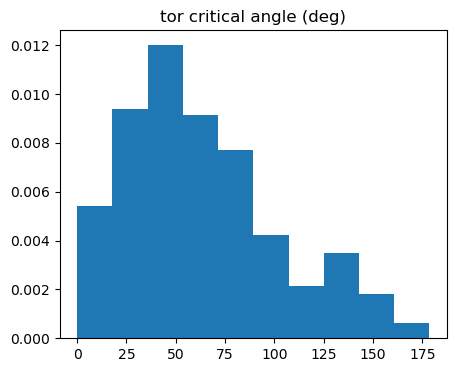

nontor
avg nontor critical angle: 65.21911087594003


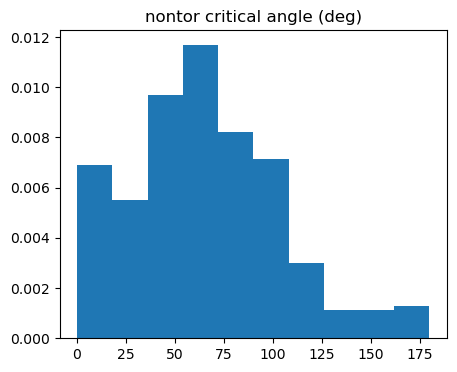

In [439]:
us = [inflow_u_categories_new, inflow_u_categories_new]
vs = [inflow_v_categories_new, inflow_v_categories_new]
cats = ['tor', 'nontor']
#eep = ['nf', 'nf', 'ff', 'ff']

critical_angle_df = pd.DataFrame()

for ucomp, vcomp, col in zip(us, vs, cats):
    u0 = np.array(ucomp[col].iloc[:, 0])
    v0 = np.array(vcomp[col].iloc[:, 0])

    u500 = np.array(ucomp[col].iloc[:, 50])
    v500 = np.array(vcomp[col].iloc[:, 50])

    #print(u[0])
    critical_angle_deg = compute_critical_angle(u0, v0, u500, v500, u0, v0)
    ca = pd.DataFrame()

    print(col)

    ca['tor or nontor'] = [col] * len(critical_angle_deg)
    ca['critical_angle'] = critical_angle_deg

    critical_angle_df = pd.concat([critical_angle_df, ca])
    
    print(f'avg {col} critical angle: {np.nanmean(critical_angle_deg)}')
    
    fig = plt.figure(figsize=(5,4))
    counts, bins = np.histogram(critical_angle_deg, density=True)
    plt.hist(bins[:-1], bins, weights=counts)
    #plt.boxplot([avg_omega_s_percent_2km])
    plt.title(f'{col} critical angle (deg)')
    plt.show()

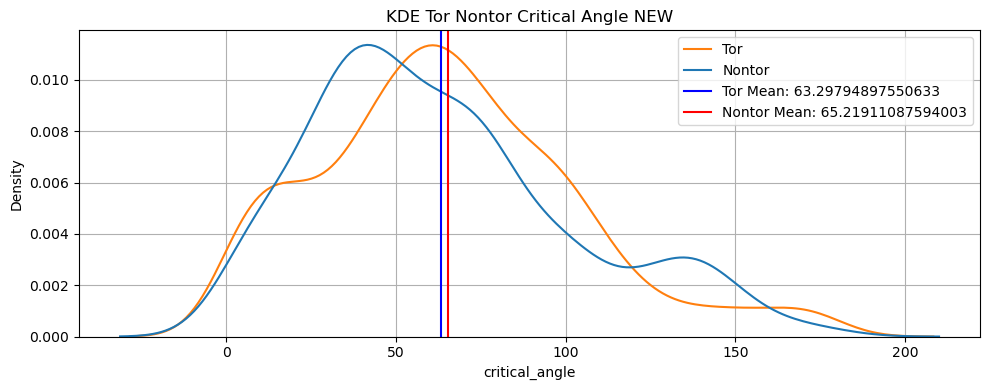

In [445]:
#plt.figure(figsize = (12, 4))
df = critical_angle_df
fig = plt.figure(figsize=(10, 4))
p = sns.kdeplot(df, x='critical_angle', hue='tor or nontor', common_norm=False, label = 'Critical Angle')
                
plt.title('KDE Tor Nontor Critical Angle NEW')

x = np.nanmean(df[df['tor or nontor'] == 'tor']['critical_angle'])
y = np.nanmean(df[df['tor or nontor'] == 'nontor']['critical_angle'])
plt.axvline(x, color='blue', label='Mean Tor')
plt.axvline(x=y, color='red', label='Mean Nontor')
plt.grid()
plt.tight_layout()
plt.legend(['Tor', 'Nontor',f'Tor Mean: {x}', f'Nontor Mean: {y}'])
plt.show()

# Noncomposited avg hodographs

In [ ]:
tor_u_nf = np.nanmean(nf_u_categories['tor'].iloc[:, :196], axis=0)
tor_v_nf = np.nanmean(nf_v_categories['tor'].iloc[:, :196], axis=0)

pretor_u_nf = np.nanmean(nf_u_categories['pretor'].iloc[:, :196], axis=0)
pretor_v_nf = np.nanmean(nf_v_categories['pretor'].iloc[:, :196], axis=0)

dtor_u_nf = np.nanmean(nf_u_categories['dtor'].iloc[:, :196], axis=0)
dtor_v_nf = np.nanmean(nf_v_categories['dtor'].iloc[:, :196], axis=0)

posttor_u_nf = np.nanmean(nf_u_categories['posttor'].iloc[:, :196], axis=0)
posttor_v_nf = np.nanmean(nf_v_categories['posttor'].iloc[:, :196], axis=0)

nontor_u_nf = np.nanmean(nf_u_categories['nontor'].iloc[:, :196], axis=0)
nontor_v_nf = np.nanmean(nf_v_categories['nontor'].iloc[:, :196], axis=0)

In [ ]:
tor_u_ff = np.nanmean(ff_u_categories['tor'].iloc[:, :196], axis=0)
tor_v_ff = np.nanmean(ff_v_categories['tor'].iloc[:, :196], axis=0)

pretor_u_ff = np.nanmean(ff_u_categories['pretor'].iloc[:, :196], axis=0)
pretor_v_ff = np.nanmean(ff_v_categories['pretor'].iloc[:, :196], axis=0)

dtor_u_ff = np.nanmean(ff_u_categories['dtor'].iloc[:, :196], axis=0)
dtor_v_ff = np.nanmean(ff_v_categories['dtor'].iloc[:, :196], axis=0)

posttor_u_ff = np.nanmean(ff_u_categories['posttor'].iloc[:, :196], axis=0)
posttor_v_ff = np.nanmean(ff_v_categories['posttor'].iloc[:, :196], axis=0)

nontor_u_ff = np.nanmean(ff_u_categories['nontor'].iloc[:, :196], axis=0)
nontor_v_ff = np.nanmean(ff_v_categories['nontor'].iloc[:, :196], axis=0)

In [ ]:
tor_u_nf_new = np.nanmean(nf_u_categories_new['tor'].iloc[:, :196], axis=0)
tor_v_nf_new = np.nanmean(nf_v_categories_new['tor'].iloc[:, :196], axis=0)

pretor_u_nf_new = np.nanmean(nf_u_categories_new['pretor'].iloc[:, :196], axis=0)
pretor_v_nf_new = np.nanmean(nf_v_categories_new['pretor'].iloc[:, :196], axis=0)

dtor_u_nf_new = np.nanmean(nf_u_categories_new['dtor'].iloc[:, :196], axis=0)
dtor_v_nf_new = np.nanmean(nf_v_categories_new['dtor'].iloc[:, :196], axis=0)

posttor_u_nf_new = np.nanmean(nf_u_categories_new['posttor'].iloc[:, :196], axis=0)
posttor_v_nf_new = np.nanmean(nf_v_categories_new['posttor'].iloc[:, :196], axis=0)

nontor_u_nf_new = np.nanmean(nf_u_categories_new['nontor'].iloc[:, :196], axis=0)
nontor_v_nf_new = np.nanmean(nf_v_categories_new['nontor'].iloc[:, :196], axis=0)

In [ ]:
tor_u_ff_new = np.nanmean(ff_u_categories_new['tor'].iloc[:, :196], axis=0)
tor_v_ff_new = np.nanmean(ff_v_categories_new['tor'].iloc[:, :196], axis=0)

pretor_u_ff_new = np.nanmean(ff_u_categories_new['pretor'].iloc[:, :196], axis=0)
pretor_v_ff_new = np.nanmean(ff_v_categories_new['pretor'].iloc[:, :196], axis=0)

dtor_u_ff_new = np.nanmean(ff_u_categories_new['dtor'].iloc[:, :196], axis=0)
dtor_v_ff_new = np.nanmean(ff_v_categories_new['dtor'].iloc[:, :196], axis=0)

posttor_u_ff_new = np.nanmean(ff_u_categories_new['posttor'].iloc[:, :196], axis=0)
posttor_v_ff_new = np.nanmean(ff_v_categories_new['posttor'].iloc[:, :196], axis=0)

nontor_u_ff_new = np.nanmean(ff_u_categories_new['nontor'].iloc[:, :196], axis=0)
nontor_v_ff_new = np.nanmean(ff_v_categories_new['nontor'].iloc[:, :196], axis=0)

In [ ]:
hodo_plot([tor_u_nf, pretor_u_nf, dtor_u_nf, posttor_u_nf, nontor_u_nf], [tor_u_ff, pretor_v_nf, dtor_v_nf, posttor_v_nf, 
                                                                             nontor_v_nf], heights, 25, 
    'Near-Field Composites (No Comp Prior)', ['black', 'tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['All Tor', 'Pre Tornadic', 'Tornadic', 'Post Tornadic', 'Nontornadic'], 5, 30, 'lower left', 8,8)

In [ ]:
hodo_plot([tor_u_ff, pretor_u_ff, dtor_u_ff, posttor_u_ff, nontor_u_ff], [tor_v_ff, pretor_v_ff, dtor_v_ff, posttor_v_ff, 
                                                                             nontor_v_ff], heights, 25, 
    'Far-Field Composites', ['black', 'tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['All Tor', 'Pre Tornadic', 'Tornadic', 'Post Tornadic', 'Nontornadic'], 5, 30, 'lower left', 8,8)

In [ ]:
hodo_plot([pretor_u_nf_new, dtor_u_nf_new, posttor_u_nf_new, nontor_u_nf_new], [pretor_v_nf_new, dtor_v_nf_new, posttor_v_nf_new, 
                                                                             nontor_v_nf_new], heights, 25, 
    'Near-Field Composites (No Comp Prior) New 2ndTrip', ['tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['Pre Tornadic', 'Tornadic', 'Post Tornadic', 'Nontornadic'], 5, 25, 'lower left', 8,8)

In [ ]:
hodo_plot([pretor_u_ff_new, dtor_u_ff_new, posttor_u_ff_new, nontor_u_ff_new], [pretor_v_ff_new, dtor_v_ff_new, posttor_v_nf_new, 
                                                                             nontor_v_nf_new], heights, 25, 
    'Far-Field Composites (No Comp Prior) New 2ndTrip', ['tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['Pre Tornadic', 'During Tornadic', 'Post Tornadic', 'Nontornadic'], 5, 25, 'lower right', 8,8)

# Compositing cases

In [225]:
#csv_name = f'cases/case_dfs/new/{d}_uv_{ka}_all.csv'
nf_dist = 20
ff_dist = 20
angle0 = 0
angle1 = 90
angle2 = 315
tor_time = 0

In [226]:
comp_tor_all_nodist = pd.DataFrame()
comp_nontor_all_nodist = pd.DataFrame()

comp_tor_all = pd.DataFrame()
comp_nontor_all = pd.DataFrame()

for ka in kas:
    for d in dates:
        comp_tor_nodist, comp_nontor_nodist, comp_tor, comp_nontor = comp_per_case(f'case_dfs/new/{d}_uv_{ka}_all.csv', ka, d, nf_dist, ff_dist, angle0, angle1, angle2, tor_time)
        #comp_tor['Tor or Nontor'] = 'tor'
        #comp_nontor['Tor or Nontor'] = 'nontor'

        comp_tor_all_nodist = pd.concat([comp_tor_all_nodist, comp_tor_nodist])
        comp_nontor_all_nodist = pd.concat([comp_nontor_all_nodist, comp_nontor_nodist])
        
        comp_tor_all = pd.concat([comp_tor_all, comp_tor])
        comp_nontor_all = pd.concat([comp_nontor_all, comp_nontor])

case_dfs/new/20220523_uv_ka1_all.csv
CSV size: (192, 201)
case_dfs/new/20220524_uv_ka1_all.csv
CSV size: (134, 201)
case_dfs/new/20220611_uv_ka1_all.csv
CSV size: (180, 201)
case_dfs/new/20230524_uv_ka1_all.csv
File not found: case_dfs/new/20230524_uv_ka1_all.csv
case_dfs/new/20230527_uv_ka1_all.csv
CSV size: (572, 201)
case_dfs/new/20230601_uv_ka1_all.csv
File not found: case_dfs/new/20230601_uv_ka1_all.csv
case_dfs/new/20230609_uv_ka1_all.csv
CSV size: (392, 201)
case_dfs/new/20230611_uv_ka1_all.csv
CSV size: (572, 201)
case_dfs/new/20230612_uv_ka1_all.csv
File not found: case_dfs/new/20230612_uv_ka1_all.csv
case_dfs/new/20230613_uv_ka1_all.csv
CSV size: (206, 201)
case_dfs/new/20230615_uv_ka1_all.csv
CSV size: (1974, 201)
case_dfs/new/20240427_uv_ka1_all.csv
CSV size: (388, 201)
case_dfs/new/20240501_uv_ka1_all.csv
CSV size: (1134, 201)
case_dfs/new/20240502_uv_ka1_all.csv
CSV size: (834, 201)
case_dfs/new/20240504_uv_ka1_all.csv
CSV size: (1134, 201)
case_dfs/new/20240506_uv_ka1_al

In [196]:
comp_tor_all_nodist_new = pd.DataFrame()
comp_nontor_all_nodist_new = pd.DataFrame()

comp_tor_all_new = pd.DataFrame()
comp_nontor_all_new = pd.DataFrame()

for ka in kas:
    for d in dates:
        for file in glob.glob(f'case_dfs/new/new_secondtrip/*/{d}_uv_{ka}_all.csv'):
            comp_tor_nodist_new, comp_nontor_nodist_new, comp_tor_new, comp_nontor_new = comp_per_case(file, ka, d, nf_dist, ff_dist, angle0, angle1, angle2, tor_time)
            # comp_tor_new['Tor or Nontor'] = 'tor'
            # comp_nontor_new['Tor or Nontor'] = 'nontor'

            print(len(comp_tor_new.columns))

            #comp_tor_new.insert(len(comp_tor_new.columns), 'Tor or Nontor', 'tor')
            #comp_nontor_new.insert(len(comp_nontor_new.columns), 'Tor or Nontor', 'nontor')

            comp_tor_all_nodist_new = pd.concat([comp_tor_all_nodist_new, comp_tor_nodist_new])
            comp_nontor_all_nodist_new = pd.concat([comp_nontor_all_nodist_new, comp_nontor_nodist_new])
            
            comp_tor_all_new = pd.concat([comp_tor_all_new, comp_tor_new])
            comp_nontor_all_new = pd.concat([comp_nontor_all_new, comp_nontor_new])

case_dfs/new/new_secondtrip/tornadic/20220523_uv_ka1_all.csv
CSV size: (120, 201)
199
case_dfs/new/new_secondtrip/nontornadic/20220524_uv_ka1_all.csv
CSV size: (100, 201)
0
case_dfs/new/new_secondtrip/tornadic/20230527_uv_ka1_all.csv
CSV size: (506, 201)
199
case_dfs/new/new_secondtrip/nontornadic/20230611_uv_ka1_all.csv
CSV size: (388, 201)
0
case_dfs/new/new_secondtrip/nontornadic/20230613_uv_ka1_all.csv
CSV size: (20, 201)
0
case_dfs/new/new_secondtrip/tornadic/20230615_uv_ka1_all.csv
CSV size: (572, 201)
199
case_dfs/new/new_secondtrip/nontornadic/20240427_uv_ka1_all.csv
CSV size: (314, 201)
0
case_dfs/new/new_secondtrip/nontornadic/20240501_uv_ka1_all.csv
CSV size: (850, 201)
0
case_dfs/new/new_secondtrip/tornadic/20240502_uv_ka1_all.csv
CSV size: (784, 201)
199
case_dfs/new/new_secondtrip/nontornadic/20240504_uv_ka1_all.csv
CSV size: (780, 201)
0
case_dfs/new/new_secondtrip/nontornadic/20240528_uv_ka1_all.csv
CSV size: (1050, 201)
0
case_dfs/new/new_secondtrip/tornadic/20240602_u

In [227]:
comp_tor_all_nodist.dropna(inplace=True)
comp_tor_all_nodist_new.dropna(inplace=True)

comp_nontor_all_nodist.dropna(inplace=True)
comp_nontor_all_nodist_new.dropna(inplace=True)

In [ ]:
comp_tor_all.date.value_counts()

In [228]:
comp_tor_all.dropna(inplace=True)

In [ ]:
comp_tor_all.date.value_counts()

In [229]:
comp_nontor_all.dropna(inplace=True)

In [ ]:
comp_nontor_all.date.value_counts()

In [ ]:
comp_tor_all_new.date.value_counts()

In [230]:
comp_tor_all_new.dropna(inplace=True)

In [231]:
comp_nontor_all_new.dropna(inplace=True)

In [ ]:
comp_tor_all_new.date.value_counts()

In [ ]:
comp_tor_all_new.label.value_counts()

In [ ]:
comp_tor_all_new

In [203]:
def comp_srh(u,v):
    '''
    Computes storm-relative helicity at every height then takes the sum for total SRH
    u,v = composite u,v values for desired location up to desired height
    u and v MUST BE STORM RELATIVE, this function does not account for storm motion in equations
    '''
    srh = []
    for i in np.arange(0, 194):
        
        a = np.nanprod([u.iloc[:, i+1], v.iloc[:, i]], axis=0)
        b = -np.nanprod([u.iloc[:, i], v.iloc[:, i+1]],axis=0)
        
        srh0 = np.nansum([a, b], axis=0)
        srh.append(srh0)
        
    srh_array = np.array(srh)
    srh_total = np.nansum(srh_array) # total srh
        
    return srh

In [204]:
def comp_srh_nan(u,v):
    '''
    Computes storm-relative helicity at every height then takes the sum for total SRH
    u,v = composite u,v values for desired location up to desired height
    u and v MUST BE STORM RELATIVE, this function does not account for storm motion in equations
    '''
    srh = []
    for i in range(len(u)-1):
        a = np.nanprod([u[i+1], v[i]], axis=0) 
        b = -np.nanprod([u[i], v[i+1]], axis=0)
        srh0 = np.nansum([a,b], axis=0)
        srh.append(srh0) # srh at each height

    srh_array = np.array(srh)
    srh_total = np.nansum(srh_array) # total srh
        
    return srh_total

In [246]:
def srh_spatial_pert(comp_nontor_all_new, label):
    
    dates_eh = sorted(set(comp_nontor_all_new['date'].values))
    print(np.shape(dates_eh))
    print(dates_eh)
    nontor_srh_df_new = pd.DataFrame()
    nontor_winds_new = pd.DataFrame()
    nontor_both_date = []
    
    for d in dates_eh:
        print(d)
        comp_date = comp_nontor_all_new[comp_nontor_all_new['date'] == d]
        
        #if (comp_date['label'].eq('nontor nf').any()) or (comp_date['label'].eq('nontor ff').any()):
        if (comp_date['label'].eq(f'{label} ff').any()) and (comp_date['label'].eq(f'{label} nf').any()):
    
            nontor_nf_ff = pd.DataFrame()
    
            #print(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'nontor nf')].iloc[:, :50].values)
    
            u_nf500 = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == f'{label} nf')].iloc[:, :50].values, axis=0)
            v_nf500 = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == f'{label} nf')].iloc[:, :50].values, axis=0)
            u_ff500 = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == f'{label} ff')].iloc[:, :50].values, axis=0)
            v_ff500 = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == f'{label} ff')].iloc[:, :50].values, axis=0)
    
            u_nf1 = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == f'{label} nf')].iloc[:, :100].values, axis=0)
            v_nf1 = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == f'{label} nf')].iloc[:, :100].values, axis=0)
            u_ff1 = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == f'{label} ff')].iloc[:, :100].values, axis=0)
            v_ff1 = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == f'{label} ff')].iloc[:, :100].values, axis=0)
            
            u_nf = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == f'{label} nf')].iloc[:, :196].values, axis=0)
            v_nf = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == f'{label} nf')].iloc[:, :196].values, axis=0)
            u_ff = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == f'{label} ff')].iloc[:, :196].values, axis=0)
            v_ff = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == f'{label} ff')].iloc[:, :196].values, axis=0)
    
            #nontor_nf_ff = pd.DataFrame([d, u_nf, v_nf, u_ff, v_ff], columns = ['Date', 'NF_u_mean', 'NF_v_mean', 'FF_u_mean', 'FF_v_mean']).T
    
            #nontor_nf_ff = pd.DataFrame([d], [u_nf], [v_nf], [u_ff], [v_ff], index = [0,1,2,3,4])#, columns = ['Date', 'NF_u_mean', 'NF_v_mean', 'FF_u_mean', 'FF_v_mean'])
            
            #nontor_nf_ff['Date'] = [d]
            # nontor_nf_ff['NF_u_mean'] = [u_nf]
            # nontor_nf_ff['NF_v_mean'] = [v_nf]
            # nontor_nf_ff['FF_u_mean'] = [u_ff]
            # nontor_nf_ff['FF_v_mean'] = [v_ff]
    
    
            nontor_nf_ff['Date'] = [d] * len(u_nf)
    
            nontor_nf_ff['NF_u_mean_0-500m'] = pd.Series(u_nf500)
            nontor_nf_ff['NF_v_mean_0-500m'] = pd.Series(v_nf500)
            nontor_nf_ff['FF_u_mean_0-500m'] = pd.Series(u_ff500)
            nontor_nf_ff['FF_v_mean_0-500m'] = pd.Series(v_ff500)
    
            nontor_nf_ff['NF_u_mean_0-1km'] = pd.Series(u_nf1)
            nontor_nf_ff['NF_v_mean_0-1km'] = pd.Series(v_nf1)
            nontor_nf_ff['FF_u_mean_0-1km'] = pd.Series(u_ff1)
            nontor_nf_ff['FF_v_mean_0-1km'] = pd.Series(v_ff1)
            
            nontor_nf_ff['NF_u_mean_0-2km'] = pd.Series(u_nf)
            nontor_nf_ff['NF_v_mean_0-2km'] = pd.Series(v_nf)
            nontor_nf_ff['FF_u_mean_0-2km'] = pd.Series(u_ff)
            nontor_nf_ff['FF_v_mean_0-2km'] = pd.Series(v_ff)
    
            nontor_winds_new = pd.concat([nontor_winds_new, nontor_nf_ff])
            #nontor_both_date.append(d)
            
            delta_u = u_ff - u_nf
            delta_v = v_ff - v_nf
            
            hodo_plot([u_nf, u_ff, delta_u], [v_nf, v_ff, delta_v], heights, 25, f'{label} Composites Pert {d}', 
                      ['tab:blue', 'tab:red', 'tab:purple'], ['NF', 'FF', 'Diff'], 10, 30, 'upper left',5,5)
    
            nf_srh500 = comp_srh_nan(u_nf500, v_nf500)
            ff_srh500 = comp_srh_nan(u_ff500, v_ff500)
    
            nf_srh1 = comp_srh_nan(u_nf1, v_nf1)
            ff_srh1 = comp_srh_nan(u_ff1, v_ff1)
    
            nf_srh = comp_srh_nan(u_nf, v_nf)
            ff_srh = comp_srh_nan(u_ff, v_ff)
    
            delta_srh500 = nf_srh500 - ff_srh500
            delta_srh1 = nf_srh1 - ff_srh1
            delta_srh2 = nf_srh - ff_srh
            
            print(f'nf_srh-ff_srh = {delta_srh}')
    
            # nf_srh = comp_srh_nan(u_nf, v_nf)
            # ff_srh = comp_srh_nan(u_ff, v_ff)
            
            # delta_srh = nf_srh - ff_srh
            # print(f'nf_srh-ff_srh = {delta_srh}')
    
            nontor_srh = pd.DataFrame()
    
            
            nontor_srh['Date'] = [d]
            
            nontor_srh['NF_SRH_0-500m'] = [nf_srh500]
            nontor_srh['FF_SRH_0-500m'] = [ff_srh500]
            
            nontor_srh['NF_SRH_0-1km'] = [nf_srh1]
            nontor_srh['FF_SRH_0-1km'] = [ff_srh1]
            
            nontor_srh['NF_SRH_0-2km'] = [nf_srh]
            nontor_srh['FF_SRH_0-2km'] = [ff_srh]
    
            nontor_srh['delta_SRH_0-500m'] = [delta_srh500]
            nontor_srh['delta_SRH_0-1km'] = [delta_srh1]
            nontor_srh['delta_SRH_0-2km'] = [delta_srh2]
            
            nontor_srh_df_new = pd.concat([nontor_srh_df_new, nontor_srh])
            
    
        else:
            continue

    return nontor_winds_new, nontor_srh_df_new

(10,)
['20220524', '20230609', '20230611', '20230612', '20230613', '20240427', '20240501', '20240502', '20240504', '20240528']
20220524


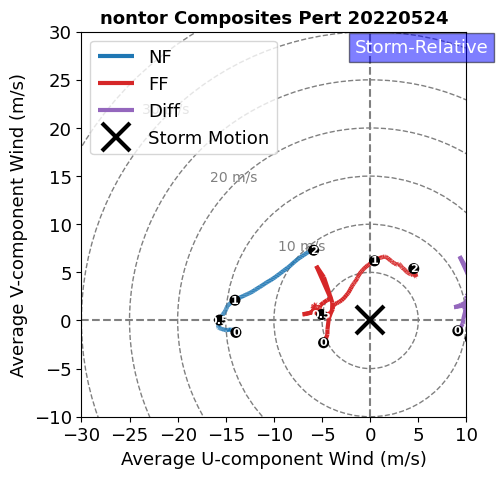

nf_srh-ff_srh = 81.06520805041403
20230609
20230611
20230612
20230613
20240427
20240501
20240502
20240504


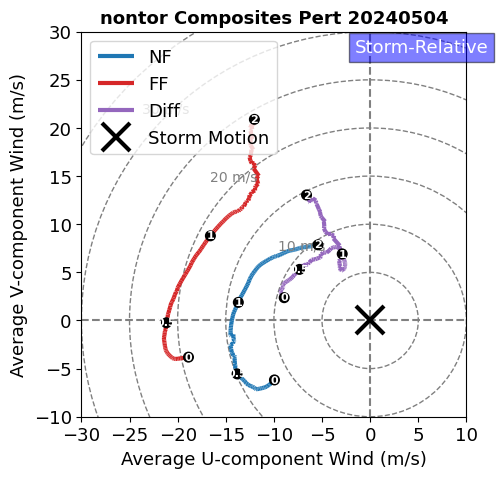

nf_srh-ff_srh = 81.06520805041403
20240528


In [247]:
nontor_winds, nontor_srh_df = srh_spatial_pert(comp_nontor_all, 'nontor')

(7,)
['20220524', '20230611', '20230613', '20240427', '20240501', '20240504', '20240528']
20220524


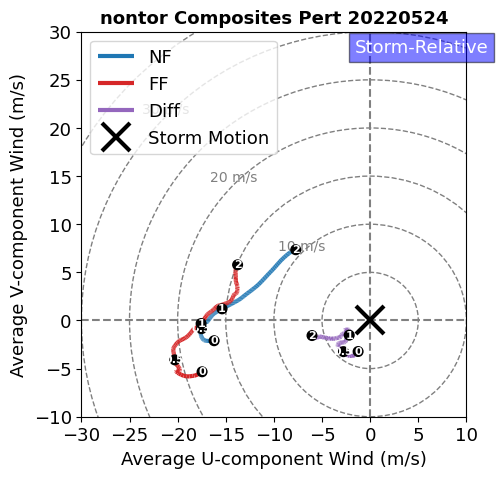

nf_srh-ff_srh = 81.06520805041403
20230611
20230613
20240427
20240501
20240504


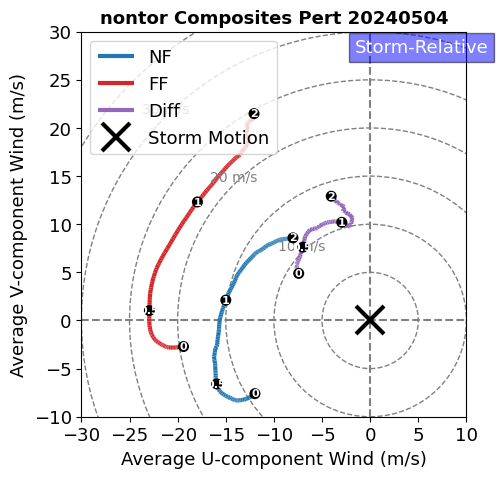

nf_srh-ff_srh = 81.06520805041403
20240528


In [248]:
nontor_winds_new, nontor_srh_df_new = srh_spatial_pert(comp_nontor_all_new, 'nontor')

In [213]:
nontor_winds_new

,Date,NF_u_mean_0-500m,NF_v_mean_0-500m,FF_u_mean_0-500m,FF_v_mean_0-500m,NF_u_mean_0-1km,NF_v_mean_0-1km,FF_u_mean_0-1km,FF_v_mean_0-1km,NF_u_mean_0-2km,NF_v_mean_0-2km,FF_u_mean_0-2km,FF_v_mean_0-2km
0,20220524,-16.211269,-2.104942,-17.461899,-5.331043,-16.211269,-2.104942,-17.461899,-5.331043,-16.211269,-2.104942,-17.461899,-5.331043
1,20220524,-16.321700,-2.108024,-17.625797,-5.440126,-16.321700,-2.108024,-17.625797,-5.440126,-16.321700,-2.108024,-17.625797,-5.440126
2,20220524,-16.415494,-2.111213,-17.773840,-5.546739,-16.415494,-2.111213,-17.773840,-5.546739,-16.415494,-2.111213,-17.773840,-5.546739
3,20220524,-16.494933,-2.114390,-17.926640,-5.618486,-16.494933,-2.114390,-17.926640,-5.618486,-16.494933,-2.114390,-17.926640,-5.618486
4,20220524,-16.670186,-2.121468,-18.257471,-5.741157,-16.670186,-2.121468,-18.257471,-5.741157,-16.670186,-2.121468,-18.257471,-5.741157
...,...,...,...,...,...,...,...,...,...,...,...,...,...
191,20240504,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-8.268741,8.560544,-12.171419,21.314415
192,20240504,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-8.207514,8.568481,-12.141907,21.356755
193,20240504,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-8.150803,8.571980,-12.116908,21.398632
194,20240504,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-8.073345,8.572028,-12.087549,21.448270


In [214]:
nontor_srh_df_new

,Date,NF_SRH_0-500m,FF_SRH_0-500m,NF_SRH_0-1km,FF_SRH_0-1km,NF_SRH_0-2km,FF_SRH_0-2km,delta_SRH_0-500m,delta_SRH_0-1km,delta_SRH_0-2km
0,20220524,27.440177,48.037298,62.606249,119.106119,160.111707,207.885130,-20.597121,-56.49987,-47.773423
0,20240504,58.597530,120.733977,196.903373,390.142054,317.558591,600.589736,-62.136448,-193.23868,-283.031145


(4,)
['20220523', '20230524', '20230527', '20230615']
20220523


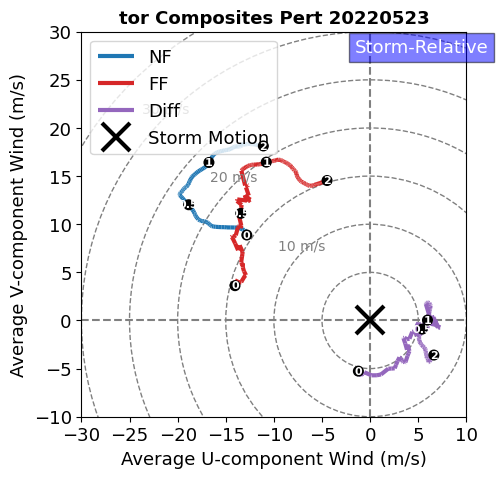

nf_srh-ff_srh = 81.06520805041403
20230524


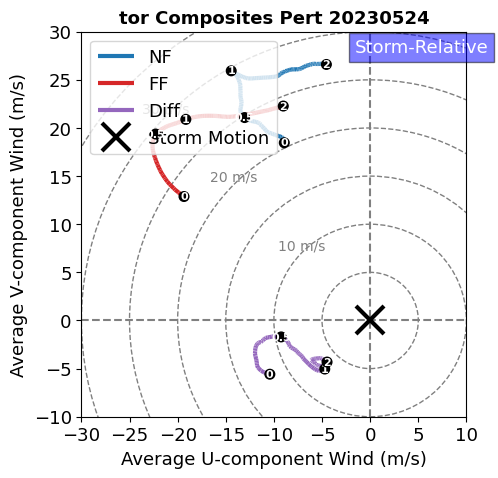

nf_srh-ff_srh = 81.06520805041403
20230527


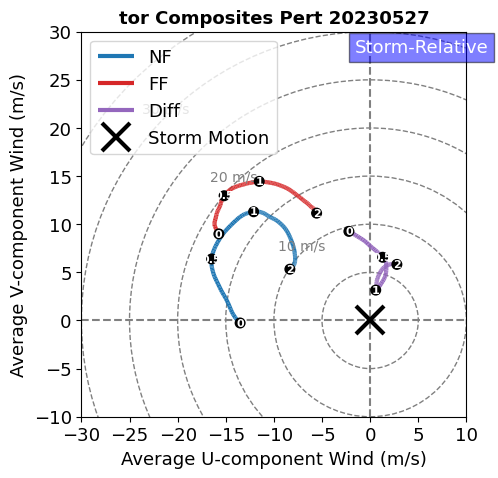

nf_srh-ff_srh = 81.06520805041403
20230615


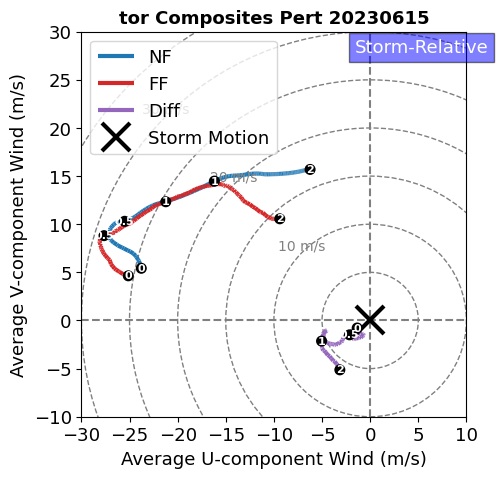

nf_srh-ff_srh = 81.06520805041403


In [249]:
tor_winds, tor_srh_df = srh_spatial_pert(comp_tor_all, 'tor')

In [250]:
tor_srh_df

,Date,NF_SRH_0-500m,FF_SRH_0-500m,NF_SRH_0-1km,FF_SRH_0-1km,NF_SRH_0-2km,FF_SRH_0-2km,delta_SRH_0-500m,delta_SRH_0-1km,delta_SRH_0-2km
0,20220523,-3.347437,118.619547,122.923971,222.737097,235.533044,296.370871,-121.966984,-99.813126,-60.837827
0,20230524,-55.492136,106.664290,-21.650038,203.228556,234.456346,429.680657,-162.156426,-224.878594,-195.224311
0,20230527,103.201328,77.630548,215.875367,146.532351,201.745787,197.115362,25.570780,69.343015,4.630425
0,20230615,128.637149,104.710615,337.088306,270.042379,486.471230,393.502120,23.926534,67.045927,92.969110


(5,)
['20220523', '20230524', '20230527', '20230615', '20240502']
20220523


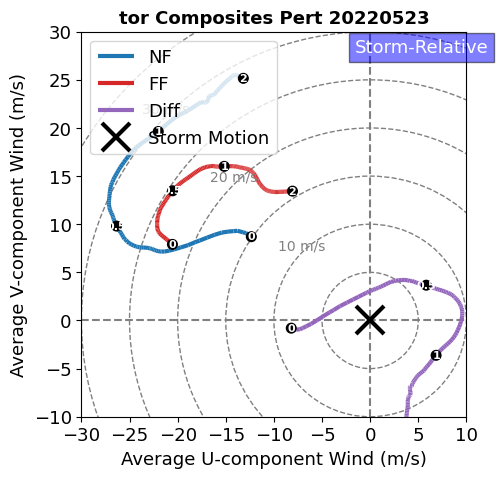

nf_srh-ff_srh = 81.06520805041403
20230524


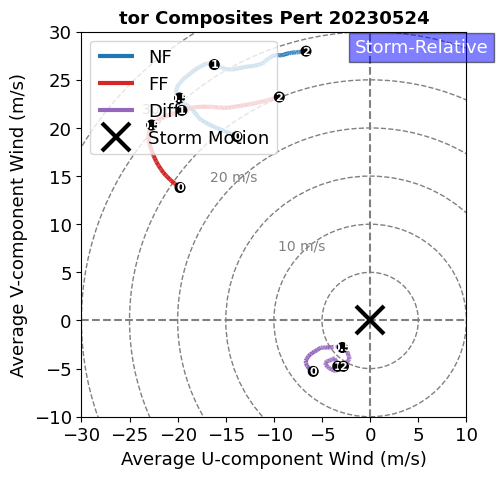

nf_srh-ff_srh = 81.06520805041403
20230527


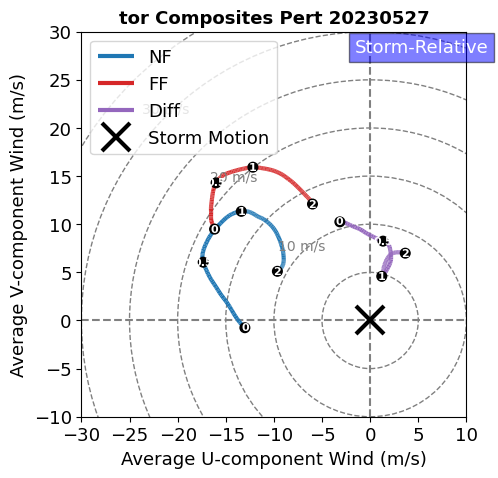

nf_srh-ff_srh = 81.06520805041403
20230615


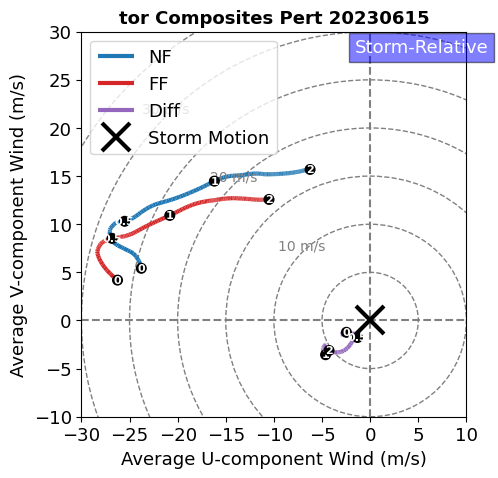

nf_srh-ff_srh = 81.06520805041403
20240502


In [251]:
tor_winds_new, tor_srh_df_new = srh_spatial_pert(comp_tor_all_new, 'tor')

In [281]:
tor_winds_new

,Date,NF_u_mean_0-500m,NF_v_mean_0-500m,FF_u_mean_0-500m,FF_v_mean_0-500m,NF_u_mean_0-1km,NF_v_mean_0-1km,FF_u_mean_0-1km,FF_v_mean_0-1km,NF_u_mean_0-2km,NF_v_mean_0-2km,FF_u_mean_0-2km,FF_v_mean_0-2km
0,20220523,-12.344266,8.704443,-20.542034,7.905432,-12.344266,8.704443,-20.542034,7.905432,-12.344266,8.704443,-20.542034,7.905432
1,20220523,-12.622243,8.931932,-20.661453,8.019386,-12.622243,8.931932,-20.661453,8.019386,-12.622243,8.931932,-20.661453,8.019386
2,20220523,-12.917190,9.078350,-20.770967,8.118554,-12.917190,9.078350,-20.770967,8.118554,-12.917190,9.078350,-20.770967,8.118554
3,20220523,-13.206150,9.160345,-20.880770,8.207498,-13.206150,9.160345,-20.880770,8.207498,-13.206150,9.160345,-20.880770,8.207498
4,20220523,-13.793958,9.317830,-21.105918,8.399336,-13.793958,9.317830,-21.105918,8.399336,-13.793958,9.317830,-21.105918,8.399336
...,...,...,...,...,...,...,...,...,...,...,...,...,...
191,20230615,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-6.466870,15.652995,-10.781869,12.555992
192,20230615,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-6.404276,15.664442,-10.708591,12.555545
193,20230615,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-6.355554,15.673253,-10.649879,12.562620
194,20230615,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-6.290848,15.683176,-10.568156,12.569808


In [252]:
tor_srh_df_new 

,Date,NF_SRH_0-500m,FF_SRH_0-500m,NF_SRH_0-1km,FF_SRH_0-1km,NF_SRH_0-2km,FF_SRH_0-2km,delta_SRH_0-500m,delta_SRH_0-1km,delta_SRH_0-2km
0,20220523,-63.252545,142.183192,287.536086,261.339203,555.745130,329.491259,-205.435737,26.196883,226.253871
0,20230524,-49.238890,106.812995,115.205667,207.053588,376.739620,443.232254,-156.051885,-91.847921,-66.492633
0,20230527,102.096054,90.349502,224.697435,170.354922,201.460597,226.280702,11.746553,54.342513,-24.820105
0,20230615,128.637149,126.238313,337.088306,248.068973,486.471230,393.011388,2.398836,89.019334,93.459842


In [283]:
comp_tor_all

,0,1,2,3,4,5,6,7,8,9,...,189,190,191,192,193,194,195,label,wind,date
0,-17.675563,-17.759223,-17.844112,-17.945688,-18.142540,-18.288173,-18.482250,-18.703929,-18.917583,-19.117120,...,-10.849187,-10.791745,-10.725623,-10.664890,-10.615111,-10.559332,-10.501205,tor nf,u,20220523
1,-19.417457,-19.504942,-19.597047,-19.689676,-19.871045,-19.983293,-20.107290,-20.248613,-20.367844,-20.463106,...,-11.597248,-11.537187,-11.470991,-11.407385,-11.348698,-11.289937,-11.229144,pretor nf,u,20220523
2,-8.966094,-9.030625,-9.079438,-9.225745,-9.500010,-9.812571,-10.357051,-10.980510,-11.666280,-12.387189,...,-7.108880,-7.064530,-6.998785,-6.952417,-6.947178,-6.906309,-6.861512,dtor nf,u,20220523
4,-8.661701,-8.499266,-8.819787,-8.789742,-8.850582,-8.848710,-9.216219,-8.516204,-8.345671,-8.478721,...,-4.310884,-4.201586,-4.075845,-3.940926,-3.838505,-3.739524,-3.655363,tor ff,u,20220523
6,-13.509306,-13.439182,-13.326493,-13.197410,-12.956265,-12.819045,-12.599030,-12.350593,-12.137135,-11.989006,...,-4.310884,-4.201586,-4.075845,-3.940926,-3.838505,-3.739524,-3.655363,dtor ff,u,20220523
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,-3.428794,-3.258692,-3.111029,-2.979482,-2.979482,-2.699847,-2.593692,-2.384253,-2.277408,-2.100453,...,3.667554,3.670474,3.676987,3.683270,3.687552,3.692393,3.697293,tor nf,v,20230615
59,-3.428794,-3.258692,-3.111029,-2.979482,-2.979482,-2.699847,-2.593692,-2.384253,-2.277408,-2.100453,...,3.667554,3.670474,3.676987,3.683270,3.687552,3.692393,3.697293,posttor nf,v,20230615
60,5.802230,5.898347,5.868304,5.875411,5.875581,6.070522,6.132616,6.224793,6.397855,6.717792,...,16.375790,16.361535,16.363706,16.343363,16.336204,16.342784,16.346952,tor ff,v,20230615
61,2.739384,2.901641,2.880067,2.857219,2.855071,2.995395,3.038776,2.987858,2.980432,3.112924,...,3.338198,3.316833,3.356203,3.299633,3.286698,3.320577,3.347785,pretor ff,v,20230615


In [282]:
dates_eh = sorted(set(comp_tor_all['date'].values))
#print(np.shape(dates_eh))
#print(dates_eh)
septor_srh_df = pd.DataFrame()

for d in dates_eh:
    #print(d)
    comp_date = comp_tor_all[comp_tor_all['date'] == d]
    
    if ((comp_date['label'].eq('pretor nf').any()) or (comp_date['label'].eq('pretor ff').any())) and ((comp_date['label'].eq('dtor nf').any()) or (comp_date['label'].eq('dtor ff').any())):

    #if ((comp_date['label'].eq('pretor nf').any()) and (comp_date['label'].eq('pretor ff').any())):

        print(d)
        
        pre_u_nf = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'pretor nf')].iloc[:, :196].values, axis=0)
        pre_v_nf = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'pretor nf')].iloc[:, :196].values, axis=0)
        pre_u_ff = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'pretor ff')].iloc[:, :196].values, axis=0)
        pre_v_ff = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'pretor ff')].iloc[:, :196].values, axis=0)

        d_u_nf = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'dtor nf')].iloc[:, :196].values, axis=0)
        d_v_nf = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'dtor nf')].iloc[:, :196].values, axis=0)
        d_u_ff = np.nanmean(comp_date[(comp_date['wind'] == 'u') & (comp_date['label'] == 'dtor ff')].iloc[:, :196].values, axis=0)
        d_v_ff = np.nanmean(comp_date[(comp_date['wind'] == 'v') & (comp_date['label'] == 'dtor ff')].iloc[:, :196].values, axis=0)
    
        pre_delta_u = pre_u_ff - pre_u_nf
        pre_delta_v = pre_v_ff - pre_v_nf

        d_delta_u = d_u_ff - d_u_nf
        d_delta_v = d_v_ff - d_v_nf
        
        # hodo_plot([pre_u_nf, pre_u_ff, predelta_u], [v_nf, v_ff, delta_v], heights, 25, f'Tor Composites Pert {d} NEW', 
        #           ['tab:blue', 'tab:red', 'tab:purple'], ['NF', 'FF', 'Diff'], 10, 30, 'lower left')

        pre_nf_srh = comp_srh_nan(pre_u_nf, pre_v_nf)
        pre_ff_srh = comp_srh_nan(pre_u_ff, pre_v_ff)

        d_nf_srh = comp_srh_nan(d_u_nf, d_v_nf)
        d_ff_srh = comp_srh_nan(d_u_ff, d_v_ff)
        
        pre_delta_srh = pre_nf_srh - pre_ff_srh
        d_delta_srh = d_nf_srh - d_ff_srh
        
        #print(f'nf_srh-ff_srh = {delta_srh}')

        tor_srh = pd.DataFrame()
        
        tor_srh['Date'] = [d]
        tor_srh['PRE_NF_SRH'] = [pre_nf_srh]
        tor_srh['PRE_FF_SRH'] = [pre_ff_srh]
        
        tor_srh['D_NF_SRH'] = [d_nf_srh]
        tor_srh['D_FF_SRH'] = [d_ff_srh]
        
        tor_srh['PRE_delta_SRH'] = [pre_delta_srh]
        tor_srh['D_delta_SRH'] = [d_delta_srh]
        
        septor_srh_df = pd.concat([septor_srh_df, tor_srh])
        

    else:
        continue

20220523
20230527
20230615


In [240]:
nontor_srh_df['delta_SRH_0-500m']

0    15.964787
0   -59.418242
Name: delta_SRH_0-500m, dtype: float64

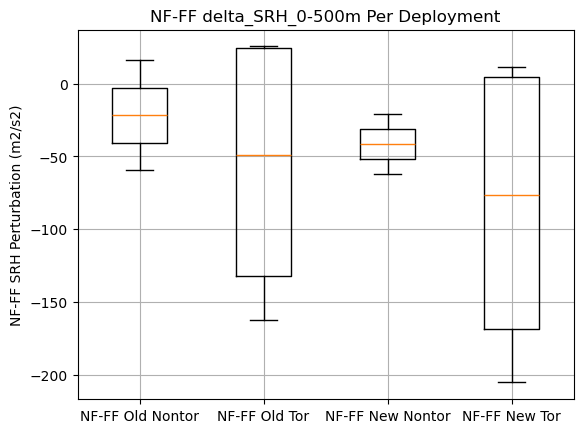

In [253]:
label = 'delta_SRH_0-500m'
plt.boxplot([nontor_srh_df[label], tor_srh_df[label], nontor_srh_df_new[label], tor_srh_df_new[label]],
           labels = ['NF-FF Old Nontor','NF-FF Old Tor', 'NF-FF New Nontor', 'NF-FF New Tor'])
plt.ylabel('NF-FF SRH Perturbation (m2/s2)')
plt.title(f'NF-FF {label} Per Deployment')
plt.grid()
plt.show()

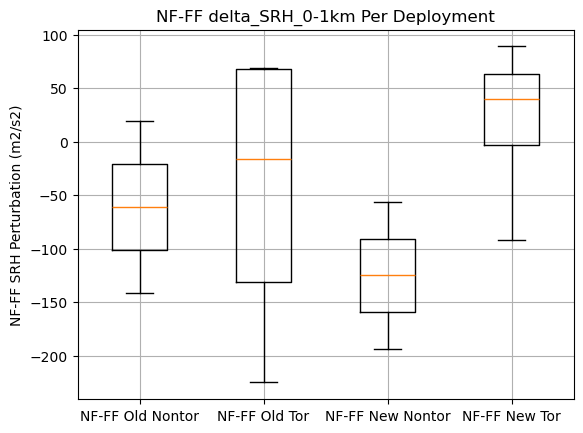

In [256]:
label = 'delta_SRH_0-1km'
plt.boxplot([nontor_srh_df[label], tor_srh_df[label], nontor_srh_df_new[label], tor_srh_df_new[label]],
           labels = ['NF-FF Old Nontor','NF-FF Old Tor', 'NF-FF New Nontor', 'NF-FF New Tor'])
plt.ylabel('NF-FF SRH Perturbation (m2/s2)')
plt.title(f'NF-FF {label} Per Deployment')
plt.grid()
plt.show()

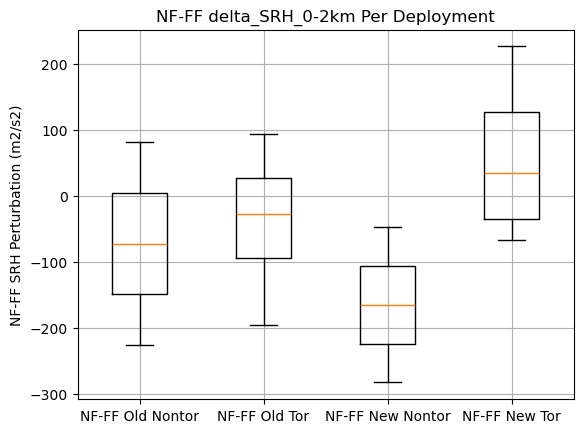

In [254]:
label = 'delta_SRH_0-2km'
plt.boxplot([nontor_srh_df[label], tor_srh_df[label], nontor_srh_df_new[label], tor_srh_df_new[label]],
           labels = ['NF-FF Old Nontor','NF-FF Old Tor', 'NF-FF New Nontor', 'NF-FF New Tor'])
plt.ylabel('NF-FF SRH Perturbation (m2/s2)')
plt.title(f'NF-FF {label} Per Deployment')
plt.grid()
plt.show()

In [288]:
old_2ndtrip = averaging_u_and_v(comp_tor_all, comp_nontor_all)
new_2ndtrip = averaging_u_and_v(comp_tor_all_new, comp_nontor_all_new)

In [ ]:
hodo_plot([old_2ndtrip['tor_u_nf'], old_2ndtrip['pretor_u_nf'], old_2ndtrip['dtor_u_nf'], old_2ndtrip['posttor_u_nf'], 
           old_2ndtrip['nontor_u_nf']], 
           [old_2ndtrip['tor_v_nf'], old_2ndtrip['pretor_v_nf'], old_2ndtrip['dtor_v_nf'], old_2ndtrip['posttor_v_nf'], old_2ndtrip['nontor_v_nf']], heights, 25, 
    'Near-Field Composites', ['black', 'tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['All Tornadic', 'Pre Tornadic', 'Tornadic', 'Post Tornadic', 'Nontornadic'], 5, 25, 'lower right', 6, 6)

In [ ]:
hodo_plot([old_2ndtrip['tor_u_nf'], old_2ndtrip['nontor_u_nf']], [old_2ndtrip['tor_v_nf'], old_2ndtrip['nontor_v_nf']], heights, 25, 
    'Near-Field Composites', ['tab:red', 'tab:blue'], 
    ['All Tornadic', 'All Nontornadic'], 5, 25, 'lower right', 6,6)

In [ ]:
hodo_plot([old_2ndtrip['pretor_u_ff'], old_2ndtrip['dtor_u_ff'], old_2ndtrip['posttor_u_ff'], old_2ndtrip['nontor_u_ff']], 
           [old_2ndtrip['pretor_v_ff'], old_2ndtrip['dtor_v_ff'], old_2ndtrip['posttor_v_ff'], old_2ndtrip['nontor_v_ff']], heights, 25, 
    'Far-Field Composites', ['tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['Pre Tornadic', 'Tornadic', 'Post Tornadic', 'Nontornadic'], 5, 30, 'lower right', 6,6)

In [ ]:
hodo_plot([old_2ndtrip['tor_u_ff'], old_2ndtrip['nontor_u_ff']], [old_2ndtrip['tor_v_ff'], old_2ndtrip['nontor_v_ff']], heights, 25, 
    'Far-Field Composites', ['tab:red', 'tab:blue'], 
    ['All Tornadic', 'Nontornadic'], 5, 25, 'lower left', 6,6)

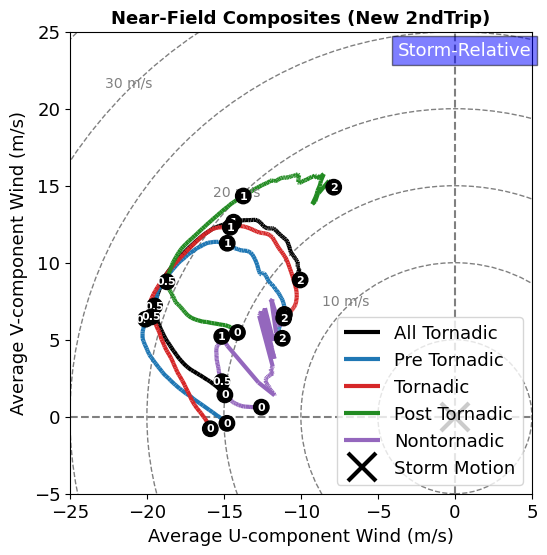

In [289]:
hodo_plot([new_2ndtrip['tor_u_nf'], new_2ndtrip['pretor_u_nf'], new_2ndtrip['dtor_u_nf'], new_2ndtrip['posttor_u_nf'], new_2ndtrip['nontor_u_nf']], 
           [new_2ndtrip['tor_v_nf'], new_2ndtrip['pretor_v_nf'], new_2ndtrip['dtor_v_nf'], new_2ndtrip['posttor_v_nf'], new_2ndtrip['nontor_v_nf']], heights, 25, 
    'Near-Field Composites (New 2ndTrip)', ['black', 'tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['All Tornadic', 'Pre Tornadic', 'Tornadic', 'Post Tornadic', 'Nontornadic'], 5, 25, 'lower right', 6,6)

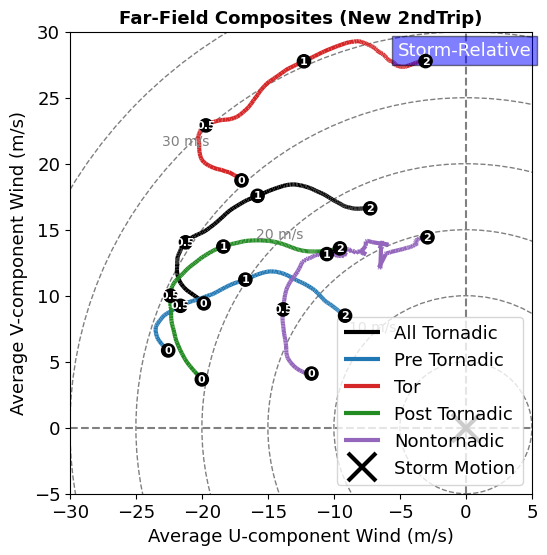

In [290]:
hodo_plot([new_2ndtrip['tor_u_ff'], new_2ndtrip['pretor_u_ff'], new_2ndtrip['dtor_u_ff'], new_2ndtrip['posttor_u_ff'], new_2ndtrip['nontor_u_ff']], 
           [new_2ndtrip['tor_v_ff'], new_2ndtrip['pretor_v_ff'],new_2ndtrip['dtor_v_ff'], new_2ndtrip['posttor_v_ff'], new_2ndtrip['nontor_v_ff']], heights, 25, 
    'Far-Field Composites (New 2ndTrip)', ['black', 'tab:blue', 'tab:red', 'forestgreen', 'tab:purple'], 
    ['All Tornadic','Pre Tornadic', 'Tor', 'Post Tornadic', 'Nontornadic'], 5, 30, 'lower right',6,6)

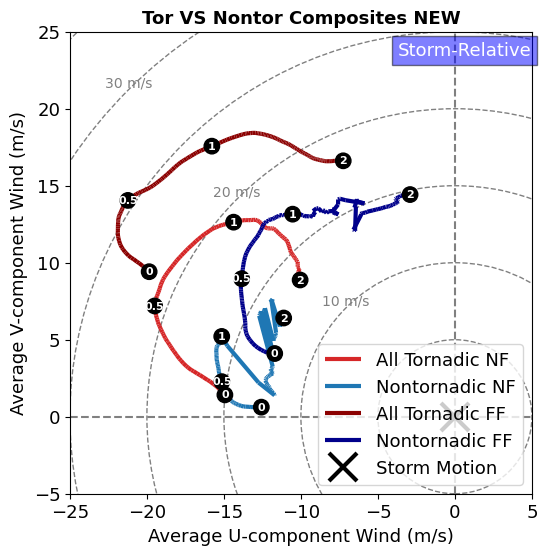

In [291]:
hodo_plot([new_2ndtrip['tor_u_nf'], new_2ndtrip['nontor_u_nf'], new_2ndtrip['tor_u_ff'], new_2ndtrip['nontor_u_ff']], 
          [new_2ndtrip['tor_v_nf'], new_2ndtrip['nontor_v_nf'], new_2ndtrip['tor_v_ff'], new_2ndtrip['nontor_v_ff']], heights, 25, 
    'Tor VS Nontor Composites NEW', ['tab:red', 'tab:blue', 'darkred', 'darkblue'], 
    ['All Tornadic NF', 'Nontornadic NF', 'All Tornadic FF', 'Nontornadic FF'], 5, 25, 'lower right', 6,6)

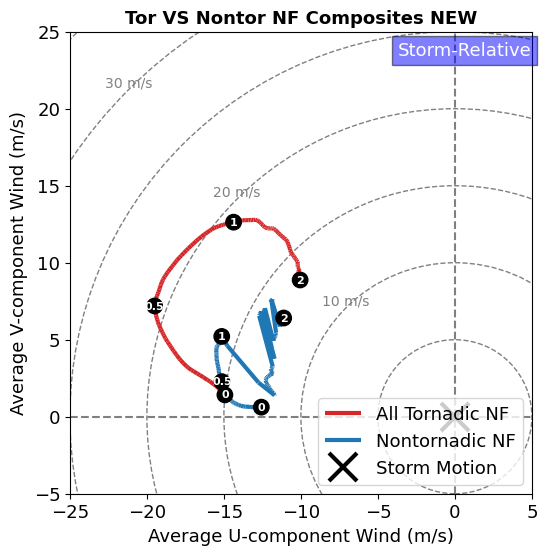

In [292]:
hodo_plot([new_2ndtrip['tor_u_nf'], new_2ndtrip['nontor_u_nf']], 
          [new_2ndtrip['tor_v_nf'], new_2ndtrip['nontor_v_nf']], heights, 25, 
    'Tor VS Nontor NF Composites NEW', ['tab:red', 'tab:blue'], 
    ['All Tornadic NF', 'Nontornadic NF'], 5, 25, 'lower right', 6,6)

In [ ]:
hodo_plot([new_2ndtrip['tor_u_ff'], new_2ndtrip['nontor_u_ff']], 
          [new_2ndtrip['tor_v_ff'], new_2ndtrip['nontor_v_ff']], heights, 25, 
    'Tor VS Nontor FF Composites NEW', ['tab:red', 'tab:blue'], 
    ['All Tornadic FF', 'Nontornadic FF'], 5, 25, 'lower right', 6,6)

In [ ]:
784/196

In [ ]:
tor_winds_new

In [285]:
tor_nf_u = tor_winds_new['NF_u_mean_0-2km']
tor_nf_v = tor_winds_new['NF_v_mean_0-2km']
tor_ff_u = tor_winds_new['FF_u_mean_0-2km']
tor_ff_v = tor_winds_new['FF_v_mean_0-2km']

avg_tor_nf_u = np.nansum([tor_nf_u.iloc[:196], tor_nf_u.iloc[196:392], tor_nf_u.iloc[392:588], tor_nf_u.iloc[588:]], axis=0) / 4
avg_tor_nf_v = np.nansum([tor_nf_v.iloc[:196], tor_nf_v.iloc[196:392], tor_nf_v.iloc[392:588], tor_nf_v.iloc[588:]], axis=0) / 4

avg_tor_ff_u = np.nansum([tor_ff_u.iloc[:196], tor_ff_u.iloc[196:392], tor_ff_u.iloc[392:588], tor_ff_u.iloc[588:]], axis=0) / 4
avg_tor_ff_v = np.nansum([tor_ff_v.iloc[:196], tor_ff_v.iloc[196:392], tor_ff_v.iloc[392:588], tor_ff_v.iloc[588:]], axis=0) / 4

In [286]:
nontor_nf_u = nontor_winds_new['NF_u_mean_0-2km']
nontor_nf_v = nontor_winds_new['NF_v_mean_0-2km']
nontor_ff_u = nontor_winds_new['FF_u_mean_0-2km']
nontor_ff_v = nontor_winds_new['FF_v_mean_0-2km']

avg_nontor_nf_u = np.nansum([nontor_nf_u.iloc[:196], nontor_nf_u.iloc[196:392]], axis=0)/ 2
avg_nontor_nf_v = np.nansum([nontor_nf_v.iloc[:196],nontor_nf_v.iloc[196:392]], axis=0) / 2

avg_nontor_ff_u = np.nansum([nontor_ff_u.iloc[:196],nontor_ff_u.iloc[196:392]], axis=0) / 2
avg_nontor_ff_v = np.nansum([nontor_ff_v.iloc[:196],nontor_ff_v.iloc[196:392]], axis=0) / 2

In [ ]:
np.shape(avg_tor_nf_u)

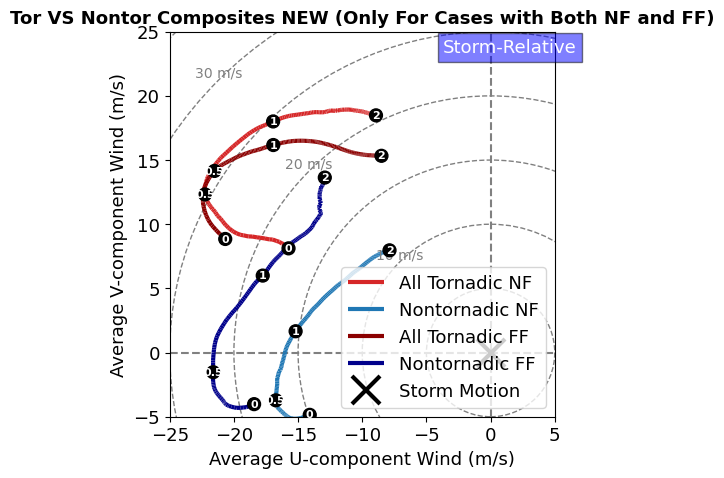

In [287]:
hodo_plot([avg_tor_nf_u, avg_nontor_nf_u, avg_tor_ff_u, avg_nontor_ff_u], 
          [avg_tor_nf_v, avg_nontor_nf_v, avg_tor_ff_v, avg_nontor_ff_v], heights, 25, 
    'Tor VS Nontor Composites NEW (Only For Cases with Both NF and FF)', ['tab:red', 'tab:blue', 'darkred', 'darkblue'], 
    ['All Tornadic NF', 'Nontornadic NF', 'All Tornadic FF', 'Nontornadic FF'], 5, 25, 'lower right', 5,5)

# Avg u and v SRW and SRH per VAD

SRW

Does this even mean anything? The average u and v component from 0-2km?

In [ ]:
def avg_u_and_v_per_vad(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, h0, htop):
    '''
    h0: height you want to get the u and v of
    htop: an area around that point to take the average of to make sure the selected point isnt messed up
    '''
        
    tor_u_nf_per = np.nanmean(nf_u_categories['tor'].iloc[:, h0:htop], axis=1)
    tor_v_nf_per = np.nanmean(nf_v_categories['tor'].iloc[:, h0:htop], axis=1)
    
    pretor_u_nf_per = np.nanmean(nf_u_categories['pretor'].iloc[:, h0:htop], axis=1)
    pretor_v_nf_per = np.nanmean(nf_v_categories['pretor'].iloc[:, h0:htop], axis=1)
    
    dtor_u_nf_per = np.nanmean(nf_u_categories['dtor'].iloc[:, h0:htop], axis=1)
    dtor_v_nf_per = np.nanmean(nf_v_categories['dtor'].iloc[:, h0:htop], axis=1)
    
    posttor_u_nf_per = np.nanmean(nf_u_categories['posttor'].iloc[:, h0:htop], axis=1)
    posttor_v_nf_per = np.nanmean(nf_v_categories['posttor'].iloc[:, h0:htop], axis=1)
    
    nontor_u_nf_per = np.nanmean(nf_u_categories['nontor'].iloc[:, h0:htop], axis=1)
    nontor_v_nf_per = np.nanmean(nf_v_categories['nontor'].iloc[:, h0:htop], axis=1)

    tor_u_ff_per = np.nanmean(ff_u_categories['tor'].iloc[:, h0:htop], axis=1)
    tor_v_ff_per = np.nanmean(ff_v_categories['tor'].iloc[:, h0:htop], axis=1)

    pretor_u_ff_per = np.nanmean(ff_u_categories['pretor'].iloc[:, h0:htop], axis=1)
    pretor_v_ff_per = np.nanmean(ff_v_categories['pretor'].iloc[:, h0:htop], axis=1)
    
    dtor_u_ff_per = np.nanmean(ff_u_categories['dtor'].iloc[:, h0:htop], axis=1)
    dtor_v_ff_per = np.nanmean(ff_v_categories['dtor'].iloc[:, h0:htop], axis=1)
    
    posttor_u_ff_per = np.nanmean(ff_u_categories['posttor'].iloc[:, h0:htop], axis=1)
    posttor_v_ff_per = np.nanmean(ff_v_categories['posttor'].iloc[:, h0:htop], axis=1)
    
    nontor_u_ff_per = np.nanmean(ff_u_categories['nontor'].iloc[:, h0:htop], axis=1)
    nontor_v_ff_per = np.nanmean(ff_v_categories['nontor'].iloc[:, h0:htop], axis=1)

    return locals()

In [ ]:
avg_sfc_wind = avg_u_and_v_per_vad(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, 0, 5)
avg_500m_wind = avg_u_and_v_per_vad(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, 50, 55)
avg_1km_wind = avg_u_and_v_per_vad(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, 100, 105)
avg_2km_wind = avg_u_and_v_per_vad(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, 191, 196)

In [ ]:
avg_sfc_wind_new = avg_u_and_v_per_vad(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new, 0, 5)
avg_500m_wind_new = avg_u_and_v_per_vad(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new, 50, 55)
avg_1km_wind_new = avg_u_and_v_per_vad(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new, 100, 105)
avg_2km_wind_new = avg_u_and_v_per_vad(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new, 191, 196)

In [ ]:
np.shape(avg_sfc_wind['pretor_u_nf_per'])

In [ ]:
def tor_boxplot_uandv(data_dict, title_height):
    
    labels = ['NonTor', 'TorAll','PreTor', 'DuringTor', 'PostTor']
    height = data_dict
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
    
    ax0.boxplot([height['nontor_u_nf_per'], height['tor_u_nf_per'], height['pretor_u_nf_per'], height['dtor_u_nf_per'], 
                 height['posttor_u_nf_per']], labels = labels)
    
    #ax0.set_xticks(ticks = labels)
    #ax0.set_yticks(fontsize=13)
    ax0.set_ylabel('Wind Velocity (m/s)', fontweight='bold', fontsize=10)
    ax0.grid()
    ax0.set_title(f'{title_height} Storm-Relative Wind u Component Per Near-Field VAD', fontweight='bold', fontsize=10, wrap= True)
    
    ax1.boxplot([height['nontor_v_nf_per'], height['tor_v_nf_per'], height['pretor_v_nf_per'], height['dtor_v_nf_per'], 
                 height['posttor_v_nf_per']], labels = labels)
    
    ax1.set_ylabel('Wind Velocity (m/s)', fontweight='bold', fontsize=10)
    ax1.grid()
    ax1.set_title(f'{title_height} Storm-Relative Wind v Component Per Near-Field VAD', fontweight='bold', fontsize=10, wrap=True)
    
    fig.tight_layout()
    plt.show()

In [ ]:
tor_boxplot_uandv(avg_sfc_wind, '50m')

In [ ]:
tor_boxplot_uandv(avg_sfc_wind_new, '50m NEW')

In [ ]:
tor_boxplot_uandv(avg_500m_wind, '500m')

In [ ]:
tor_boxplot_uandv(avg_500m_wind_new, '500m NEW')

In [ ]:
tor_boxplot_uandv(avg_1km_wind, '1km')

In [ ]:
tor_boxplot_uandv(avg_1km_wind_new, '1km NEW')

In [ ]:
tor_boxplot_uandv(avg_2km_wind, '2km')

In [ ]:
tor_boxplot_uandv(avg_2km_wind_new, '2km NEW')

0-xkm Shear Vector Magnitudes

# SRH and SRW of u and v categories big breakdown (with boxplots)

In [ ]:
def avg_u_and_v_per_vad(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, h0, htop):
    '''
    h0: height you want to get the u and v of
    htop: an area around that point to take the average of to make sure the selected point isnt messed up
    '''
    pretor_u_nf_per = np.nanmean(nf_u_categories['pretor'].iloc[:, h0:htop], axis=1)
    pretor_v_nf_per = np.nanmean(nf_v_categories['pretor'].iloc[:, h0:htop], axis=1)
    
    dtor_u_nf_per = np.nanmean(nf_u_categories['dtor'].iloc[:, h0:htop], axis=1)
    dtor_v_nf_per = np.nanmean(nf_v_categories['dtor'].iloc[:, h0:htop], axis=1)
    
    posttor_u_nf_per = np.nanmean(nf_u_categories['posttor'].iloc[:, h0:htop], axis=1)
    posttor_v_nf_per = np.nanmean(nf_v_categories['posttor'].iloc[:, h0:htop], axis=1)
    
    nontor_u_nf_per = np.nanmean(nf_u_categories['nontor'].iloc[:, h0:htop], axis=1)
    nontor_v_nf_per = np.nanmean(nf_v_categories['nontor'].iloc[:, h0:htop], axis=1)

    pretor_u_ff_per = np.nanmean(ff_u_categories['pretor'].iloc[:, h0:htop], axis=1)
    pretor_v_ff_per = np.nanmean(ff_v_categories['pretor'].iloc[:, h0:htop], axis=1)
    
    dtor_u_ff_per = np.nanmean(ff_u_categories['dtor'].iloc[:, h0:htop], axis=1)
    dtor_v_ff_per = np.nanmean(ff_v_categories['dtor'].iloc[:, h0:htop], axis=1)
    
    posttor_u_ff_per = np.nanmean(ff_u_categories['posttor'].iloc[:, h0:htop], axis=1)
    posttor_v_ff_per = np.nanmean(ff_v_categories['posttor'].iloc[:, h0:htop], axis=1)
    
    nontor_u_ff_per = np.nanmean(ff_u_categories['nontor'].iloc[:, h0:htop], axis=1)
    nontor_v_ff_per = np.nanmean(ff_v_categories['nontor'].iloc[:, h0:htop], axis=1)

    return locals()

In [ ]:
def shear_magnitude(u, v, vector_height):
    delta_u = u.iloc[:, vector_height] - u.iloc[:, 0]
    delta_v = v.iloc[:, vector_height] - v.iloc[:, 0]
    mag = np.sqrt(np.nansum([(delta_u**2), (delta_v**2)], axis=0))

    return mag

In [ ]:
def shear_mag_all_cats(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, vector_height):

    nf_tor = shear_magnitude(nf_u_categories['tor'], nf_v_categories['tor'], vector_height)
    ff_tor = shear_magnitude(ff_u_categories['tor'], ff_v_categories['tor'], vector_height)

    nf_pretor = shear_magnitude(nf_u_categories['pretor'], nf_v_categories['pretor'], vector_height)
    ff_pretor = shear_magnitude(ff_u_categories['pretor'], ff_v_categories['pretor'], vector_height)

    nf_dtor = shear_magnitude(nf_u_categories['dtor'], nf_v_categories['dtor'], vector_height)
    ff_dtor = shear_magnitude(ff_u_categories['dtor'], ff_v_categories['dtor'], vector_height)

    nf_posttor = shear_magnitude(nf_u_categories['posttor'], nf_v_categories['posttor'], vector_height)
    ff_posttor = shear_magnitude(ff_u_categories['posttor'], ff_v_categories['posttor'], vector_height)

    nf_nontor = shear_magnitude(nf_u_categories['nontor'], nf_v_categories['nontor'], vector_height)
    ff_nontor = shear_magnitude(ff_u_categories['nontor'], ff_v_categories['nontor'], vector_height)

    return locals()

In [8]:
def comp_srw(u,v, height):
    '''
    Computes storm-relative wind/inflow at every height
    u,v = composite u,v values for desired location up to desired height
    u and v MUST BE STORM RELATIVE, this function does not account for storm motion in equations
    '''
    srw = []
    for i in np.arange(0, 195):
        srw0 = np.sqrt(np.nansum([(u.iloc[:, i]**2), (v.iloc[:,i]**2)], axis=0)) # srw at each height
        srw.append(srw0)

    srw_array = np.array(srw)
    srw_at_target_height = srw_array[height]
        
    return srw_at_target_height

In [9]:
def comp_srh(u,v):
    '''
    Computes storm-relative helicity at every height then takes the sum for total SRH
    u,v = composite u,v values for desired location up to desired height
    u and v MUST BE STORM RELATIVE, this function does not account for storm motion in equations
    '''
    srh = []
    for i in np.arange(0, 194):
        
        a = np.nanprod([u.iloc[:, i+1], v.iloc[:, i]], axis=0)
        b = -np.nanprod([u.iloc[:, i], v.iloc[:, i+1]],axis=0)
        
        srh0 = np.nansum([a, b], axis=0)
        srh.append(srh0)
        
    srh_array = np.array(srh)
    srh_total = np.nansum(srh_array) # total srh
        
    return srh

In [ ]:
def srh_all_cats(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories):

    # angle0to30_nf = nf_u_categories_new['Angle'] < 31
    # angle0to30_ff = ff_u_categories_new['Angle'] < 31
    # angle30to60_nf = [nf_u_categories_new['Angle'] > 31][nf_u_categories_new['Angle'] < 61]
    # angle30to60_ff = [ff_u_categories_new['Angle'] > 31][ff_u_categories_new['Angle'] < 61]
    # angle600to90_nf = [nf_u_categories_new['Angle'] > 31][nf_u_categories_new['Angle'] < 61]
    # angle60to90_ff = [ff_u_categories_new['Angle'] > 61][ff_u_categories_new['Angle'] < 91]
    
    #nf_pretor = comp_srh(nf_u_categories['pretor'][angle0to30_nf], nf_v_categories['pretor'][angle0to30_nf])

    nf_tor = comp_srh(nf_u_categories['tor'], nf_v_categories['tor'])
    ff_tor = comp_srh(ff_u_categories['tor'], ff_v_categories['tor'])

    nf_pretor = comp_srh(nf_u_categories['pretor'], nf_v_categories['pretor'])
    ff_pretor = comp_srh(ff_u_categories['pretor'], ff_v_categories['pretor'])

    nf_dtor = comp_srh(nf_u_categories['dtor'], nf_v_categories['dtor'])
    ff_dtor = comp_srh(ff_u_categories['dtor'], ff_v_categories['dtor'])

    nf_posttor = comp_srh(nf_u_categories['posttor'], nf_v_categories['posttor'])
    ff_posttor = comp_srh(ff_u_categories['posttor'], ff_v_categories['posttor'])

    nf_nontor = comp_srh(nf_u_categories['nontor'], nf_v_categories['nontor'])
    ff_nontor = comp_srh(ff_u_categories['nontor'], ff_v_categories['nontor'])

    return locals()

In [ ]:
def srw_all_cats(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories):

    # angle0to30_nf = nf_u_categories_new['Angle'] < 31
    # angle0to30_ff = ff_u_categories_new['Angle'] < 31
    # angle30to60_nf = [nf_u_categories_new['Angle'] > 31][nf_u_categories_new['Angle'] < 61]
    # angle30to60_ff = [ff_u_categories_new['Angle'] > 31][ff_u_categories_new['Angle'] < 61]
    # angle600to90_nf = [nf_u_categories_new['Angle'] > 31][nf_u_categories_new['Angle'] < 61]
    # angle60to90_ff = [ff_u_categories_new['Angle'] > 61][ff_u_categories_new['Angle'] < 91]
    
    #nf_pretor = comp_srh(nf_u_categories['pretor'][angle0to30_nf], nf_v_categories['pretor'][angle0to30_nf])

    nf_tor = comp_srw(nf_u_categories['tor'], nf_v_categories['tor'])
    ff_tor = comp_srw(ff_u_categories['tor'], ff_v_categories['tor'])

    nf_pretor = comp_srw(nf_u_categories['pretor'], nf_v_categories['pretor'])
    ff_pretor = comp_srw(ff_u_categories['pretor'], ff_v_categories['pretor'])

    nf_dtor = comp_srw(nf_u_categories['dtor'], nf_v_categories['dtor'])
    ff_dtor = comp_srw(ff_u_categories['dtor'], ff_v_categories['dtor'])

    nf_posttor = comp_srw(nf_u_categories['posttor'], nf_v_categories['posttor'])
    ff_posttor = comp_srw(ff_u_categories['posttor'], ff_v_categories['posttor'])

    nf_nontor = comp_srw(nf_u_categories['nontor'], nf_v_categories['nontor'])
    ff_nontor = comp_srw(ff_u_categories['nontor'], ff_v_categories['nontor'])

    return locals()

In [ ]:
angle0to30_nf = np.array(nf_u_categories_new['Angle']) < 31
a = nf_u_categories['pretor'][angle0to30_nf]

In [ ]:
srh_all = srh_all_cats(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories)

In [ ]:
srh_all_new = srh_all_cats(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new)

In [ ]:
def srh_per_level(srh_all):

    nf_tor_sfcto500 = np.nansum(srh_all['nf_tor'][:50], axis=0)
    nf_tor_sfcto1km = np.nansum(srh_all['nf_tor'][:100], axis=0)
    nf_tor_sfcto1halfkm = np.nansum(srh_all['nf_tor'][:150], axis=0)
    nf_tor_sfcto2km = np.nansum(srh_all['nf_tor'][:196], axis=0)

    ff_tor_sfcto500 = np.nansum(srh_all['ff_tor'][:50], axis=0)
    ff_tor_sfcto1km = np.nansum(srh_all['ff_tor'][:100], axis=0)
    ff_tor_sfcto1halfkm = np.nansum(srh_all['ff_tor'][:150], axis=0)
    ff_tor_sfcto2km = np.nansum(srh_all['ff_tor'][:196], axis=0)
    
    nf_pretor_sfcto500 = np.nansum(srh_all['nf_pretor'][:50], axis=0)
    nf_pretor_sfcto1km = np.nansum(srh_all['nf_pretor'][:100], axis=0)
    nf_pretor_sfcto1halfkm = np.nansum(srh_all['nf_pretor'][:150], axis=0)
    nf_pretor_sfcto2km = np.nansum(srh_all['nf_pretor'][:196], axis=0)

    ff_pretor_sfcto500 = np.nansum(srh_all['ff_pretor'][:50], axis=0)
    ff_pretor_sfcto1km = np.nansum(srh_all['ff_pretor'][:100], axis=0)
    ff_pretor_sfcto1halfkm = np.nansum(srh_all['ff_pretor'][:150], axis=0)
    ff_pretor_sfcto2km = np.nansum(srh_all['ff_pretor'][:196], axis=0)

    nf_dtor_sfcto500 = np.nansum(srh_all['nf_dtor'][:50], axis=0)
    nf_dtor_sfcto1km = np.nansum(srh_all['nf_dtor'][:100], axis=0)
    nf_dtor_sfcto1halfkm = np.nansum(srh_all['nf_dtor'][:150], axis=0)
    nf_dtor_sfcto2km = np.nansum(srh_all['nf_dtor'][:196], axis=0)

    ff_dtor_sfcto500 = np.nansum(srh_all['ff_dtor'][:50], axis=0)
    ff_dtor_sfcto1km = np.nansum(srh_all['ff_dtor'][:100], axis=0)
    ff_dtor_sfcto1halfkm = np.nansum(srh_all['ff_dtor'][:150], axis=0)
    ff_dtor_sfcto2km = np.nansum(srh_all['ff_dtor'][:196], axis=0)

    nf_posttor_sfcto500 = np.nansum(srh_all['nf_posttor'][:50], axis=0)
    nf_posttor_sfcto1km = np.nansum(srh_all['nf_posttor'][:100], axis=0)
    nf_posttor_sfcto1halfkm = np.nansum(srh_all['nf_posttor'][:150], axis=0)
    nf_posttor_sfcto2km = np.nansum(srh_all['nf_posttor'][:196], axis=0)

    ff_posttor_sfcto500 = np.nansum(srh_all['ff_posttor'][:50], axis=0)
    ff_posttor_sfcto1km = np.nansum(srh_all['ff_posttor'][:100], axis=0)
    ff_posttor_sfcto1halfkm = np.nansum(srh_all['ff_posttor'][:150], axis=0)
    ff_posttor_sfcto2km = np.nansum(srh_all['ff_posttor'][:196], axis=0)

    nf_nontor_sfcto500 = np.nansum(srh_all['nf_nontor'][:50], axis=0)
    nf_nontor_sfcto1km = np.nansum(srh_all['nf_nontor'][:100], axis=0)
    nf_nontor_sfcto1halfkm = np.nansum(srh_all['nf_nontor'][:150], axis=0)
    nf_nontor_sfcto2km = np.nansum(srh_all['nf_nontor'][:196], axis=0)

    ff_nontor_sfcto500 = np.nansum(srh_all['ff_nontor'][:50], axis=0)
    ff_nontor_sfcto1km = np.nansum(srh_all['ff_nontor'][:100], axis=0)
    ff_nontor_sfcto1halfkm = np.nansum(srh_all['ff_nontor'][:150], axis=0)
    ff_nontor_sfcto2km = np.nansum(srh_all['ff_nontor'][:196], axis=0)

    return locals()

In [ ]:
srh_sum_all = srh_per_level(srh_all)

In [ ]:
srh_sum_all_new = srh_per_level(srh_all_new)

In [ ]:
mag_all_500m = shear_mag_all_cats(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, 51)
mag_all_1km = shear_mag_all_cats(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, 101)
mag_all_2km = shear_mag_all_cats(nf_u_categories, nf_v_categories, ff_u_categories, ff_v_categories, 195)

In [ ]:
mag_all_500m_new = shear_mag_all_cats(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new, 51)
mag_all_1km_new = shear_mag_all_cats(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new, 101)
mag_all_2km_new = shear_mag_all_cats(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new, 195)

In [ ]:
srw_all_new = srw_all_cats(nf_u_categories_new, nf_v_categories_new, ff_u_categories_new, ff_v_categories_new)

In [ ]:
angle0to30_nf = nf_u_categories_new['Angle'] < 31
angle0to30_ff = ff_u_categories_new['Angle'] < 31
angle30to60_nf = [nf_u_categories_new['Angle'] > 31][nf_u_categories_new['Angle'] < 61]
angle30to60_ff = [ff_u_categories_new['Angle'] > 31][ff_u_categories_new['Angle'] < 61]
angle600to90_nf = [nf_u_categories_new['Angle'] > 31][nf_u_categories_new['Angle'] < 61]
angle60to90_ff = [ff_u_categories_new['Angle'] > 61][ff_u_categories_new['Angle'] < 91]

mag_all_500m_new_0to30 = shear_mag_all_cats(nf_u_categories_new[angle0to30_nf] , 
                                            nf_v_categories_new[angle0to30_nf], 
                                            ff_u_categories_new[angle0to30_ff], 
                                            ff_v_categories_new[angle0to30_ff], 51)

mag_all_500m_new_30to60 = shear_mag_all_cats(nf_u_categories_new[angle30to60_nf], nf_v_categories_new[angle30to60_nf], 
                                            ff_u_categories_new[angle30to60_ff], ff_v_categories_new[angle30to60_ff], 51)

mag_all_2km_new_60to90 = shear_mag_all_cats(nf_u_categories_new[angle600to90_nf], nf_v_categories_new[angle600to90_nf], 
                                            ff_u_categories_new[angle600to90_ff], ff_v_categories_new[angle600to90_ff], 51)

In [ ]:
def tor_boxplot_srh(data_dict, title_height, srh_height):
    
    labels = ['NonTor', 'TorAll','PreTor', 'DuringTor', 'PostTor']
    height = data_dict
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
    
    ax0.boxplot([height[f'nf_nontor_sfcto{srh_height}'], height[f'nf_tor_sfcto{srh_height}'], height[f'nf_pretor_sfcto{srh_height}'], 
                 height[f'nf_dtor_sfcto{srh_height}'], height[f'nf_posttor_sfcto{srh_height}']], labels = labels)
    
    #ax0.set_xticks(ticks = labels)
    #ax0.set_yticks(fontsize=13)
    ax0.set_ylabel('SRH (m$^{2}$s$^{-2})$', fontweight='bold', fontsize=10)
    ax0.grid()
    ax0.set_title(f'0-{title_height} Storm-Relative Helicity Per Near-Field VAD', fontweight='bold', fontsize=10, wrap= True)
    
    ax1.boxplot([height[f'ff_nontor_sfcto{srh_height}'], height[f'ff_tor_sfcto{srh_height}'], height[f'ff_pretor_sfcto{srh_height}'], 
                 height[f'ff_dtor_sfcto{srh_height}'], height[f'ff_posttor_sfcto{srh_height}']], labels = labels)
    
    ax1.set_ylabel('SRH (m$^{2}$s$^{-2})$', fontweight='bold', fontsize=10)
    ax1.grid()
    ax1.set_title(f'0-{title_height} Storm-Relative Helicity Per Far-Field VAD', fontweight='bold', fontsize=10, wrap=True)
    
    fig.tight_layout()
    plt.show()

In [ ]:
tor_boxplot_srh(srh_sum_all, '500m', 500)

In [ ]:
tor_boxplot_srh(srh_sum_all_new, '500m NEW', 500)

In [ ]:
tor_boxplot_srh(srh_sum_all, '1km', '1km')

In [ ]:
tor_boxplot_srh(srh_sum_all_new, '1km NEW', '1km')

In [ ]:
tor_boxplot_srh(srh_sum_all, '2km', '2km')

In [ ]:
tor_boxplot_srh(srh_sum_all_new, '2km NEW', '2km')

# Making SRH and SRW Columns for df_all_new

In [64]:
def comp_srh(u,v):
    '''
    Computes storm-relative helicity at every height then takes the sum for total SRH
    u,v = composite u,v values for desired location up to desired height
    u and v MUST BE STORM RELATIVE, this function does not account for storm motion in equations
    '''
    srh = []
    for i in np.arange(0, 194):
        
        a = np.nanprod([u.iloc[:, i+1], v.iloc[:, i]], axis=0)
        b = -np.nanprod([u.iloc[:, i], v.iloc[:, i+1]],axis=0)
        
        srh0 = np.nansum([a, b], axis=0)
        srh.append(srh0)
        
    srh_array = np.array(srh)
    srh_total = np.nansum(srh_array) # total srh
        
    return srh

In [63]:
def comp_srw(u,v, height):
    '''
    Computes storm-relative wind/inflow at every height
    u,v = composite u,v values for desired location up to desired height
    u and v MUST BE STORM RELATIVE, this function does not account for storm motion in equations
    '''
    srw = []
    for i in np.arange(0, 195):
        srw0 = np.sqrt(np.nansum([(u.iloc[:, i]**2), (v.iloc[:,i]**2)], axis=0)) # srw at each height
        srw.append(srw0)

    srw_array = np.array(srw)
    srw_at_target_height = srw_array[height]
        
    return srw_at_target_height

In [10]:
def composite_srh_nan(u,v):
    '''
    Computes storm-relative helicity at every height then takes the sum for total SRH
    u,v = composite u,v values for desired location up to desired height
    u and v MUST BE STORM RELATIVE, this function does not account for storm motion in equations
    '''
    srh = []
    for i in range(len(u)-1):
        a = np.nanprod([u[i+1], v[i]], axis=0)
        b = -np.nanprod([u[i], v[i+1]], axis=0)
        
        srh0 = np.nansum([a, b], axis=0)
        srh.append(srh0)
        
    srh_array = np.array(srh)
    srh_total = np.nansum(srh_array) # total srh
        
    return srh_total

In [11]:
srw_all = []
srw_sfc = []

for d in set(df_all_new['Date']):

    
    df_u = df_all_new[(df_all_new['Date'] == d) & (df_all_new['u or v'] == 'u')]
    df_v = df_all_new[(df_all_new['Date'] == d) & (df_all_new['u or v'] == 'v')]
    
    srw_values_sfc = comp_srw(df_u, df_v, 0)
    
    df_all_new.loc[df_u.index, 'SFC SRW Mag'] = srw_values_sfc  # Assign to correct indices
    df_all_new.loc[df_v.index, 'SFC SRW Mag'] = srw_values_sfc

    srw_values_500 = comp_srw(df_u, df_v, 49)
    
    df_all_new.loc[df_u.index, '0-500m SRW Mag'] = srw_values_500  # Assign to correct indices
    df_all_new.loc[df_v.index, '0-500m SRW Mag'] = srw_values_500

    srw_values_1km = comp_srw(df_u, df_v, 100)
    
    df_all_new.loc[df_u.index, '0-1km SRW Mag'] = srw_values_1km  # Assign to correct indices
    df_all_new.loc[df_v.index, '0-1km SRW Mag'] = srw_values_1km

    srw_values_2km = comp_srw(df_u, df_v, 194)
    df_all_new.loc[df_u.index, '0-2km SRW Mag'] = srw_values_2km  # Assign to correct indices
    df_all_new.loc[df_v.index, '0-2km SRW Mag'] = srw_values_2km

In [325]:
srh_all = []
srh_0to2km = []

for d in set(df_all_new['Date']):

    
    df_u = df_all_new[(df_all_new['Date'] == d) & (df_all_new['u or v'] == 'u')]
    df_v = df_all_new[(df_all_new['Date'] == d) & (df_all_new['u or v'] == 'v')]

    #print(range(len(df_u)))
    
    srh_values02 = [
        composite_srh_nan(df_u.iloc[i, :196], df_v.iloc[i, :196]) 
        for i in range(len(df_u))
    ]

    srh_values01 = [
        composite_srh_nan(df_u.iloc[i, :96], df_v.iloc[i, :96]) 
        for i in range(len(df_u))
    ]

    srh_values05 = [
        composite_srh_nan(df_u.iloc[i, :50], df_v.iloc[i, :50]) 
        for i in range(len(df_u))
    ]
    

    df_all_new.loc[df_u.index, '0-500m SRH'] = srh_values05  # Assign to correct indices
    df_all_new.loc[df_v.index, '0-500m SRH'] = srh_values05
    
    df_all_new.loc[df_u.index, '0-1km SRH'] = srh_values01  # Assign to correct indices
    df_all_new.loc[df_v.index, '0-1km SRH'] = srh_values01
    
    df_all_new.loc[df_u.index, '0-2km SRH'] = srh_values02  # Assign to correct indices
    df_all_new.loc[df_v.index, '0-2km SRH'] = srh_values02


# Seaborn Plots (SRH, SRW distributions)

In [329]:
df_all_new['u or v']

0       u
1       u
2       u
3       u
4       u
       ..
6595    v
6596    v
6597    v
6598    v
6599    v
Name: u or v, Length: 6600, dtype: object

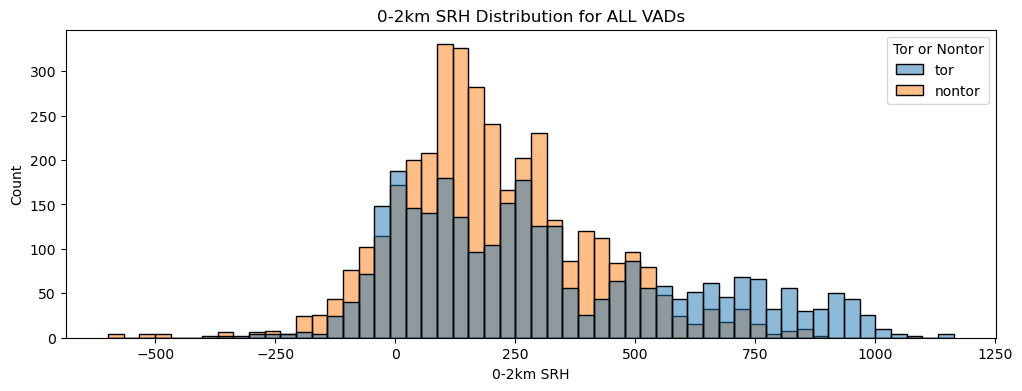

In [129]:
plt.figure(figsize = (12, 4))
sns.histplot(df_all_new, x = df_all_new['0-2km SRH'], hue = 'Tor or Nontor')
plt.title('0-2km SRH Distribution for ALL VADs')
plt.show()

In [ ]:
df['Rounded_Angle']

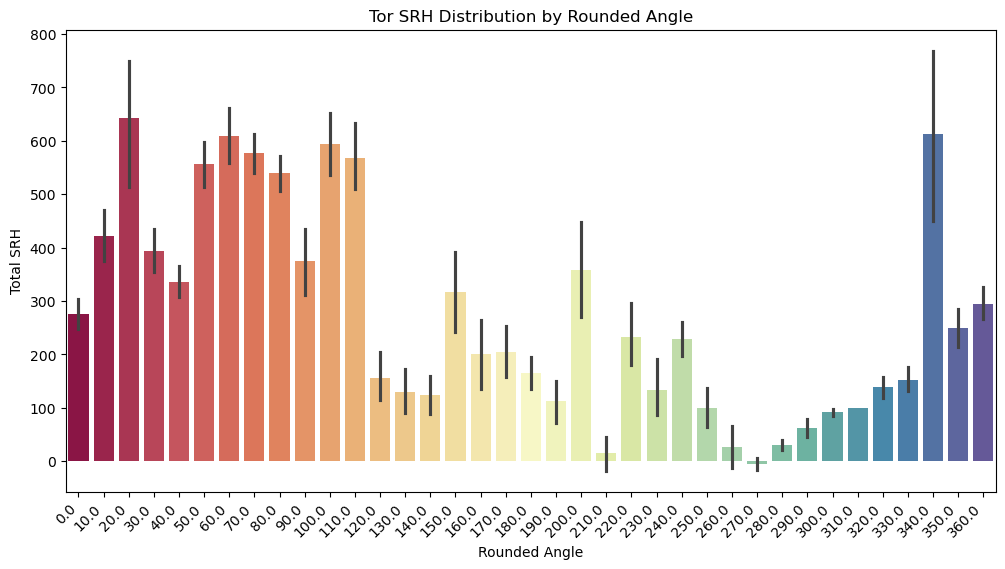

In [259]:
df = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']

df['Rounded_Angle'] = df['Angle'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
# Group by rounded angles and distances
grouped = df.groupby(['Rounded_Angle', 'Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Distance']}km", axis=1)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Rounded_Angle', y='Rounded_SRH', data=df, hue='Rounded_Angle', palette = "Spectral", legend=False)

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Rounded Angle")
plt.ylabel("Total SRH")
plt.title("Tor SRH Distribution by Rounded Angle")
plt.show()

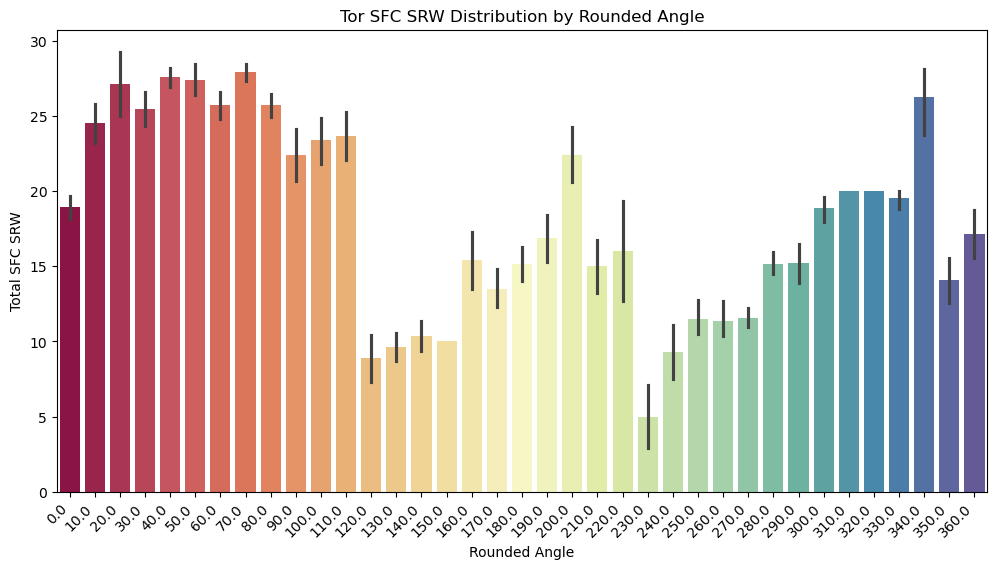

In [335]:
df = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']

df['Rounded_Angle'] = df['Angle'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
df['Rounded_SFC_SRW_Mag'] = df['SFC SRW Mag'].round(-1)
# Group by rounded angles and distances
#grouped = df.groupby(['Rounded_Angle', 'Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
#grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Distance']}km", axis=1)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Rounded_Angle', y='Rounded_SFC_SRW_Mag', data=df, hue='Rounded_Angle', palette = "Spectral", legend=False)

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Rounded Angle")
plt.ylabel("Total SFC SRW")
plt.title("Tor SFC SRW Distribution by Rounded Angle")
plt.show()

In [278]:
df_all_new[df_all_new['Time From Tor (min)'] == 0]

,0,1,2,3,4,5,6,7,8,9,...,Time From Tor (min),Datetime,Date,Tor or Nontor,SFC SRW Mag,0-500m SRW Mag,0-1km SRW Mag,0-2km SRW Mag,0-2km SRH,0-1km SRH
55,0.053380,0.114234,0.166610,0.036178,-0.226589,-0.751722,-1.632881,-2.712555,-3.983265,-5.346808,...,0.0,2022-05-23 23:50:43,20220523,tor,15.298214,21.486083,23.100062,17.866872,-55.464015,-122.953819
56,-21.731094,-21.889544,-22.020657,-22.125553,-22.302590,-22.353354,-22.493177,-22.571420,-22.598513,-22.600248,...,0.0,2022-05-23 23:51:12,20220523,tor,25.236423,24.352577,24.041310,17.724522,292.610974,191.144498
57,-21.194378,-21.156693,-21.102055,-21.059464,-21.023212,-20.924004,-20.841960,-20.674576,-20.513275,-20.358528,...,0.0,2022-05-23 23:51:43,20220523,tor,24.163337,23.735563,22.139530,16.254796,315.657527,224.336846
58,-17.374348,-17.409893,-17.466550,-17.522010,-17.616312,-17.710136,-17.746315,-17.847101,-17.962282,-18.058195,...,0.0,2022-05-23 23:59:39,20220523,tor,26.887511,29.927841,29.211629,24.806485,630.982285,426.943930
59,-13.311412,-13.489737,-13.631624,-13.737053,-13.958492,-13.978154,-14.097898,-14.174558,-14.245759,-14.334076,...,0.0,2022-05-24 00:02:09,20220523,tor,22.554445,27.646581,25.767012,25.429523,417.095482,238.150082
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6260,5.873395,7.254926,7.972167,8.490339,8.490339,9.825188,10.053070,10.651093,10.777714,11.080694,...,0.0,2023-06-15 23:34:33,20230615,tor,30.723766,32.778502,37.577932,36.322939,185.363281,-252.428476
6261,5.870036,6.892848,7.636077,8.223860,8.223860,9.463680,9.869579,10.706474,11.326498,11.618641,...,0.0,2023-06-15 23:34:48,20230615,tor,31.457895,35.957144,37.600600,35.670120,176.928095,-261.913958
6435,30.845078,30.835041,30.815529,30.815529,30.792297,30.742783,30.639614,30.480580,30.413710,30.227856,...,0.0,2023-06-15 23:34:19,20230615,tor,31.418557,30.328471,38.380052,38.256704,122.476289,-302.929986
6436,30.157139,30.133572,30.067602,29.992443,29.992443,29.926596,29.913721,29.838234,29.788588,29.744156,...,0.0,2023-06-15 23:34:33,20230615,tor,30.723766,32.778502,37.577932,36.322939,185.363281,-252.428476


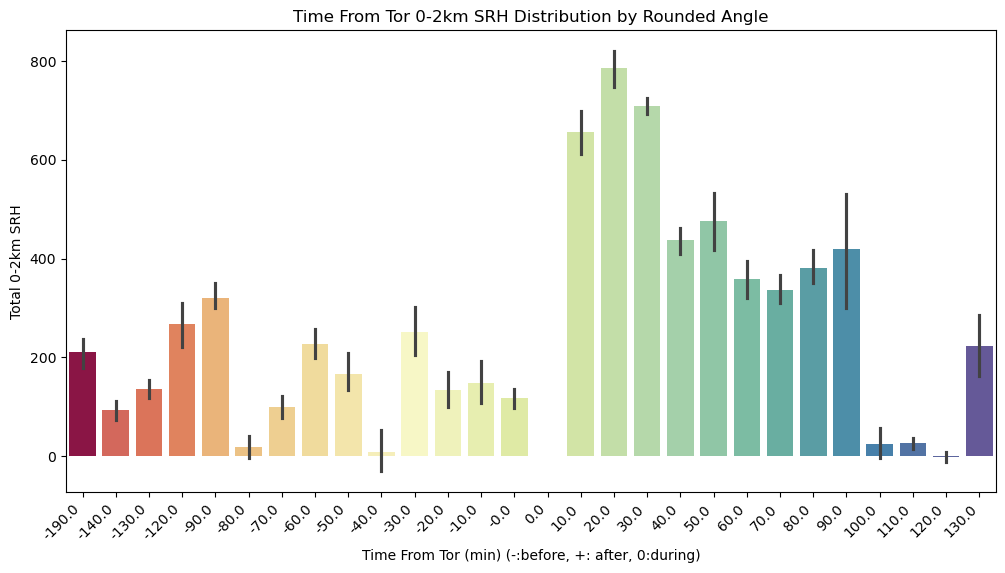

In [276]:
df = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']

df['Rounded_Angle'] = df['Angle'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
df['Rounded_Time_From_Tor_(min)'] = df['Time From Tor (min)'].astype(float).round(-1)
# Group by rounded angles and distances
grouped = df.groupby(['Rounded_Angle', 'Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
#grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Distance']}km", axis=1)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Rounded_Time_From_Tor_(min)', y='Rounded_SRH', data=df, hue='Rounded_Time_From_Tor_(min)', palette = "Spectral", legend=False)

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Time From Tor (min) (-:before, +: after, 0:during)")
plt.ylabel("Total 0-2km SRH")
plt.title("Time From Tor 0-2km SRH Distribution by Rounded Angle")
plt.show()

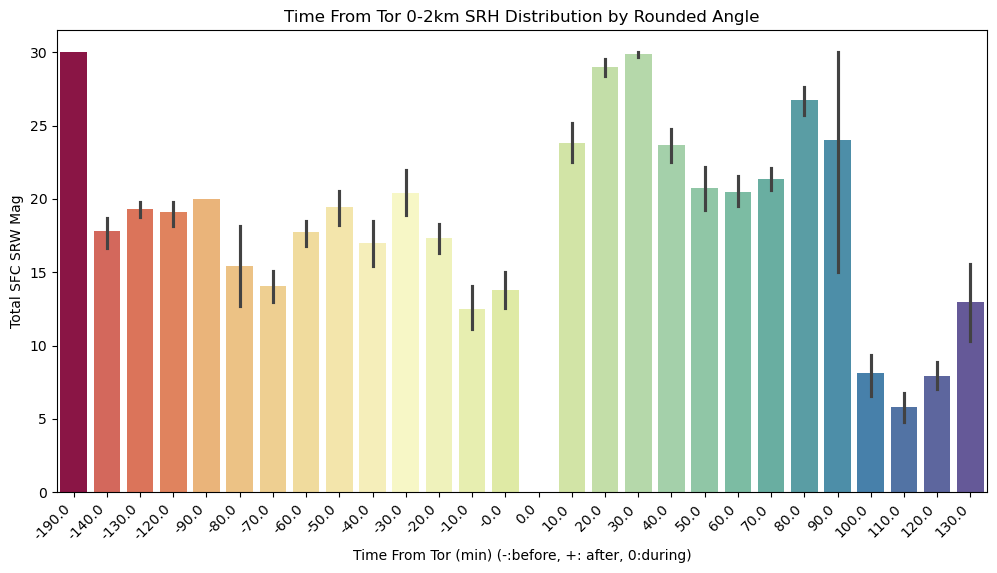

In [297]:
df = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']

df['Rounded_Angle'] = df['Angle'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
df['Rounded_SFC_SRW_Mag'] = df['SFC SRW Mag'].round(-1)
df['Rounded_Time_From_Tor_(min)'] = df['Time From Tor (min)'].astype(float).round(-1)
# Group by rounded angles and distances
#grouped = df.groupby(['Rounded_Angle', 'Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
#grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Distance']}km", axis=1)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Rounded_Time_From_Tor_(min)', y='Rounded_SFC_SRW_Mag', data=df, hue='Rounded_Time_From_Tor_(min)', palette = "Spectral", legend=False)

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Time From Tor (min) (-:before, +: after, 0:during)")
plt.ylabel("Total SFC SRW Mag")
plt.title("Time From Tor 0-2km SRH Distribution by Rounded Angle")
plt.show()

This may not be a good indication of wind speed differences; should look for the CHANGE in wind speed up to torgen, not just the raw srw speed because some days just have faster wind than others.

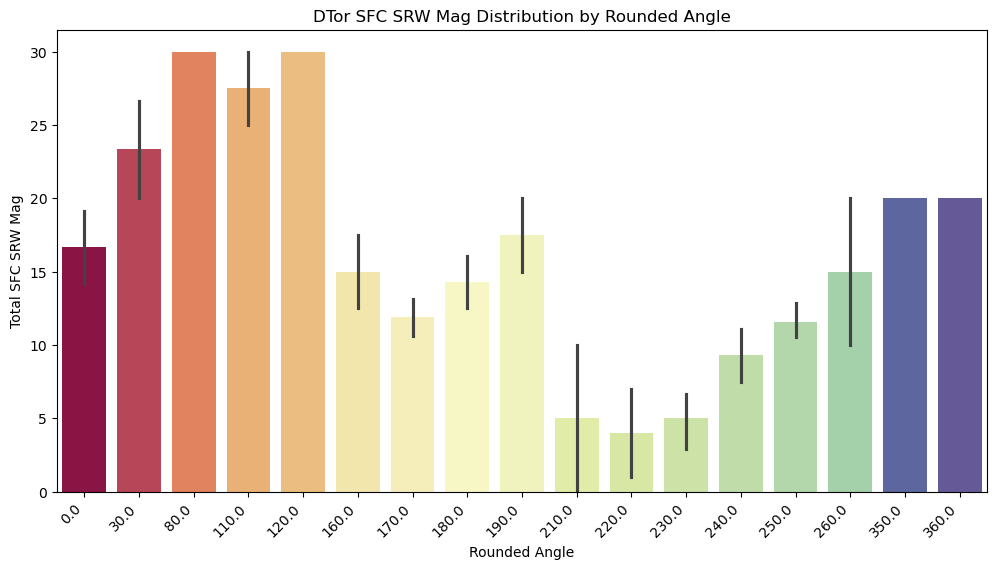

In [299]:
df = df_all_new[df_all_new['Time From Tor (min)'] == 0]

df['Rounded_Angle'] = df['Angle'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
df['Rounded_SFC_SRW_Mag'] = df['SFC SRW Mag'].round(-1)
df['Rounded_Time_From_Tor_(min)'] = df['Time From Tor (min)'].astype(float).round(-1)
# Group by rounded angles and distances
#grouped = df.groupby(['Rounded_Angle', 'Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
#grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Distance']}km", axis=1)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Rounded_Angle', y='Rounded_SFC_SRW_Mag', data=df, hue='Rounded_Angle', palette = "Spectral", legend=False)

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Rounded Angle")
plt.ylabel("Total SFC SRW Mag")
plt.title("DTor SFC SRW Mag Distribution by Rounded Angle")
plt.show()

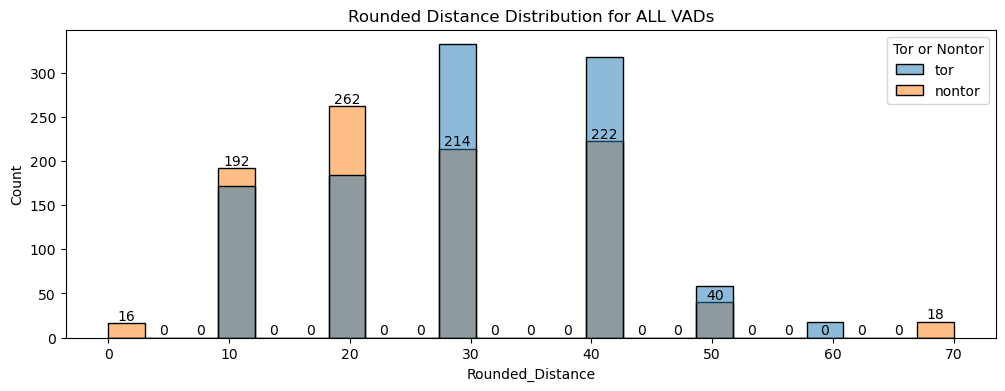

In [469]:
df = df_all_new
df = df[df['Distance'] <= 100]
df = df[df['Angle'] <= 90]

df['Rounded_Distance'] = df['Distance'].round(-1)
plt.figure(figsize = (12, 4))

ax = sns.histplot(df, x = df['Rounded_Distance'], hue = 'Tor or Nontor') #multiple='stack')
ax.bar_label(ax.containers[0])
plt.title('Rounded Distance Distribution for ALL VADs')
plt.show()

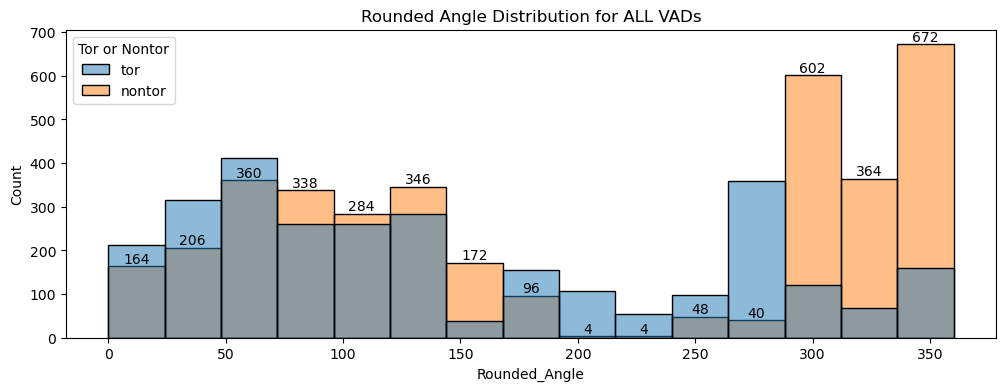

In [535]:
df = df_all_new
df['Rounded_Angle'] = df['Angle'].round(-1)
plt.figure(figsize = (12, 4))

ax = sns.histplot(df, x = df['Rounded_Angle'], hue = 'Tor or Nontor') #multiple='stack')
ax.bar_label(ax.containers[0])
plt.title('Rounded Angle Distribution for ALL VADs')
plt.show()

In [551]:
def sns_barplot(df_all_new, field, tor_or_nontor, distance_or_angle, srw_or_srh, palette):
        
    df = df_all_new[df_all_new['Tor or Nontor'] == tor_or_nontor]

    df = df[df['Distance'] <= 100]
    df['Rounded_Angle'] = df['Angle'].round(-1)
    df['Rounded_Distance'] = df['Distance'].round(-1)
    
    if srw_or_srh == 'SRH':
        df[f'Rounded_{field}'] = df[field].round(-2)

    elif srw_or_srh == 'SRW':
        df[f'Rounded_{field}'] = df[field].round(-1)

    if distance_or_angle == 'Rounded_Distance':
        df = df[df['Angle'] <= 90]
        a = df['Rounded_Distance'].value_counts() >= 20
        filtered_values = df['Rounded_Distance'].loc[df['Rounded_Distance'].isin(a[a].index)]
        df['Rounded_Distance'] = filtered_values
        
    # Plot
    plt.figure(figsize=(8, 4))
    sns.barplot(x=distance_or_angle, y= f'Rounded_{field}', data=df, palette = palette)
    
    plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
    plt.xlabel(distance_or_angle)
    plt.ylabel(f'Rounded {field}')
    plt.title(f'{tor_or_nontor} {field} Distribution by {distance_or_angle}')
    plt.show()

In [543]:
df_all_new

,0,1,2,3,4,5,6,7,8,9,...,Date,Tor or Nontor,SFC SRW Mag,0-500m SRW Mag,0-1km SRW Mag,0-2km SRW Mag,0-2km SRH,0-1km SRH,0-500m SRH,Rounded_Angle
0,-16.835770,-16.755274,-16.687143,-16.646894,-16.591278,-16.606508,-16.596056,-16.624393,-16.698717,-16.813435,...,20220523,tor,18.084001,19.302792,18.473383,13.340017,119.748598,81.601290,43.718735,280.0
1,-14.939102,-15.009944,-15.074447,-15.129332,-15.258727,-15.290950,-15.374236,-15.448551,-15.529462,-15.613126,...,20220523,tor,16.929266,18.590600,17.777007,13.117256,98.612390,53.953928,25.731828,280.0
2,-14.908146,-15.014770,-15.122228,-15.226007,-15.440908,-15.526935,-15.692964,-15.829327,-15.938499,-16.014187,...,20220523,tor,16.606345,18.680288,17.533481,12.630869,100.986069,63.738470,36.041791,280.0
3,-14.967583,-15.150704,-15.295214,-15.410604,-15.666528,-15.871101,-15.918962,-16.046745,-16.148834,-16.246586,...,20220523,tor,17.077444,18.364092,17.398431,11.940222,90.521531,52.715599,24.762802,280.0
4,-15.580977,-15.710516,-15.809145,-15.890134,-16.091858,-16.142567,-16.262787,-16.348358,-16.409420,-16.458860,...,20220523,tor,18.654303,18.533768,18.004913,12.514061,104.417661,52.484157,23.261166,280.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6595,-1.635275,-1.568471,-1.420855,-1.320286,-1.320286,-1.102728,-1.051306,-0.936231,-0.836507,-0.828301,...,20230615,tor,23.652900,24.142144,12.620730,4.804360,244.074307,221.865744,121.639653,10.0
6596,-3.691865,-3.578943,-3.513133,-3.421503,-3.421503,-3.236247,-3.157359,-3.030900,-2.966462,-2.847811,...,20230615,tor,23.917808,23.224960,11.152169,3.214427,226.896842,217.227740,135.596333,10.0
6597,-3.230326,-3.062784,-2.947798,-2.882831,-2.882831,-2.730972,-2.657030,-2.451415,-2.396161,-2.222835,...,20230615,tor,26.158343,23.125663,11.074837,3.195468,206.528619,195.927016,115.556819,10.0
6598,-4.028626,-3.970635,-3.912552,-3.842394,-3.842394,-3.703241,-3.636965,-3.529508,-3.464480,-3.379116,...,20230615,tor,26.418142,23.072401,10.245528,2.997714,218.595898,201.388554,139.132772,10.0


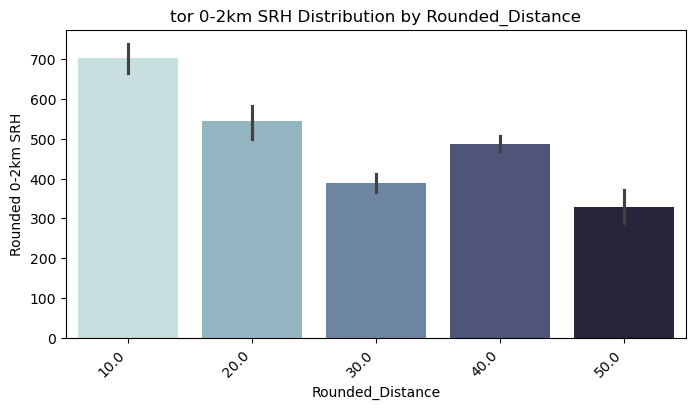

In [552]:
sns_barplot(df_all_new, '0-2km SRH', 'tor', 'Rounded_Distance', 'SRH', "ch:start=.2,rot=-.3")

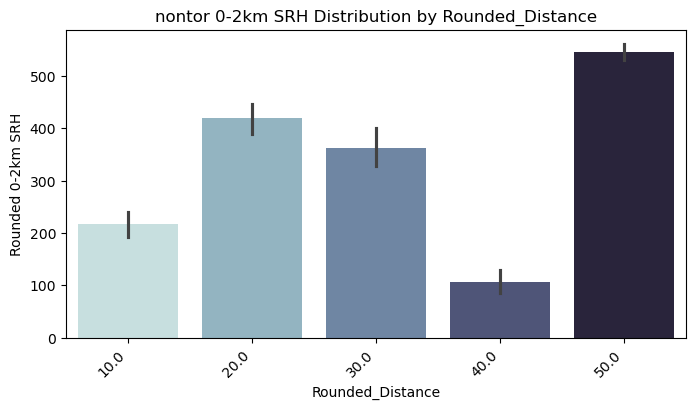

In [553]:
sns_barplot(df_all_new, '0-2km SRH', 'nontor', 'Rounded_Distance', 'SRH', "ch:start=.2,rot=-.3")

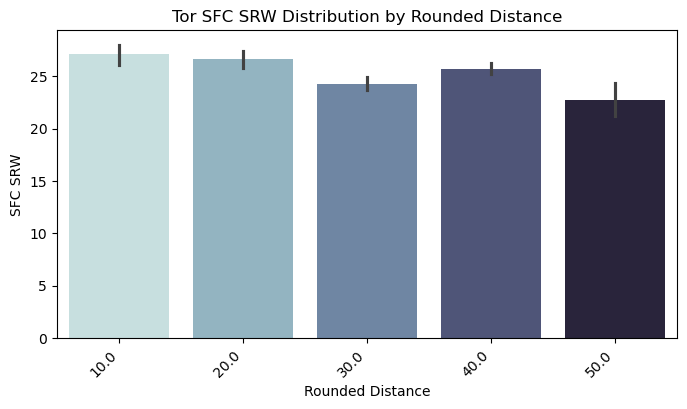

In [532]:
df = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
df = df[df['Distance'] <= 60]
df = df[df['Angle'] <= 90]

df['Rounded_Angle'] = df['Angle'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
df['Rounded_SFC_SRW_Mag'] = df['SFC SRW Mag'].round(-1)
df['Rounded_Distance'] = df['Distance'].round(-1)

a = df['Rounded_Distance'].value_counts() >= 20
filtered_values = df['Rounded_Distance'].loc[df['Rounded_Distance'].isin(a[a].index)]
df['Rounded_Distance'] = filtered_values

# Group by rounded angles and distances
#grouped = df.groupby(['Rounded_Angle', 'Rounded_Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
#grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Rounded_Distance']}km", axis=1)

# Plot
plt.figure(figsize=(8, 4))
sns.barplot(x='Rounded_Distance', y='Rounded_SFC_SRW_Mag', data=df, palette = "ch:start=.2,rot=-.3")

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Rounded Distance")
plt.ylabel("SFC SRW")
plt.title("Tor SFC SRW Distribution by Rounded Distance")
plt.show()

In [457]:
df['Rounded_Distance'].value_counts()

Rounded_Distance
30.0    332
40.0    318
20.0    184
10.0    172
50.0     58
60.0     18
Name: count, dtype: int64

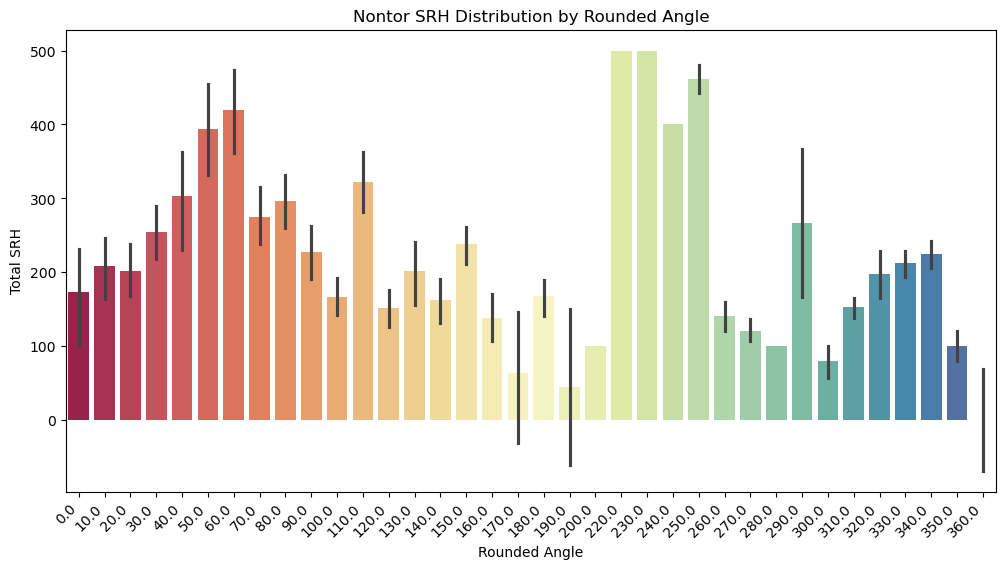

In [294]:
df = df_all_new[df_all_new['Time From Tor (min)'] == 'nontor']

df['Rounded_Angle'] = df['Angle'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
# Group by rounded angles and distances
grouped = df.groupby(['Rounded_Angle', 'Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Distance']}km", axis=1)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Rounded_Angle', y='Rounded_SRH', data=df, palette = "Spectral")

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Rounded Angle")
plt.ylabel("Total SRH")
plt.title("Nontor SRH Distribution by Rounded Angle")
plt.show()

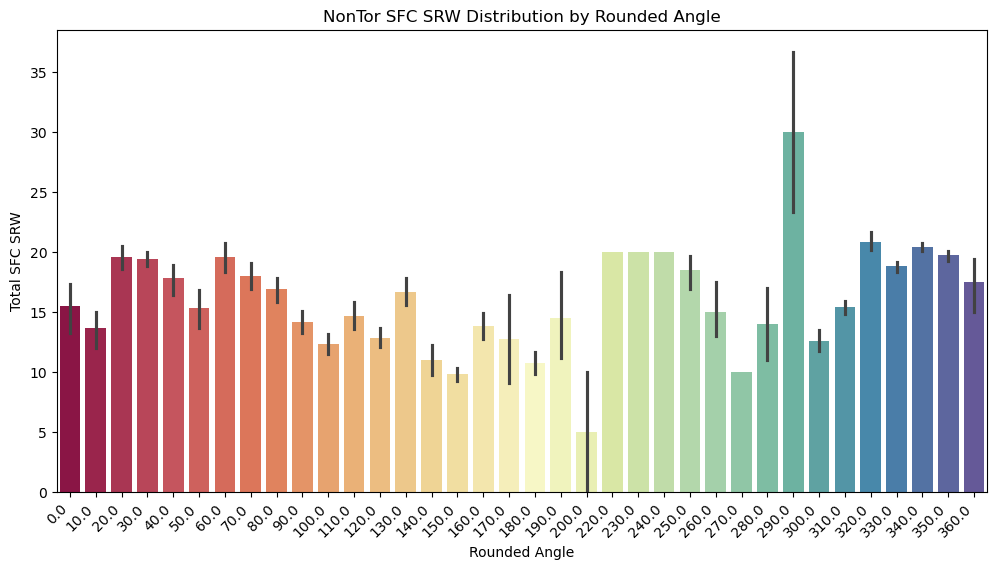

In [334]:
df = df_all_new[df_all_new['Time From Tor (min)'] == 'nontor']

df['Rounded_Angle'] = df['Angle'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
df['Rounded_SFC_SRW_Mag'] = df['SFC SRW Mag'].round(-1)
# Group by rounded angles and distances
#grouped = df.groupby(['Rounded_Angle', 'Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
#grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Distance']}km", axis=1)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Rounded_Angle', y='Rounded_SFC_SRW_Mag', data=df, hue='Rounded_Angle', palette = "Spectral", legend=False)

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Rounded Angle")
plt.ylabel("Total SFC SRW")
plt.title("NonTor SFC SRW Distribution by Rounded Angle")
plt.show()

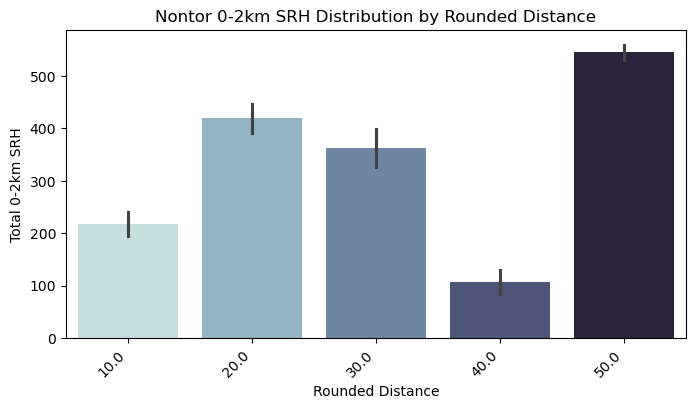

In [531]:
df = df_all_new[df_all_new['Time From Tor (min)'] == 'nontor']
df = df[df['Angle'] <= 90]
#df = df[df['Distance'] >= 10]
#df = df[df['Distance'] <= 70]

df['Rounded_Angle'] = df['Angle'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
df['Rounded_Distance'] = df['Distance'].round(-1)
a = df['Rounded_Distance'].value_counts() >= 20
filtered_values = df['Rounded_Distance'].loc[df['Rounded_Distance'].isin(a[a].index)]
df['Rounded_Distance'] = filtered_values

# Group by rounded angles and distances
grouped = df.groupby(['Rounded_Angle', 'Rounded_Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Rounded_Distance']}km", axis=1)

# Plot
plt.figure(figsize=(8, 4))
sns.barplot(x='Rounded_Distance', y='Rounded_SRH', data=df, palette = "ch:start=.2,rot=-.3")

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Rounded Distance")
plt.ylabel("Total 0-2km SRH")
plt.title("Nontor 0-2km SRH Distribution by Rounded Distance")
plt.show()

In [526]:
df['Rounded_Distance']

141     10.0
142     10.0
143     10.0
144     10.0
145     10.0
        ... 
5396    10.0
5397    10.0
5398    10.0
5399    10.0
5400    10.0
Name: Rounded_Distance, Length: 964, dtype: float64

In [527]:
a = df['Rounded_Distance'].value_counts() >= 20

In [529]:
filtered_values = df['Rounded_Distance'].loc[df['Rounded_Distance'].isin(a[a].index)]

In [530]:
filtered_values

141     10.0
142     10.0
143     10.0
144     10.0
145     10.0
        ... 
5396    10.0
5397    10.0
5398    10.0
5399    10.0
5400    10.0
Name: Rounded_Distance, Length: 930, dtype: float64

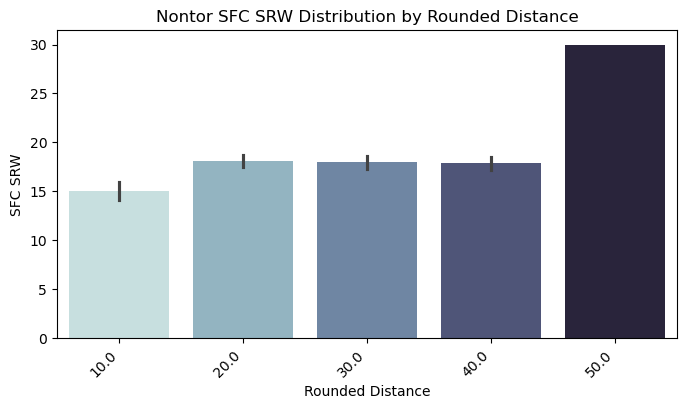

In [534]:
df = df_all_new[df_all_new['Time From Tor (min)'] == 'nontor']
df = df[df['Distance'] <= 100]
df = df[df['Angle'] <= 90]

df['Rounded_Angle'] = df['Angle'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
df['Rounded_SFC_SRW_Mag'] = df['SFC SRW Mag'].round(-1)
df['Rounded_Distance'] = df['Distance'].round(-1)
a = df['Rounded_Distance'].value_counts() >= 20
filtered_values = df['Rounded_Distance'].loc[df['Rounded_Distance'].isin(a[a].index)]
df['Rounded_Distance'] = filtered_values
# Group by rounded angles and distances
#grouped = df.groupby(['Rounded_Angle', 'Rounded_Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
#grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Rounded_Distance']}km", axis=1)

# Plot
plt.figure(figsize=(8, 4))
sns.barplot(x='Rounded_Distance', y='Rounded_SFC_SRW_Mag', data=df, palette = "ch:start=.2,rot=-.3")

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Rounded Distance")
plt.ylabel("SFC SRW")
plt.title("Nontor SFC SRW Distribution by Rounded Distance")
plt.show()

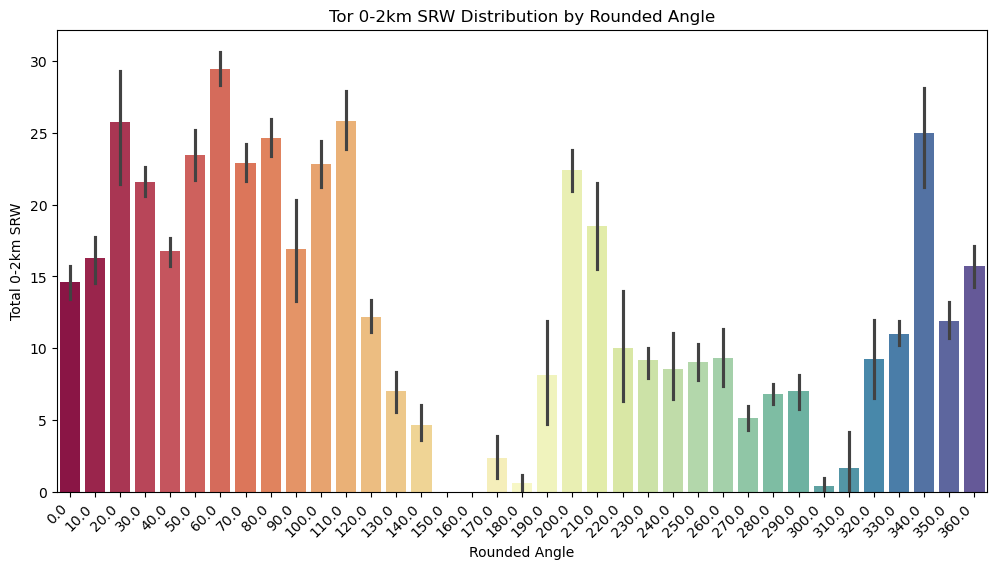

In [339]:
df = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']

df['Rounded_Angle'] = df['Angle'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
df['Rounded_0-2km_SRW_Mag'] = df['0-2km SRW Mag'].round(-1)
# Group by rounded angles and distances
#grouped = df.groupby(['Rounded_Angle', 'Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
#grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Distance']}km", axis=1)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Rounded_Angle', y='Rounded_0-2km_SRW_Mag', data=df, hue='Rounded_Angle', palette = "Spectral", legend=False)

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Rounded Angle")
plt.ylabel("Total 0-2km SRW")
plt.title("Tor 0-2km SRW Distribution by Rounded Angle")
plt.show()

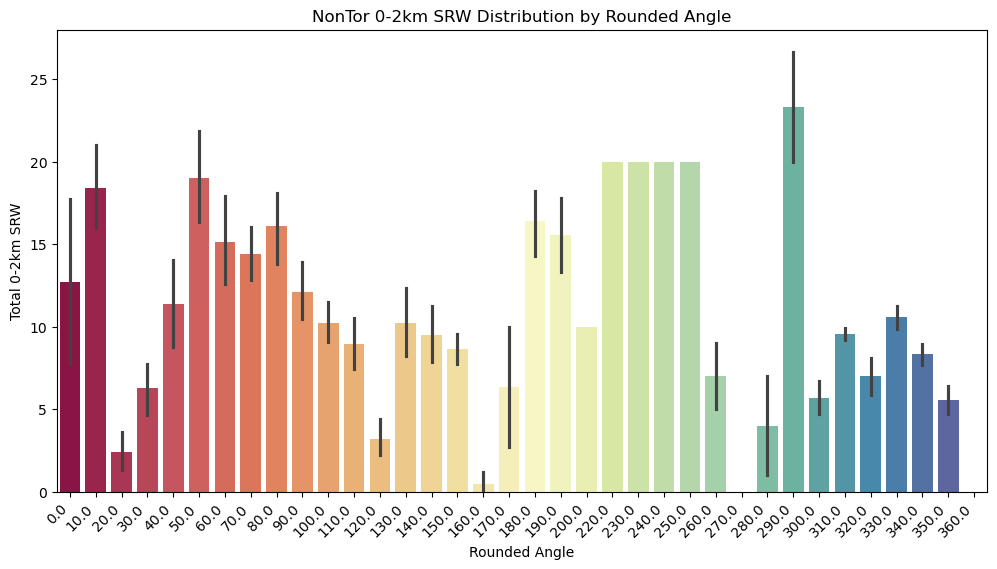

In [338]:
df = df_all_new[df_all_new['Time From Tor (min)'] == 'nontor']

df['Rounded_Angle'] = df['Angle'].round(-1)
df['Rounded_SRH'] = df['0-2km SRH'].round(-2)
df['Rounded_0-2km_SRW_Mag'] = df['0-2km SRW Mag'].round(-1)
# Group by rounded angles and distances
#grouped = df.groupby(['Rounded_Angle', 'Distance'])['Rounded_SRH'].sum().reset_index()

# Create label for x-axis
#grouped['label'] = grouped.apply(lambda row: f"{row['Rounded_Angle']}° @ {row['Distance']}km", axis=1)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Rounded_Angle', y='Rounded_0-2km_SRW_Mag', data=df, hue='Rounded_Angle', palette = "Spectral", legend=False)

plt.xticks(rotation=45, ha='right')  # Rotate labels for readability
plt.xlabel("Rounded Angle")
plt.ylabel("Total 0-2km SRW")
plt.title("NonTor 0-2km SRW Distribution by Rounded Angle")
plt.show()

In [ ]:
df_all_new

In [137]:
dftor = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
#dftor['Tor or Nontor'] = 'tor'

dfnontor = df_all_new[df_all_new['Time From Tor (min)'] == 'nontor']
#dfnontor['Tor or Nontor'] = 'nontor'

In [138]:
# a_new = pd.DataFrame()
# ALL_new = pd.concat([a_new, dftor, dfnontor])

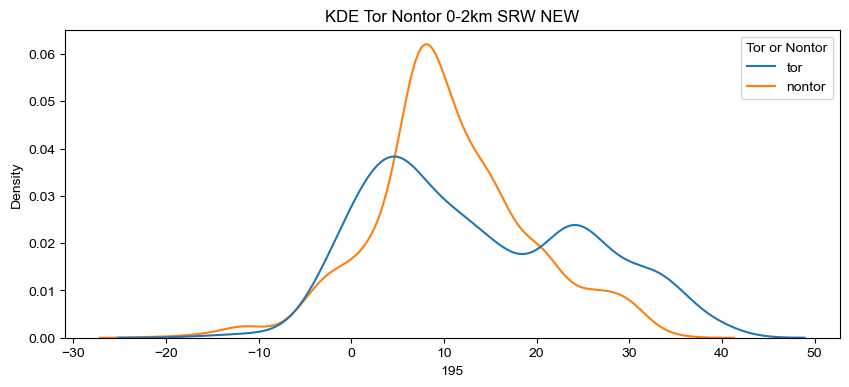

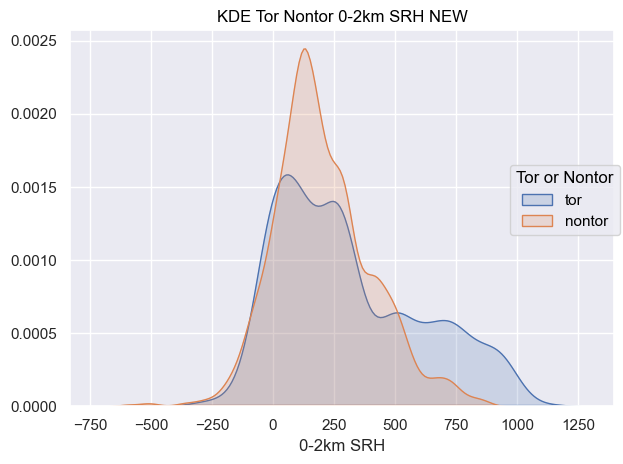

In [139]:
#plt.figure(figsize = (12, 4))
df = df_all_new
p = so.Plot(df, x='0-2km SRH', color='Tor or Nontor').add(sns.objects.Area(), 
                                                          sns.objects.KDE(common_norm=False)).label(title = 'KDE Tor Nontor 0-2km SRH NEW')
p.show()

In [140]:
x = np.nanmean(dftor[dftor['u or v'] == 'v']['195'], axis=0)
print(f'Mean TOR noncomposite v SRW: {x}')

Mean TOR noncomposite v SRW: 13.608573233160612


In [141]:
y = np.nanmean(dfnontor[dfnontor['u or v'] == 'v']['195'], axis=0)
print(f'Mean NONTOR noncomposite v SRW: {y}')

Mean NONTOR noncomposite v SRW: 10.60238636952924


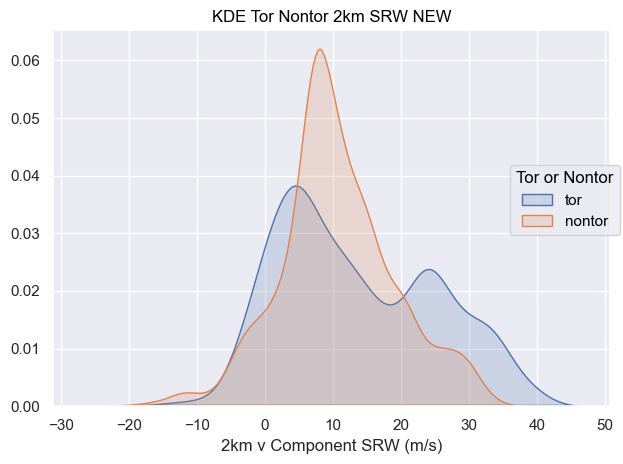

In [142]:
#plt.figure(figsize = (12, 4))
df = df_all_new
df = df[df['u or v'] == 'v']
p = so.Plot(df, x='195', color='Tor or Nontor').add(sns.objects.Area(), 
                                                    sns.objects.KDE(common_norm=False)).label(x = '2km v Component SRW (m/s)', 
                                                                                              title = 'KDE Tor Nontor 2km SRW NEW')
p.show()

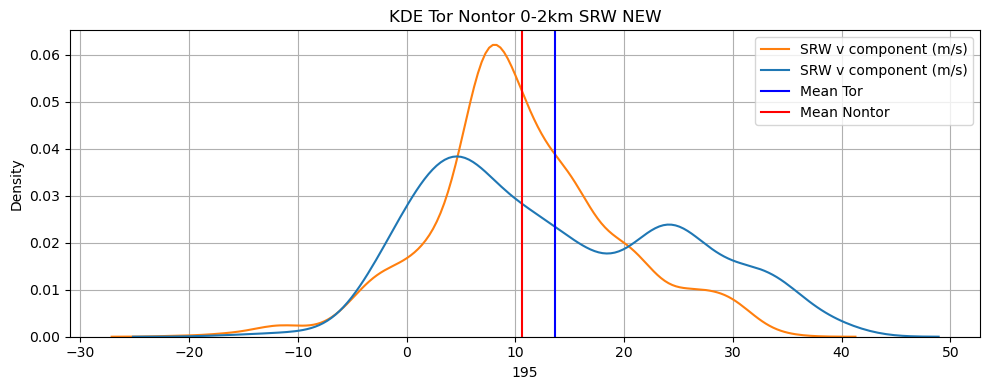

In [143]:
#plt.figure(figsize = (12, 4))
df = df_all_new
df = df[df['u or v'] == 'v']
fig = plt.figure(figsize=(10, 4))
p = sns.kdeplot(df, x='195', hue='Tor or Nontor', common_norm=False, label = 'SRW v component (m/s)')
                
plt.title('KDE Tor Nontor 0-2km SRW NEW')

plt.axvline(x, color='blue', label='Mean Tor')
plt.axvline(x=y, color='red', label='Mean Nontor')
plt.grid()
plt.tight_layout()
plt.legend()
plt.show()

In [ ]:
x = np.nanmean(dftor['0-2km SRH'], axis=0)
print(f'Mean TOR not composited 0-2km SRH: {x}')
y = np.nanmean(dfnontor['0-2km SRH'], axis=0)
print(f'Mean NONTOR not composited 0-2km SRH: {y}')

In [ ]:
#plt.figure(figsize = (12, 4))
df = df_all_new
#df = df[df['u or v'] == 'v']
fig = plt.figure(figsize=(10, 4))
p = sns.kdeplot(df, x='0-2km SRH', hue='Tor or Nontor', common_norm=False, label = '0-2km SRH (m2/s2)')
                
plt.title('KDE Tor Nontor 0-2km SRH NEW')

plt.axvline(x, color='blue', label='Mean Tor')
plt.axvline(x=y, color='red', label='Mean Nontor')
plt.grid()
plt.tight_layout()
plt.legend()
plt.show()

In [ ]:
comp_tor_all_new_copy = comp_tor_all_new.copy()
comp_tor_all_new_copy['Tor or Nontor'] = 'tor'

comp_nontor_all_new_copy = comp_nontor_all_new.copy()
comp_nontor_all_new_copy['Tor or Nontor'] = 'nontor'

In [ ]:
comp_a = pd.DataFrame()
comp_ALL = pd.concat([comp_a, comp_tor_all_new_copy, comp_nontor_all_new_copy])

In [ ]:
comp_ALL

In [ ]:
#plt.figure(figsize = (12, 4))
df = comp_ALL
df = df[df['wind'] == 'v']
p = so.Plot(df, x=195, color='Tor or Nontor').add(
    sns.objects.Area(), sns.objects.KDE(common_norm=False), so.Stack()).label(
    x = 'Avg 0-2km v SRW', title = 'KDE Composite Tor Nontor 0-2km v SRW NEW').scale(x = so.Continuous().tick(every=5))
p.show()

In [ ]:
x = np.nanmean(comp_tor_all_new_copy[comp_tor_all_new_copy['wind'] == 'v'][195], axis=0)
print(f'Mean TOR composite v SRW: {x}')

In [ ]:
y = np.nanmean(comp_nontor_all_new_copy[comp_nontor_all_new_copy['wind'] == 'v'][195], axis=0)
print(f'Mean NONTOR composite v SRW: {y}')

In [ ]:
#plt.figure(figsize = (12, 4))
df = comp_ALL
df = df[df['wind'] == 'v']
fig = plt.figure(figsize=(10, 4))
p = sns.kdeplot(df, x=195, hue='Tor or Nontor', common_norm=False, label = 'SRW v component (m/s)')
                
plt.title('KDE COMPOSITE Tor Nontor 0-2km v SRW NEW')

plt.axvline(x, color='blue', label='Mean Comp Tor')
plt.axvline(y, color='red', label='Mean Comp Nontor')
plt.xlabel('SRW v component (m/s)')
plt.grid()
plt.tight_layout()
plt.legend()
plt.show()

In [ ]:
x = np.nanmean(comp_tor_all_new_copy[comp_tor_all_new_copy['wind'] == 'u'][195], axis=0)
print(f'Mean TOR composite u SRW: {x}')
y = np.nanmean(comp_nontor_all_new_copy[comp_nontor_all_new_copy['wind'] == 'u'][195], axis=0)
print(f'Mean NONTOR composite u SRW: {y}')

In [ ]:
#plt.figure(figsize = (12, 4))
df = comp_ALL
df = df[df['wind'] == 'u']
fig = plt.figure(figsize=(10, 4))
p = sns.kdeplot(df, x=195, hue='Tor or Nontor', common_norm=False, label = 'SRW u component (m/s)')
                
plt.title('KDE COMPOSITE Tor Nontor 0-2km u SRW NEW')

plt.axvline(x, color='blue', label='Mean Comp Tor')
plt.axvline(x=y, color='red', label='Mean Comp Nontor')
plt.xlabel('SRW u component (m/s)')
plt.grid()
plt.tight_layout()
plt.legend()
plt.show()

In [ ]:
for d in sorted(set(df_all_new['Date'])):
    
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
    ax0.boxplot([df_all_new[(df_all_new['Date'] == d) & (df_all_new['Distance'] < 21)]['0-2km SRH'],
               df_all_new[(df_all_new['Date'] == d) & (df_all_new['Distance'] >= 21)]['0-2km SRH']], labels=['NF', 'FF'])
    ax0.set_xlabel('Distance')
    ax0.set_title(f'{d} 0-2km SRH per VAD NEW')

    ax1.boxplot([df_all_new[(df_all_new['Date'] == d) & (df_all_new['Angle'] < 45)]['0-2km SRH'],
               df_all_new[(df_all_new['Date'] == d) & (df_all_new['Angle'] >= 45) & (df_all_new['Angle'] <= 90)]['0-2km SRH']], labels=['0-45 Deg', '45-90 Deg'])
    ax1.set_xlabel('Angle')
    ax1.set_title(f'{d} 0-2km SRH per VAD NEW')

    plt.show()

In [ ]:
column = 'SRW Mag'
for d in sorted(set(df_all_new['Date'])):
    
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(10,3))
    ax0.boxplot([df_all_new[(df_all_new['Date'] == d) & (df_all_new['Distance'] < 21)][f'{column}'],
               df_all_new[(df_all_new['Date'] == d) & (df_all_new['Distance'] >= 21)][f'{column}']], labels=['NF', 'FF'])
    ax0.set_xlabel('Distance')
    ax0.set_title(f'{d} SFC SRW Mag per VAD NEW')

    ax1.boxplot([df_all_new[(df_all_new['Date'] == d) & (df_all_new['Angle'] < 45)][f'{column}'],
               df_all_new[(df_all_new['Date'] == d) & (df_all_new['Angle'] >= 45) & (df_all_new['Angle'] <= 90)][f'{column}']], labels=['0-45 Deg', '45-90 Deg'])
    ax1.set_xlabel('Angle')
    ax1.set_title(f'{d} SFC SRW Mag per VAD NEW')

    plt.show()

# SRW SRH Polar Plots

In [62]:
def srw_srh_polar_plot(field, vmax, vmin, max_radius, cbar_label):
    #title = f'{d} 0-2km SRH Per VAD'
    from matplotlib import rcParams, rcParamsDefault
    rcParams.update(rcParamsDefault)
    
    # Create two subplots side by side
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, subplot_kw={'projection': 'polar'}, figsize=(13, 5))
    plt.subplots_adjust(wspace=0.3)  # Adjust space between subplots
    
    # ========== First Subplot (Tornadic VADs) ==========
    ax0.set_rlabel_position(-22.5)
    ax0.grid(True, linestyle=':')
    # ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
    ax0.set_theta_zero_location('E')
    ax0.set_theta_direction(-1)
    ax0.set_ylim([0, max_radius])
    
    # Shade regions
    nf0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
    ff0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')
    
    df_all_new_tor = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
    
    # Tornadic points
    tor_points = ax0.scatter(df_all_new_tor['Angle'] * (np.pi/180), df_all_new_tor['Distance'], 
                             c=df_all_new_tor[field], s=20, cmap='pyart_BuDRd18', vmin=vmin, vmax=vmax)
    
    ax0.set_title(f'All Tor {field} Per VAD')
    
    ax1.set_rlabel_position(-22.5)
    ax1.grid(True, linestyle=':')
    # ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
    ax1.set_theta_zero_location('E')
    ax1.set_theta_direction(-1)
    ax1.set_ylim([0, max_radius])
    # Shade regions
    nf1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
    ff1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')
    
    
    df_all_new_nontor = df_all_new[df_all_new['Time From Tor (min)'] == 'nontor']
    
    nontor_points = ax1.scatter(df_all_new_nontor['Angle'] * (np.pi/180), df_all_new_nontor['Distance'], 
                             c=df_all_new_nontor['0-2km SRH'], s=20, cmap='pyart_BuDRd18', vmin=vmin, vmax=vmax)
    ax1.set_title(f'All Nontor {field} Per VAD')
    
    # nf = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='orange', alpha=0.5, label='Near-field')
    # ff = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='pink', alpha=0.3, label='Far-field')
    
    theta_start = np.deg2rad(100)
    ax0.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
    ax0.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
    
    ax1.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
    ax1.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
        
    # Colorbar
    cbar = fig.colorbar(tor_points, ax=[ax1], pad=0.1, shrink=0.8)
    cbar.set_label(cbar_label)
    
    #plt.suptitle(title, fontsize=13, fontweight='bold', ha='center')
    # Legend
    #plt.legend([nf, ff], ['Near-Field', 'Far-Field'], loc='upper left', fontsize=11)
    # plt.legend([storm_motion, nf, ff, meso], 
               #['Storm Motion', 'Near-Field', 'Far-Field', 'Mesocyclone'], loc = 'upper right', fontsize=11)
    
    #plt.savefig(f'/Users/juliabman/Desktop/spring2025_seminar/NontorvsTorPolarPlotsSRW', bbox_inches='tight')
    #fig.tight_layout()
    plt.show()

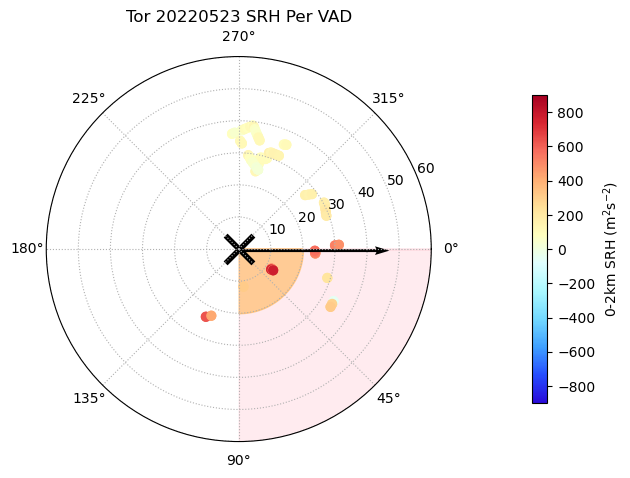

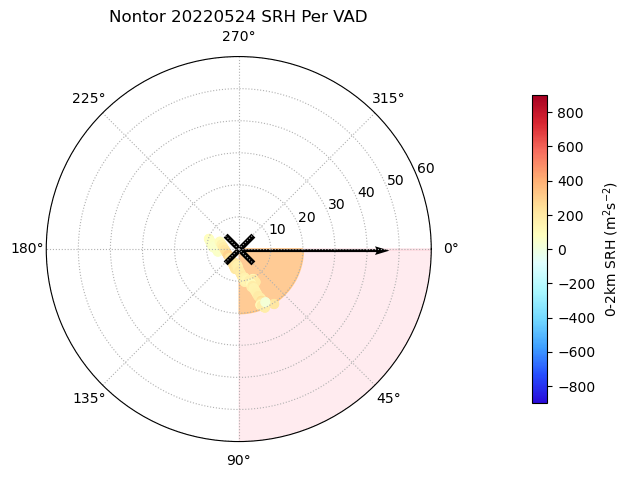

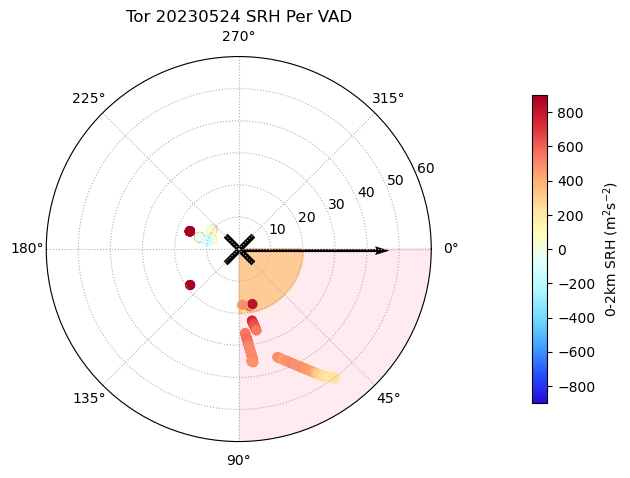

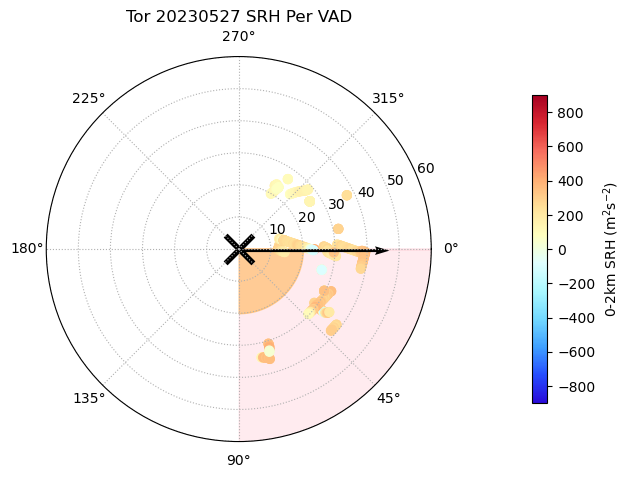

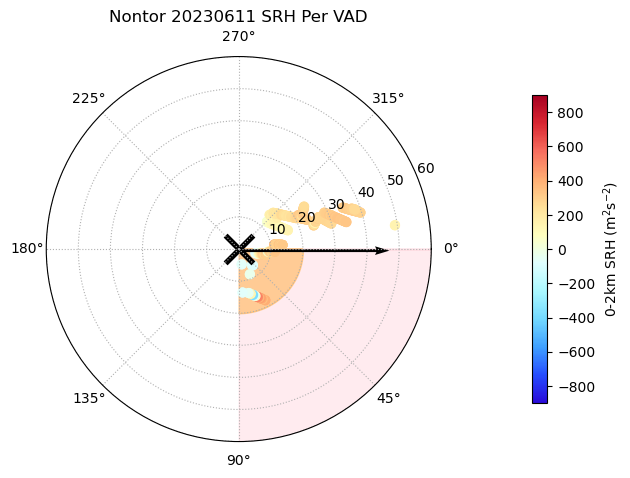

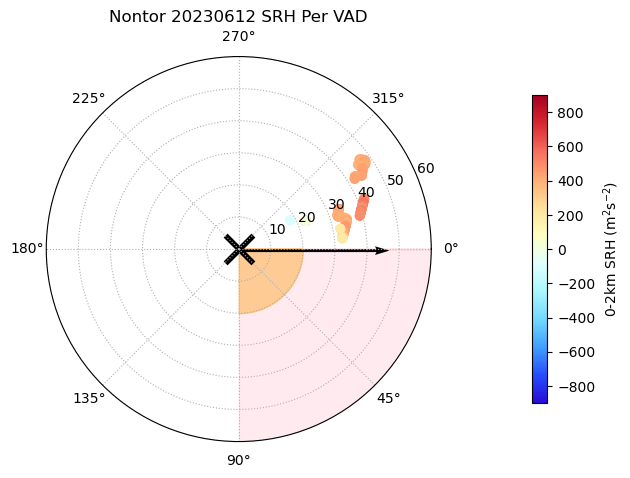

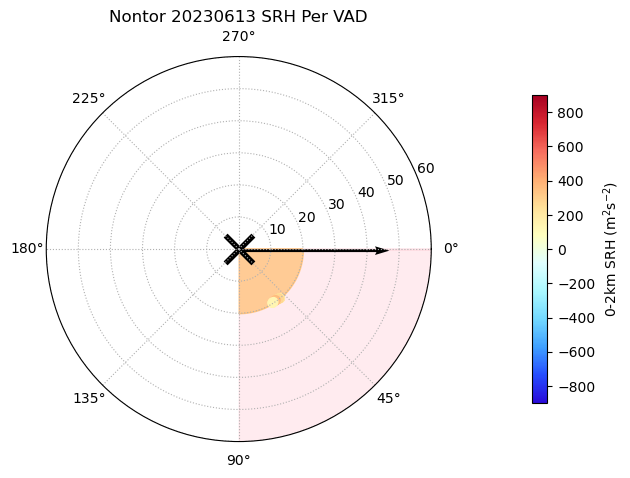

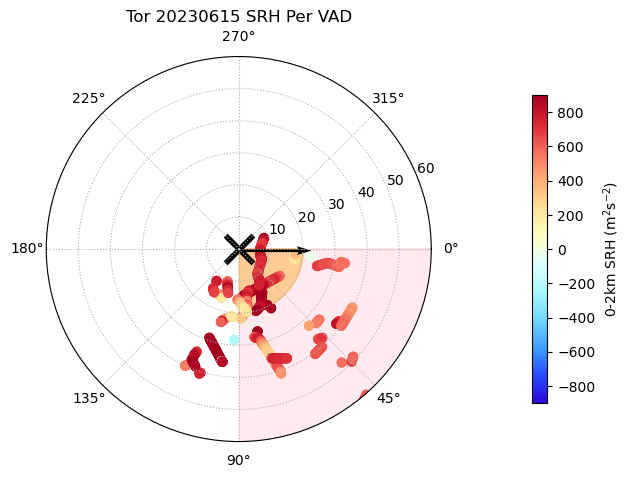

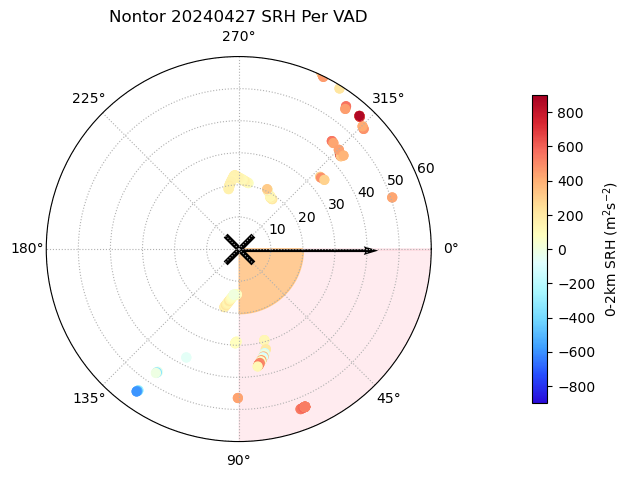

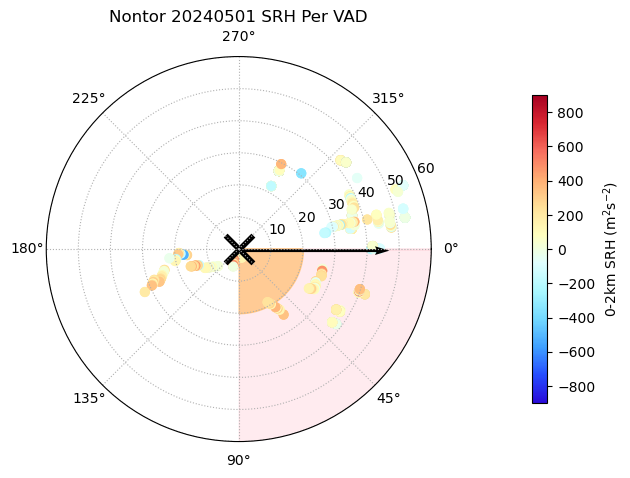

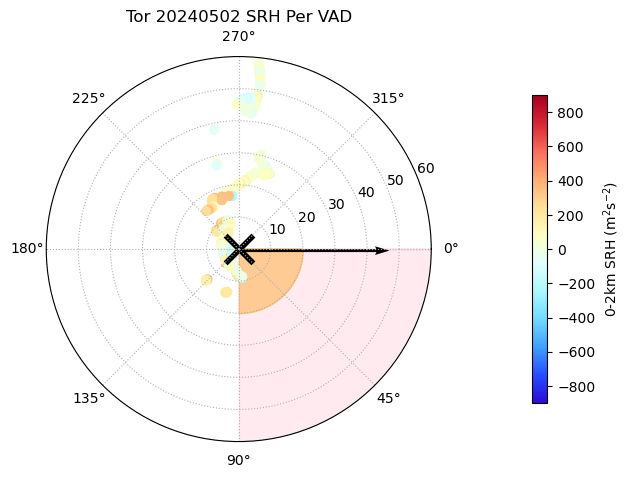

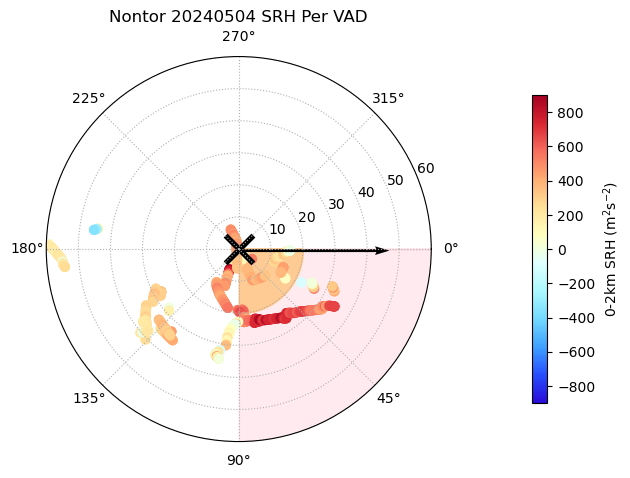

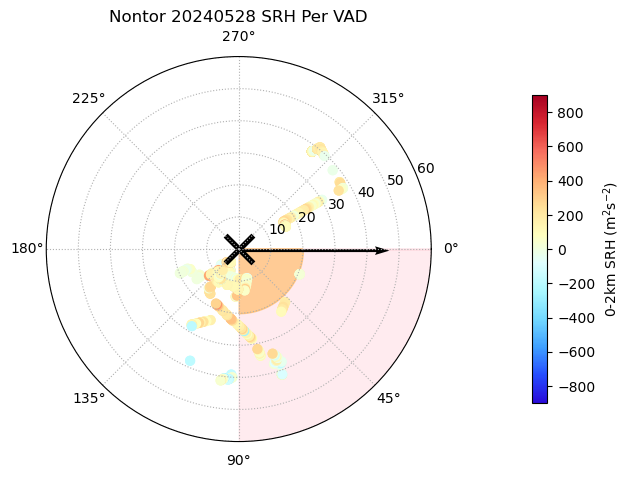

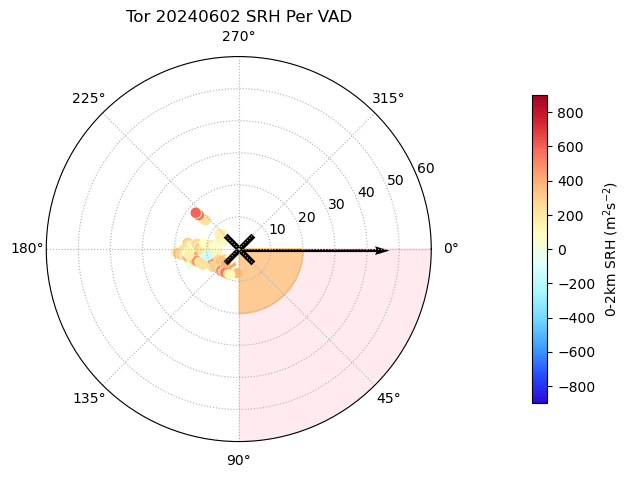

In [61]:
tor_srh_points = []
nontor_srh_points = []
for d in sorted(set(df_all_new['Date'])):
    title = f'{d} 0-2km SRH Per VAD'
    vmax = 900
    vmin = -900
    from matplotlib import rcParams, rcParamsDefault
    rcParams.update(rcParamsDefault)
    
    max_radius = 60
    #vmin = 0
    #vmax = 30
    
    # Create two subplots side by side
    fig, (ax0) = plt.subplots(nrows=1, ncols=1, subplot_kw={'projection': 'polar'}, figsize=(13, 5))
    plt.subplots_adjust(wspace=0.3)  # Adjust space between subplots
    
    # ========== First Subplot (Tornadic VADs) ==========
    ax0.set_rlabel_position(-22.5)
    ax0.grid(True, linestyle=':')
   # ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
    ax0.set_theta_zero_location('E')
    ax0.set_theta_direction(-1)
    ax0.set_ylim([0, max_radius])
    
    # Shade regions
    nf = ax0.fill_between(np.linspace(0, np.pi/2), 0, 20, color='orange', alpha=0.5, label='Near-field')
    ff = ax0.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='pink', alpha=0.3, label='Far-field')
    
    df_all_new_date = df_all_new[(df_all_new['Date'] == d)]

    if df_all_new_date['Time From Tor (min)'].ne('nontor').any():
        
        # Tornadic points
        tor_points = ax0.scatter(df_all_new_date['Angle'] * (np.pi/180), df_all_new_date['Distance'], 
                                 c=df_all_new_date['0-2km SRH'], s=40, cmap='pyart_BuDRd12', vmin=vmin, vmax=vmax)
        tor_srh_points.append(tor_points)
        
        plt.title(f'Tor {d} SRH Per VAD')

    if df_all_new_date['Time From Tor (min)'].eq('nontor').any():
    
        nontor_points = ax0.scatter(df_all_new_date['Angle'] * (np.pi/180), df_all_new_date['Distance'], 
                                 c=df_all_new_date['0-2km SRH'], s=40, cmap='pyart_BuDRd12', vmin=vmin, vmax=vmax)
        nontor_srh_points.append(nontor_points)
        
        plt.title(f'Nontor {d} SRH Per VAD')
        
    theta_start = np.deg2rad(100)
    ax0.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
    ax0.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
        
    # Colorbar
    cbar = fig.colorbar(tor_points, ax=[ax0], pad=0.1, shrink=0.8)
    cbar.set_label('0-2km SRH (m$^{2}$s$^{-2})$')
    
    #plt.suptitle(title, fontsize=13, fontweight='bold', ha='center')
    # Legend
    #plt.legend([nf, ff], ['Near-Field', 'Far-Field'], loc='upper left', fontsize=11)
   # plt.legend([storm_motion, nf, ff, meso], 
               #['Storm Motion', 'Near-Field', 'Far-Field', 'Mesocyclone'], loc = 'upper right', fontsize=11)
    
    
    #plt.savefig(f'/Users/juliabman/Desktop/spring2025_seminar/NontorvsTorPolarPlotsSRW', bbox_inches='tight')
    #fig.tight_layout()
    plt.show()

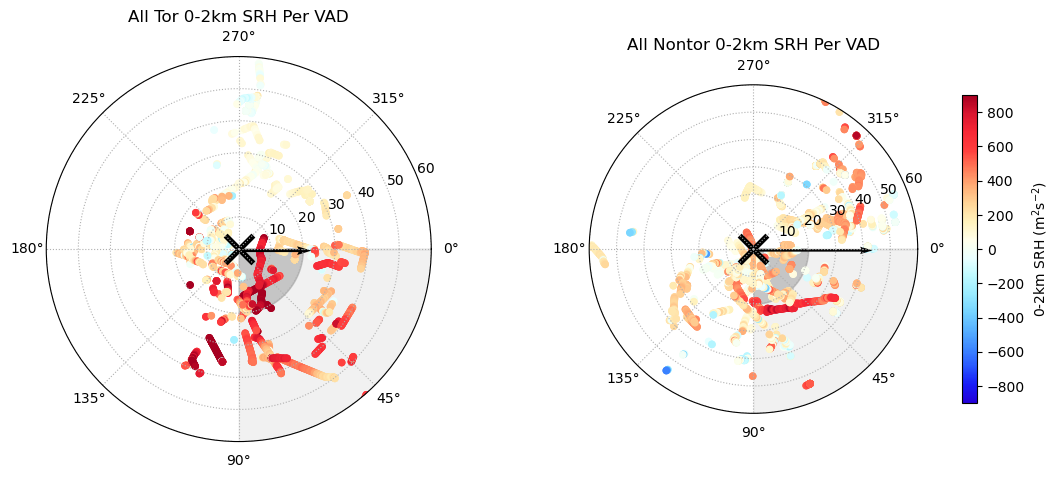

In [39]:
srw_srh_polar_plot('0-2km SRH', 900, -900, 60, '0-2km SRH (m$^{2}$s$^{-2})$')

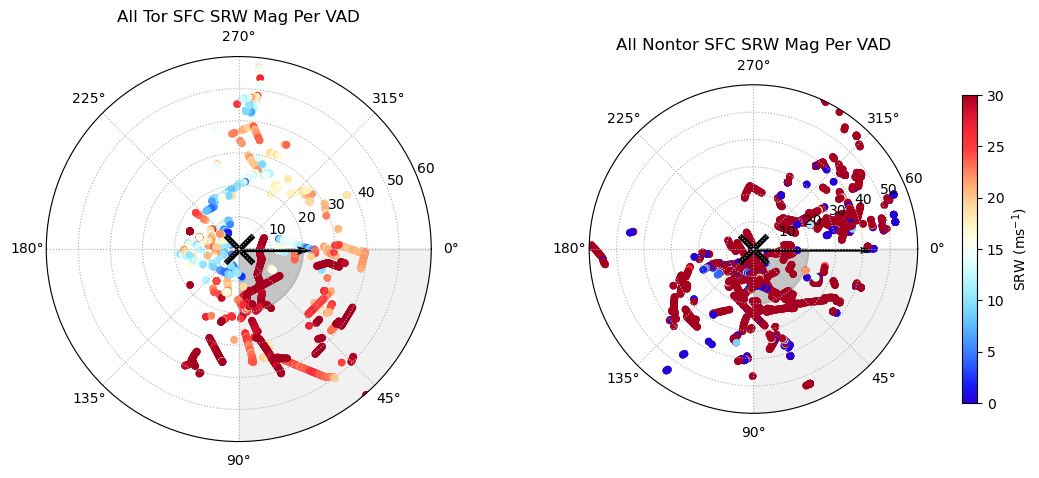

In [40]:
srw_srh_polar_plot('SFC SRW Mag', 30, 0, 60, 'SRW (ms$^{-1})$')

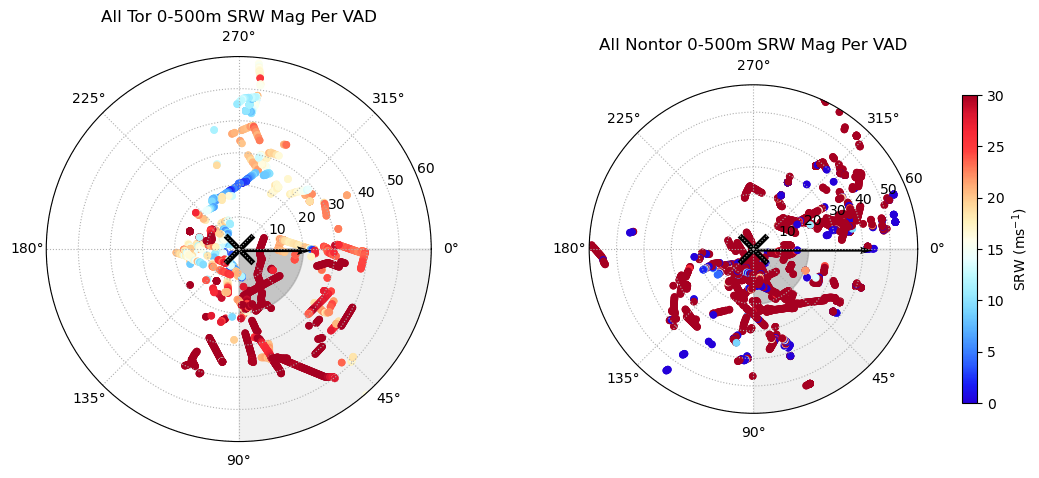

In [42]:
srw_srh_polar_plot('0-500m SRW Mag', 30, 0, 60, 'SRW (ms$^{-1})$')

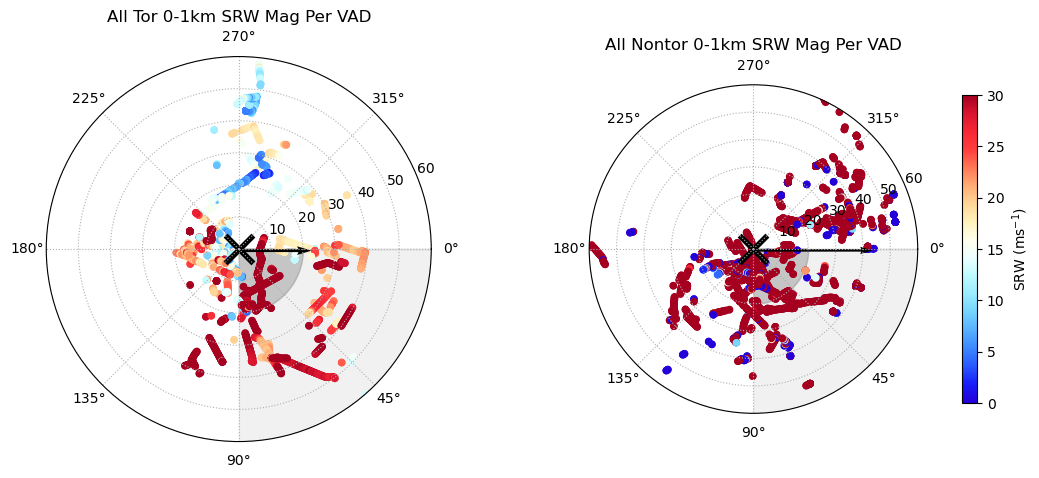

In [43]:
srw_srh_polar_plot('0-1km SRW Mag', 30, 0, 60, 'SRW (ms$^{-1})$')

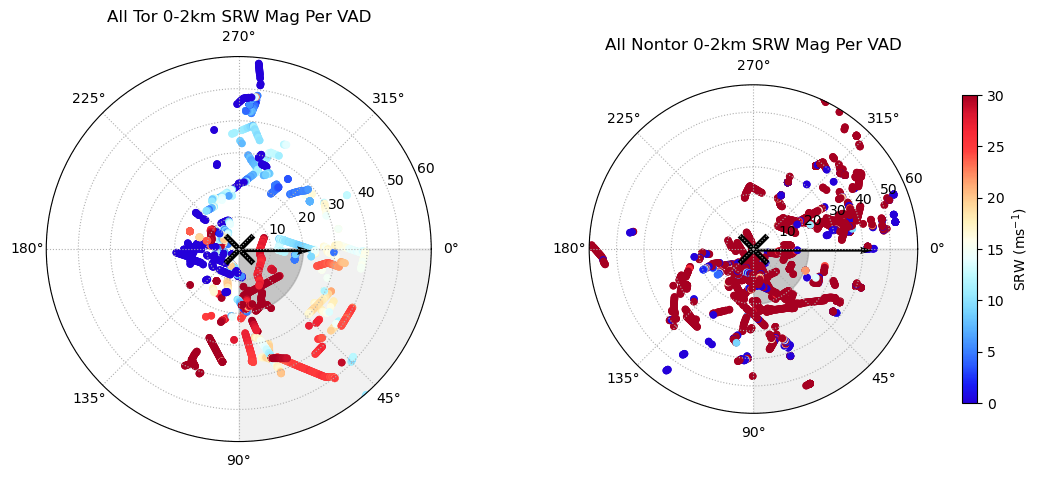

In [41]:
srw_srh_polar_plot('0-2km SRW Mag', 30, 0, 60, 'SRW (ms$^{-1})$')

Would I have to do Barnes analysis for the wind barb distributions?

In [54]:
def srw_srh_polar_plots_barbs(field, vmax, vmin, max_radius, cbar_label, col, skipby, title):
    import matplotlib.colors as mcolors
    #title = f'{d} 0-2km SRH Per VAD'
    from matplotlib import rcParams, rcParamsDefault
    rcParams.update(rcParamsDefault)
    
    # Create two subplots side by side
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, subplot_kw={'projection': 'polar'}, figsize=(13, 5))
    plt.subplots_adjust(wspace=0.3)  # Adjust space between subplots
    
    # ========== First Subplot (Tornadic VADs) ==========
    ax0.set_rlabel_position(-22.5)
    ax0.grid(True, linestyle=':')
    # ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
    ax0.set_theta_zero_location('E')
    ax0.set_theta_direction(-1)
    ax0.set_ylim([0, max_radius])
    
    # Shade regions
    nf0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
    ff0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')
    
    df_all_new_tor = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
    t_u = df_all_new_tor[df_all_new_tor['u or v'] == 'u']
    t_v = df_all_new_tor[df_all_new_tor['u or v'] == 'v']
    
    # Compute wind speed
    ta = np.nansum([t_u[col]**2, t_v[col]**2], axis=0)
    tspeed = np.sqrt(ta)
    
    # Get Py-ART colormap
    #cmap = pyart.graph.cm.pyart_BuDRd18
    
    # Normalize speed for colormap (adjust vmin/vmax as needed)
    norm = mcolors.Normalize(vmin=np.min(tspeed), vmax=np.max(tspeed))
    sm = plt.cm.ScalarMappable(cmap='pyart_BuDRd18', norm=norm)  # For colorbar
    tcolors = sm.to_rgba(tspeed)
    # Tornadic points
    tor_points = ax0.barbs(t_u['Angle'][::skipby] * (np.pi/180), t_u['Distance'][::skipby], 
                              t_u[col][::skipby], t_v[col][::skipby], t_u[field][::skipby], cmap='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))
    
    ax0.set_title(f'All Tor {col} Per VAD')
    
    ax1.set_rlabel_position(-22.5)
    ax1.grid(True, linestyle=':')
    # ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
    ax1.set_theta_zero_location('E')
    ax1.set_theta_direction(-1)
    ax1.set_ylim([0, max_radius])
    # Shade regions
    nf1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
    ff1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')
    
    
    df_all_new_nontor = df_all_new[df_all_new['Time From Tor (min)'] == 'nontor']
    nt_u = df_all_new_nontor[df_all_new_nontor['u or v'] == 'u']
    nt_v = df_all_new_nontor[df_all_new_nontor['u or v'] == 'v']
    
    # Compute wind speed
    nta = np.nansum([nt_u[col]**2, nt_v[col]**2], axis=0)
    ntspeed = np.sqrt(nta)
    
    nontor_points = ax1.barbs(nt_u['Angle'][::skipby] * (np.pi/180), nt_u['Distance'][::skipby], 
                             nt_u[col][::skipby], nt_v[col][::skipby], ntspeed[::skipby], cmap ='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))
    ax1.set_title(f'All Nontor {col} Per VAD')
    
    # nf = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='orange', alpha=0.5, label='Near-field')
    # ff = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='pink', alpha=0.3, label='Far-field')
    
    theta_start = np.deg2rad(100)
    ax0.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
    ax0.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
    
    ax1.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
    ax1.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
        
    # Colorbar
    cbar = fig.colorbar(tor_points, ax=[ax1], pad=0.1, shrink=0.8)
    cbar.set_label(f'{field} ' + cbar_label)
    
    #plt.suptitle(title, fontsize=13, fontweight='bold', ha='center')
    # Legend
    #plt.legend([nf, ff], ['Near-Field', 'Far-Field'], loc='upper left', fontsize=11)
    # plt.legend([storm_motion, nf, ff, meso], 
               #['Storm Motion', 'Near-Field', 'Far-Field', 'Mesocyclone'], loc = 'upper right', fontsize=11)
    
    #plt.savefig(f'/Users/juliabman/Desktop/spring2025_seminar/NontorvsTorPolarPlotsSRW', bbox_inches='tight')
    #fig.tight_layout()
    #plt.tight_layout()
    plt.suptitle(f'{field} ' + title)
    plt.show()

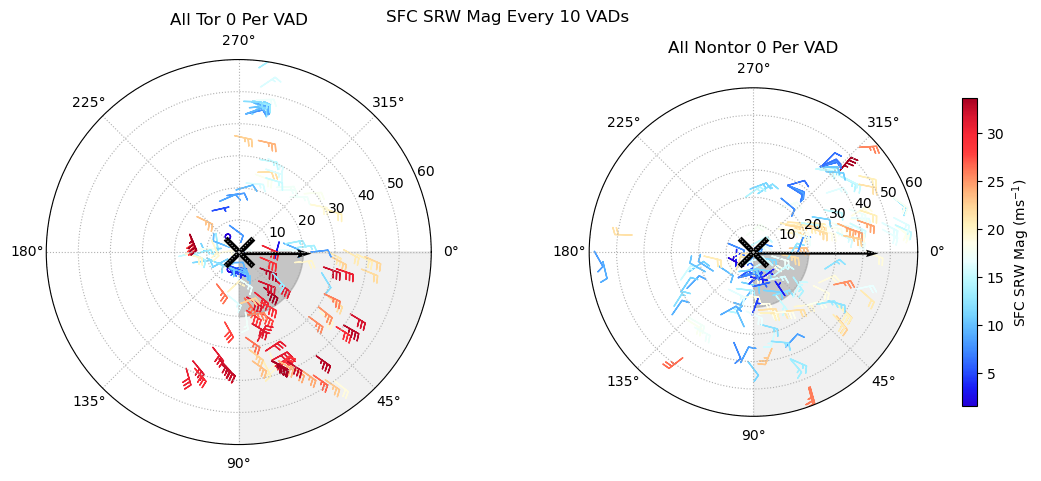

In [56]:
srw_srh_polar_plots_barbs('SFC SRW Mag', 30, 0, 60, '(ms$^{-1})$', '0', 10, 'Every 10 VADs')

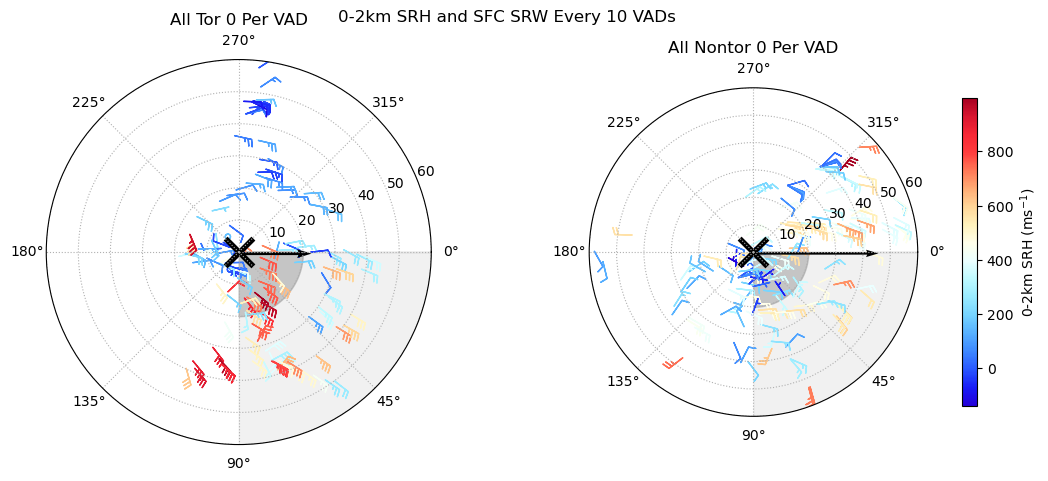

In [60]:
srw_srh_polar_plots_barbs('0-2km SRH', 30, 0, 60, '(ms$^{-1})$', '0', 10, 'and SFC SRW Every 10 VADs')

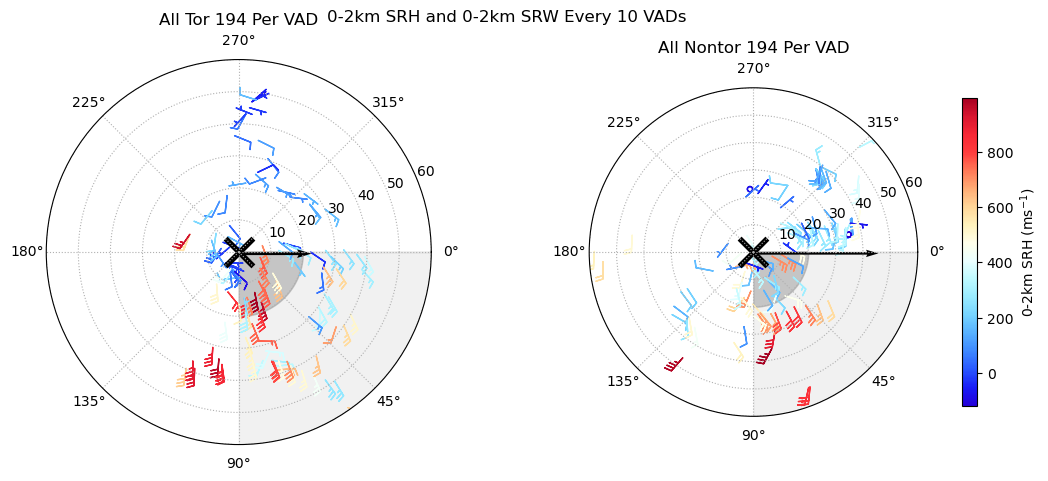

In [59]:
srw_srh_polar_plots_barbs('0-2km SRH', 30, 0, 60, '(ms$^{-1})$', '194', 10, 'and 0-2km SRW Every 10 VADs')

In [ ]:
import matplotlib.colors as mcolors
#title = f'{d} 0-2km SRH Per VAD'
vmax = 30
vmin = 0
from matplotlib import rcParams, rcParamsDefault
rcParams.update(rcParamsDefault)

max_radius = 60
#vmin = 0
#vmax = 30

col = '0'
# Create two subplots side by side
fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, subplot_kw={'projection': 'polar'}, figsize=(13, 5))
plt.subplots_adjust(wspace=0.3)  # Adjust space between subplots

# ========== First Subplot (Tornadic VADs) ==========
ax0.set_rlabel_position(-22.5)
ax0.grid(True, linestyle=':')
# ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
ax0.set_theta_zero_location('E')
ax0.set_theta_direction(-1)
ax0.set_ylim([0, max_radius])

# Shade regions
nf0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
ff0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')

df0 = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']#[df_all_new['Date'] == '20230527']
df = df0[df0['Date'] == '20230615']
df_all_new_tor = df.iloc[np.where(df['Time From Tor (min)'].astype(int) < 0)]
t_u = df_all_new_tor[df_all_new_tor['u or v'] == 'u']
t_v = df_all_new_tor[df_all_new_tor['u or v'] == 'v']

# Compute wind speed
ta = np.nansum([t_u[col]**2, t_v[col]**2], axis=0)
tspeed = np.sqrt(ta)

# Get Py-ART colormap
#cmap = pyart.graph.cm.pyart_BuDRd18

# Normalize speed for colormap (adjust vmin/vmax as needed)
norm = mcolors.Normalize(vmin=np.min(tspeed), vmax=np.max(tspeed))
sm = plt.cm.ScalarMappable(cmap='pyart_BuDRd18', norm=norm)  # For colorbar
tcolors = sm.to_rgba(tspeed)
# Tornadic points
# tor_points = ax0.barbs(t_u['Angle'][::10] * (np.pi/180), t_u['Distance'][::10], 
#                           t_u[col][::10], t_v[col][::10], t_u['0-2km SRH'][::10], cmap='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))

tor_points = ax0.barbs(t_u['Angle'] * (np.pi/180), t_u['Distance'], 
                          t_u[col], t_v[col], t_u['0-2km SRH'], cmap='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))

ax0.set_title(f'All PreTor Per VAD')

ax1.set_rlabel_position(-22.5)
ax1.grid(True, linestyle=':')
# ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
ax1.set_theta_zero_location('E')
ax1.set_theta_direction(-1)
ax1.set_ylim([0, max_radius])
# Shade regions
nf1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
ff1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')


df_all_new_nontor = df.iloc[np.where(df['Time From Tor (min)'].astype(int) == 0)]
nt_u = df_all_new_nontor[df_all_new_nontor['u or v'] == 'u']
nt_v = df_all_new_nontor[df_all_new_nontor['u or v'] == 'v']

# Compute wind speed
nta = np.nansum([nt_u[col]**2, nt_v[col]**2], axis=0)
ntspeed = np.sqrt(nta)

# nontor_points = ax1.barbs(nt_u['Angle'][::10] * (np.pi/180), nt_u['Distance'][::10], 
#                          nt_u[col][::10], nt_v[col][::10], ntspeed[::10], cmap ='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))

nontor_points = ax1.barbs(nt_u['Angle'] * (np.pi/180), nt_u['Distance'], 
                         nt_u[col], nt_v[col], ntspeed, cmap ='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))
ax1.set_title(f'All During Tor Per VAD')

# nf = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='orange', alpha=0.5, label='Near-field')
# ff = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='pink', alpha=0.3, label='Far-field')

theta_start = np.deg2rad(100)
ax0.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion', alpha=0.5)
ax0.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)

ax1.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion', alpha=0.5)
ax1.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
    
# Colorbar
cbar = fig.colorbar(tor_points, ax=[ax1], pad=0.1, shrink=0.8)
cbar.set_label('SRH (m$^{2}$s$^{-1})$')

#plt.suptitle(title, fontsize=13, fontweight='bold', ha='center')
# Legend
#plt.legend([nf, ff], ['Near-Field', 'Far-Field'], loc='upper left', fontsize=11)
# plt.legend([storm_motion, nf, ff, meso], 
           #['Storm Motion', 'Near-Field', 'Far-Field', 'Mesocyclone'], loc = 'upper right', fontsize=11)

#plt.savefig(f'/Users/juliabman/Desktop/spring2025_seminar/NontorvsTorPolarPlotsSRW', bbox_inches='tight')
#fig.tight_layout()
#plt.tight_layout()
plt.suptitle('SFC SRW Pretor vs During Tor 20220523')
plt.show()

In [ ]:
import matplotlib.colors as mcolors
#title = f'{d} 0-2km SRH Per VAD'
vmax = 30
vmin = 0
from matplotlib import rcParams, rcParamsDefault
rcParams.update(rcParamsDefault)

max_radius = 60
#vmin = 0
#vmax = 30

col = '0'
# Create two subplots side by side
fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, subplot_kw={'projection': 'polar'}, figsize=(13, 5))
plt.subplots_adjust(wspace=0.3)  # Adjust space between subplots

# ========== First Subplot (Tornadic VADs) ==========
ax0.set_rlabel_position(-22.5)
ax0.grid(True, linestyle=':')
# ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
ax0.set_theta_zero_location('E')
ax0.set_theta_direction(-1)
ax0.set_ylim([0, max_radius])

# Shade regions
nf0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
ff0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')

df_all_new_tor = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
t_u = df_all_new_tor[df_all_new_tor['u or v'] == 'u']
t_v = df_all_new_tor[df_all_new_tor['u or v'] == 'v']

t_u_02km = np.nansum([t_u['195'], - t_u['0']], axis=0)
t_v_02km = np.nansum([t_v['195'], - t_v['0']], axis=0)
# Compute wind speed
ta = np.nansum([t_u_02km**2, t_v_02km**2], axis=0)
tspeed = np.sqrt(ta)

# Get Py-ART colormap
#cmap = pyart.graph.cm.pyart_BuDRd18

# Normalize speed for colormap (adjust vmin/vmax as needed)
norm = mcolors.Normalize(vmin=np.min(tspeed), vmax=np.max(tspeed))
sm = plt.cm.ScalarMappable(cmap='pyart_BuDRd18', norm=norm)  # For colorbar
tcolors = sm.to_rgba(tspeed)
# Tornadic points
tor_points = ax0.barbs(t_u['Angle'][::10] * (np.pi/180), t_u['Distance'][::10], 
                          t_u_02km[::10], t_v_02km[::10], tspeed[::10], cmap='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))

ax0.set_title(f'All Tor {col} Per VAD')

ax1.set_rlabel_position(-22.5)
ax1.grid(True, linestyle=':')
# ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
ax1.set_theta_zero_location('E')
ax1.set_theta_direction(-1)
ax1.set_ylim([0, max_radius])
# Shade regions
nf1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
ff1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')


df_all_new_nontor = df_all_new[df_all_new['Time From Tor (min)'] == 'nontor']
nt_u = df_all_new_nontor[df_all_new_nontor['u or v'] == 'u']
nt_v = df_all_new_nontor[df_all_new_nontor['u or v'] == 'v']

nt_u_02km = np.nansum([nt_u['195'], - nt_u['0']], axis=0)
nt_v_02km = np.nansum([nt_v['195'], - nt_v['0']], axis=0)
# Compute wind speed
nta = np.nansum([nt_u_02km**2, nt_v_02km**2], axis=0)
ntspeed = np.sqrt(nta)

nontor_points = ax1.barbs(nt_u['Angle'][::10] * (np.pi/180), nt_u['Distance'][::10], 
                         nt_u_02km[::10], nt_v_02km[::10], ntspeed[::10], cmap ='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))
ax1.set_title(f'All Nontor 0-2km Vertical Shear Per VAD')

# nf = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='orange', alpha=0.5, label='Near-field')
# ff = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='pink', alpha=0.3, label='Far-field')

theta_start = np.deg2rad(100)
ax0.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
ax0.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)

ax1.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
ax1.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
    
# Colorbar
cbar = fig.colorbar(tor_points, ax=[ax1], pad=0.1, shrink=0.8)
cbar.set_label('Shear (ms$^{-1})$')

#plt.suptitle(title, fontsize=13, fontweight='bold', ha='center')
# Legend
#plt.legend([nf, ff], ['Near-Field', 'Far-Field'], loc='upper left', fontsize=11)
# plt.legend([storm_motion, nf, ff, meso], 
           #['Storm Motion', 'Near-Field', 'Far-Field', 'Mesocyclone'], loc = 'upper right', fontsize=11)

#plt.savefig(f'/Users/juliabman/Desktop/spring2025_seminar/NontorvsTorPolarPlotsSRW', bbox_inches='tight')
#fig.tight_layout()
#plt.tight_layout()
plt.suptitle('0-2km Vertical Wind Shear Every 10 points', style='oblique')
plt.show()

# Shear mag boxplots

In [ ]:
def tor_boxplot(data_dict, title):
    
    labels = ['NonTor', 'TorAll', 'PreTor', 'DuringTor', 'PostTor']

    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
    
    ax0.boxplot([data_dict['nf_nontor'], data_dict['nf_tor'], data_dict['nf_pretor'], data_dict['nf_dtor'], 
                 data_dict['nf_posttor']], labels = labels)
    
    #ax0.set_xticks(ticks = labels)
    #ax0.set_yticks(fontsize=13)
    ax0.set_ylabel('Shear Magnitude (m/s)', fontweight='bold', fontsize=10)
    ax0.grid()
    ax0.set_title(f'{title} Per Near-Field VAD', fontweight='bold', fontsize=10, wrap= True)
    
    ax1.boxplot([data_dict['ff_nontor'], data_dict['ff_tor'], data_dict['ff_pretor'], data_dict['ff_dtor'], 
                 data_dict['ff_posttor']], labels = labels)
    
    ax1.set_ylabel('Shear Magnitude (m/s)', fontweight='bold', fontsize=10)
    ax1.grid()
    ax1.set_title(f'{title} Per Far-Field VAD', fontweight='bold', fontsize=10, wrap=True)
    
    fig.tight_layout()
    plt.show()

In [ ]:
tor_boxplot(mag_all_500m, '0-500m Shear Magnitude')

In [ ]:
tor_boxplot(mag_all_500m_new, '0-500m Shear Magnitude NEW')

In [ ]:
tor_boxplot(mag_all_1km, '0-1km Shear Magnitude')

In [ ]:
tor_boxplot(mag_all_1km_new, '0-1km Shear Magnitude NEW')

In [ ]:
tor_boxplot(mag_all_2km, '0-2km Shear Magnitude')

In [ ]:
tor_boxplot(mag_all_2km_new, '0-2km Shear Magnitude NEW')

# Case Metadata

Per Case

In [ ]:
for d in sorted(set(df_all_new['Date'])):
    counts_dist, bins_dist = np.histogram(df_all_new[df_all_new['Date'] == d]['Distance'])
    counts_angle, bins_angle = np.histogram(df_all_new[df_all_new['Date'] == d]['Angle'])
    
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
    ax0.hist(bins_dist[:-1], bins_dist, weights=counts_dist)
    ax0.set_xlabel('Distance From Meso (km)')
    ax0.set_ylabel('VADs Count')
    ax0.set_title(f'Tornadic Case VADs Count per Distance {d} NEW')
    ax1.hist(bins_angle[:-1], bins_angle, weights=counts_angle)
    ax1.set_xlabel('VAD Bearing Relative to Meso (Degrees from East)')
    ax1.set_title(f'Case VADs Count per Angle {d} NEW')
    fig.suptitle(f'{d} VADs Distance and Angle Relative to Meso NEW')
    plt.show()

All Cases

In [ ]:
counts_dist, bins_dist = np.histogram(df_all[df_all['Time From Tor (min)'] != 'nontor']['Distance'])

counts_angle, bins_angle = np.histogram(df_all[df_all['Time From Tor (min)'] != 'nontor']['Angle'])

fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
ax0.hist(bins_dist[:-1], bins_dist, weights=counts_dist)
ax0.set_xlabel('Distance From Meso (km)')
ax0.set_ylabel('VADs Count')
ax0.set_title('Tornadic Case VADs Count per Distance')
ax1.hist(bins_angle[:-1], bins_angle, weights=counts_angle)
ax1.set_xlabel('VAD Bearing Relative to Meso (Degrees from East)')
ax1.set_title('Tornadic Case VADs Count per Angle')
plt.show()

In [ ]:
counts_dist, bins_dist = np.histogram(df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']['Distance'])

counts_angle, bins_angle = np.histogram(df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']['Angle'])

fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
ax0.hist(bins_dist[:-1], bins_dist, weights=counts_dist)
ax0.set_xlabel('Distance From Meso (km)')
ax0.set_ylabel('VADs Count')
ax0.set_title('Tornadic Case VADs Count per Distance (New 2ndTrip)')
ax1.hist(bins_angle[:-1], bins_angle, weights=counts_angle)
ax1.set_xlabel('VAD Bearing Relative to Meso (Degrees from East)')
ax1.set_title('Tornadic Case VADs Count per Angle (New 2ndTrip)')
plt.show()

# Temporal SRH and SRW?

<Figure size 600x400 with 0 Axes>

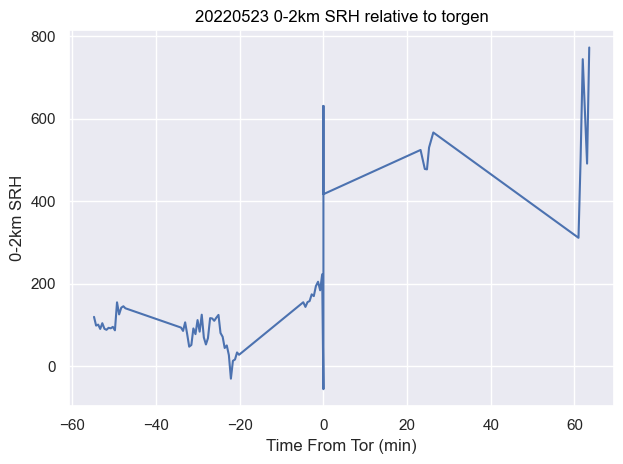

<Figure size 600x400 with 0 Axes>

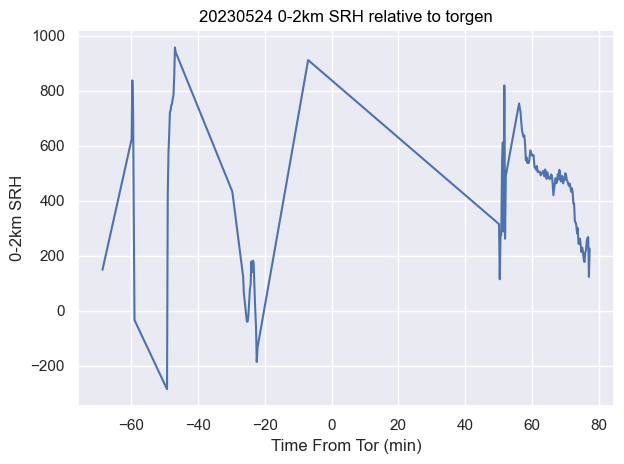

<Figure size 600x400 with 0 Axes>

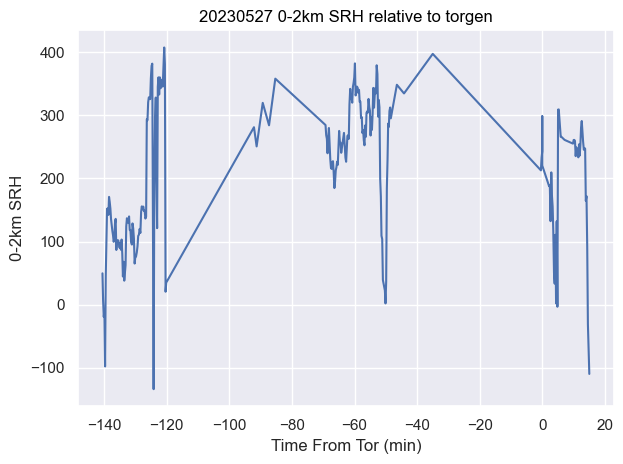

<Figure size 600x400 with 0 Axes>

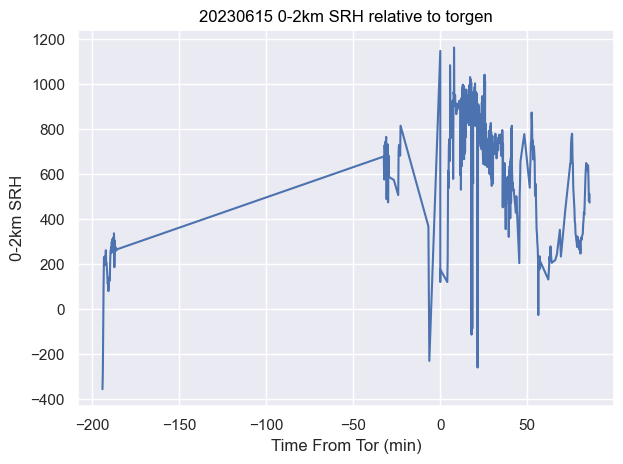

<Figure size 600x400 with 0 Axes>

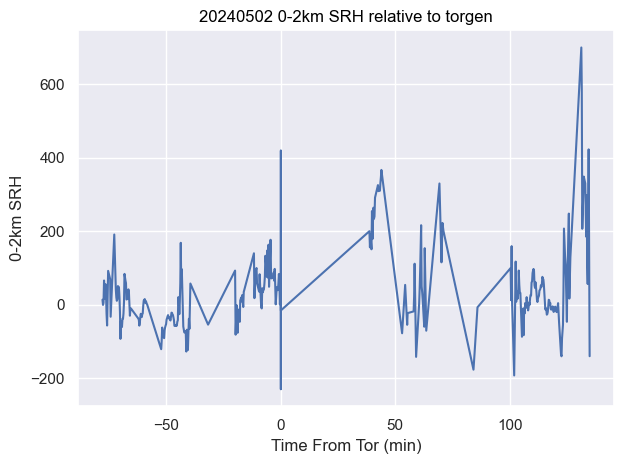

<Figure size 600x400 with 0 Axes>

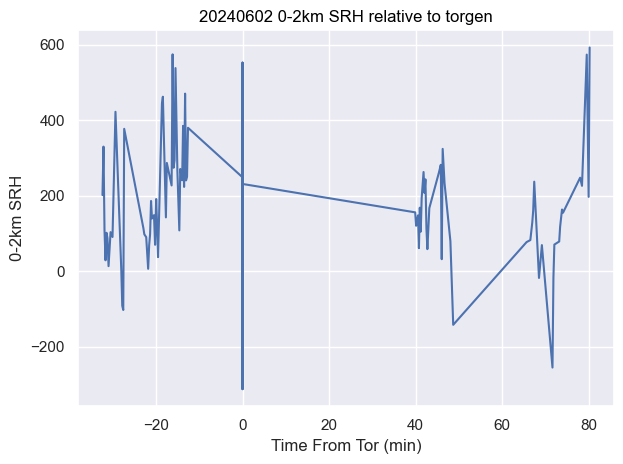

In [17]:
from seaborn import objects
import warnings
warnings.filterwarnings('ignore')

for d in sorted(set(df_all_new['Date'])):
    if df_all_new[df_all_new['Date'] == d]['Time From Tor (min)'].ne('nontor').any():
        df = df_all_new[df_all_new['Date'] == d]
        fig = plt.figure(figsize=(6,4))
        p = sns.objects.Plot(data = df, x="Time From Tor (min)", y="0-2km SRH").add(sns.objects.Line()).label(title=f'{d} 0-2km SRH relative to torgen')
        p.show()

<Figure size 600x400 with 0 Axes>

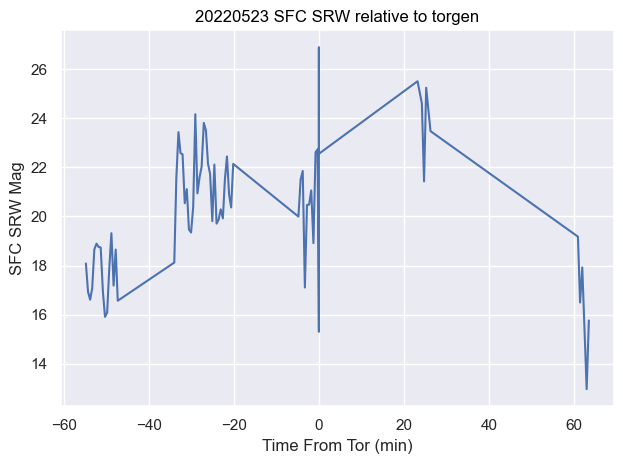

<Figure size 600x400 with 0 Axes>

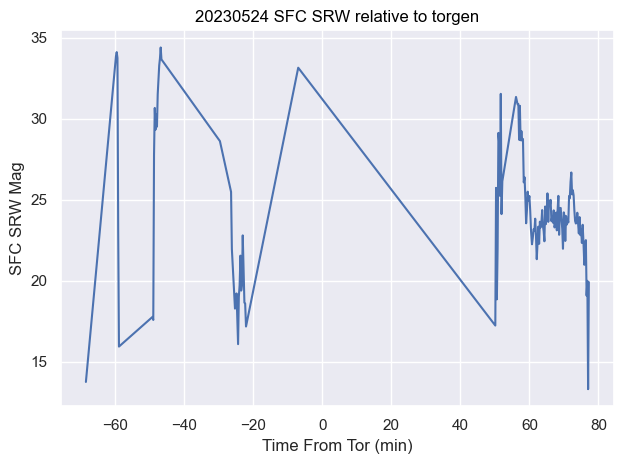

<Figure size 600x400 with 0 Axes>

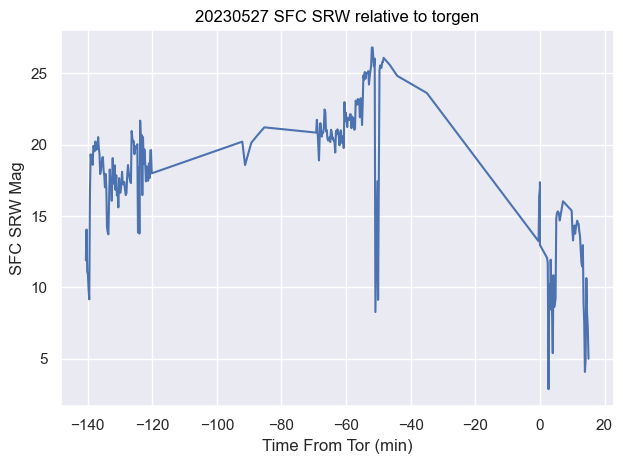

<Figure size 600x400 with 0 Axes>

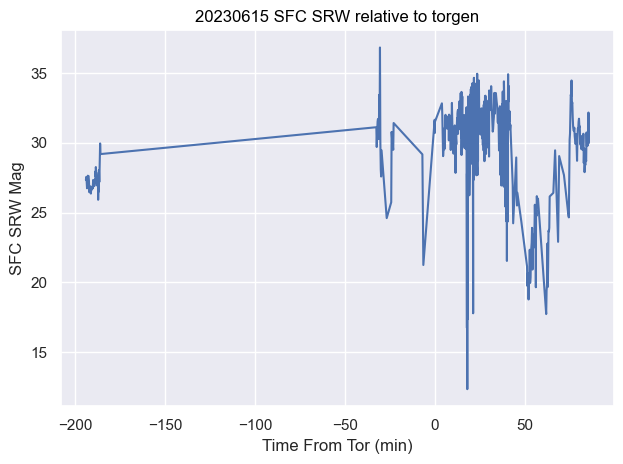

<Figure size 600x400 with 0 Axes>

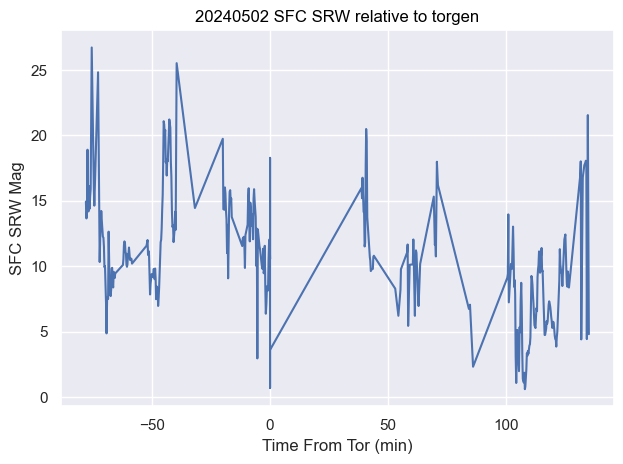

<Figure size 600x400 with 0 Axes>

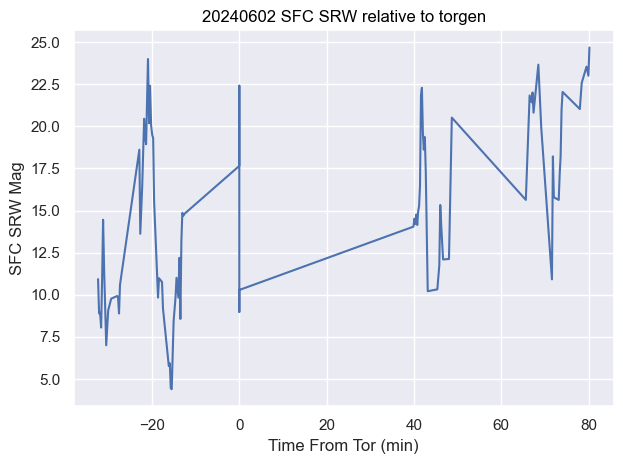

In [71]:
from seaborn import objects
import warnings
warnings.filterwarnings('ignore')

for d in sorted(set(df_all_new['Date'])):
    if df_all_new[df_all_new['Date'] == d]['Time From Tor (min)'].ne('nontor').any():
        df = df_all_new[df_all_new['Date'] == d]
        fig = plt.figure(figsize=(6,4))
        p = sns.objects.Plot(data = df, x="Time From Tor (min)", y="SFC SRW Mag").add(sns.objects.Line()).label(title=f'{d} SFC SRW relative to torgen')
        p.show()

<Figure size 600x400 with 0 Axes>

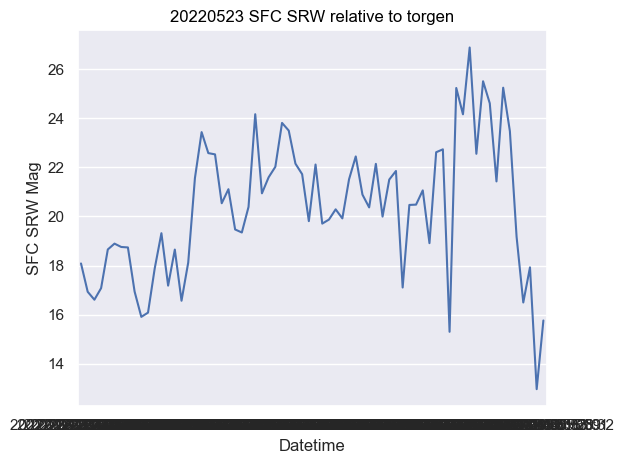

<Figure size 600x400 with 0 Axes>

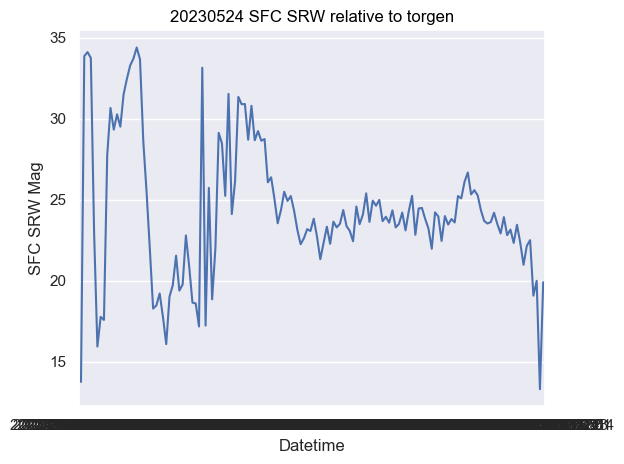

<Figure size 600x400 with 0 Axes>

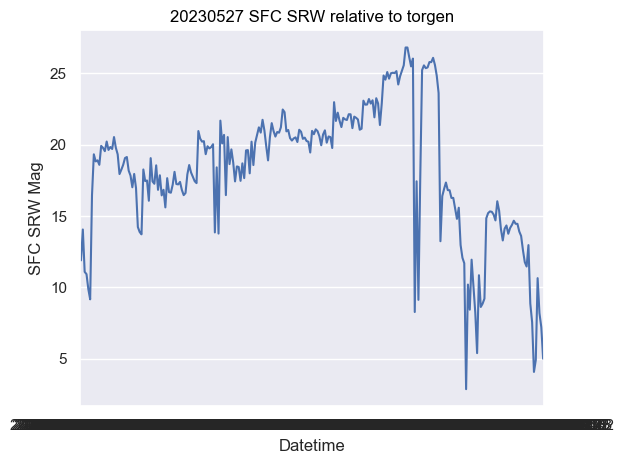

<Figure size 600x400 with 0 Axes>

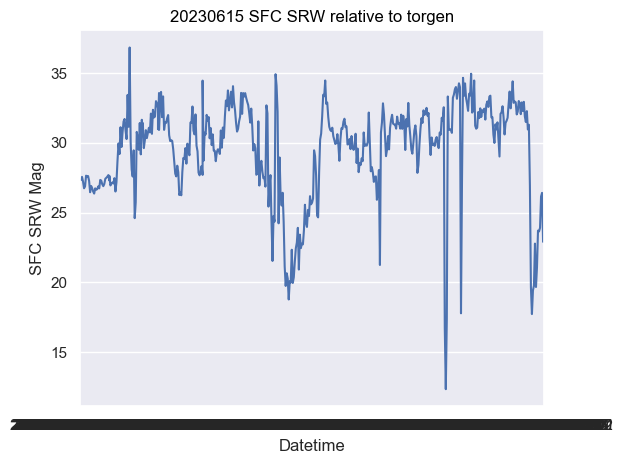

<Figure size 600x400 with 0 Axes>

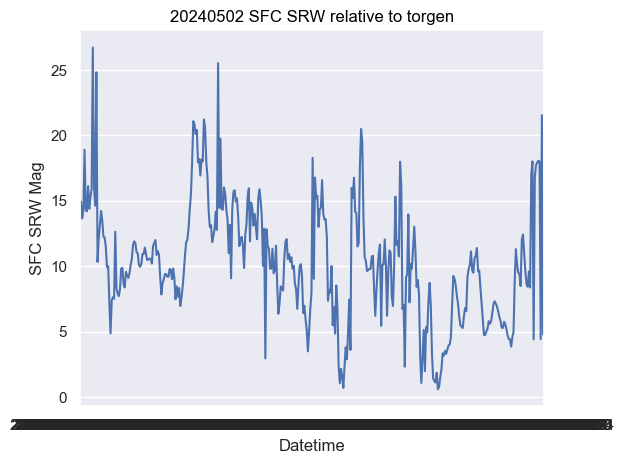

<Figure size 600x400 with 0 Axes>

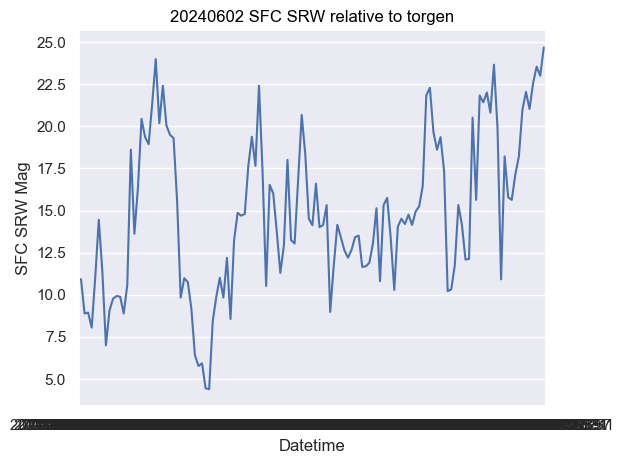

In [75]:
from seaborn import objects
import warnings
warnings.filterwarnings('ignore')

for d in sorted(set(df_all_new['Date'])):
    if df_all_new[df_all_new['Date'] == d]['Time From Tor (min)'].ne('nontor').any():
        df = df_all_new[df_all_new['Date'] == d]
        fig = plt.figure(figsize=(6,4))
        p = sns.objects.Plot(data = df, x="Datetime", y="SFC SRW Mag").add(sns.objects.Line()).label(title=f'{d} SFC SRW relative to torgen')
        p.show()

<Figure size 600x400 with 0 Axes>

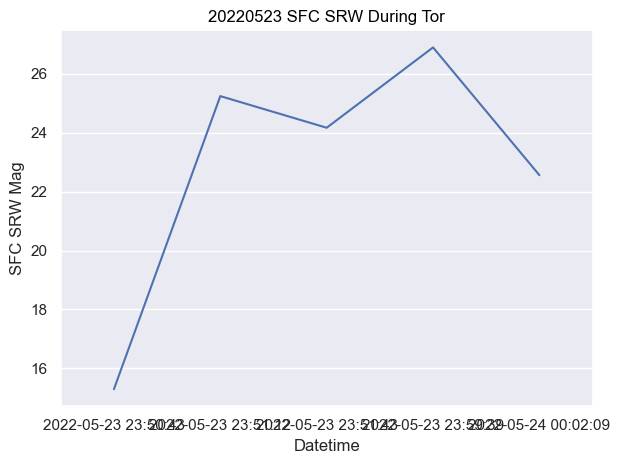

<Figure size 600x400 with 0 Axes>

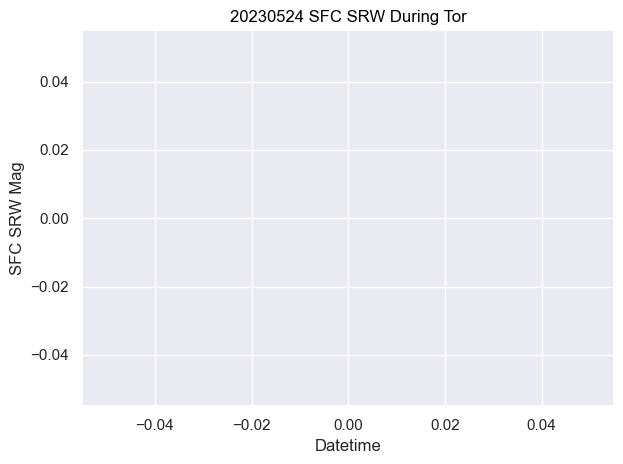

<Figure size 600x400 with 0 Axes>

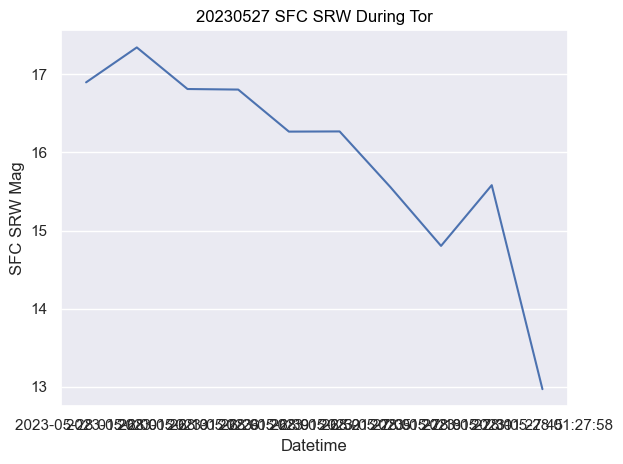

<Figure size 600x400 with 0 Axes>

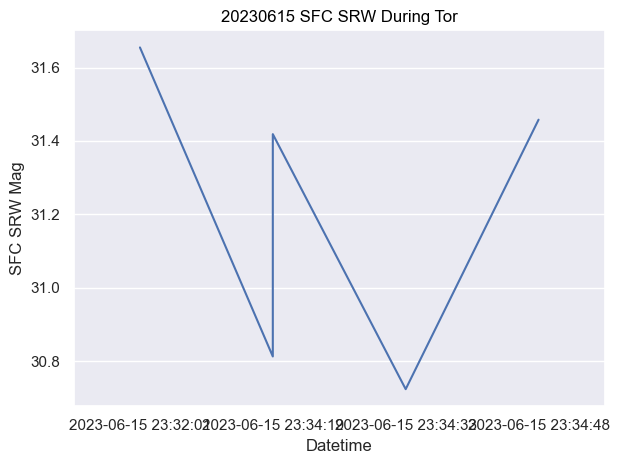

<Figure size 600x400 with 0 Axes>

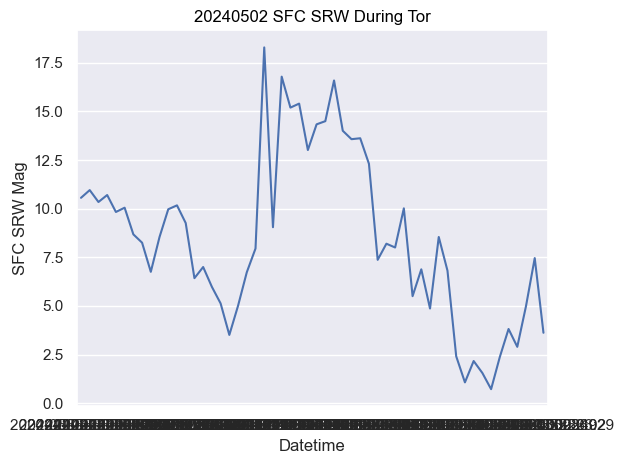

<Figure size 600x400 with 0 Axes>

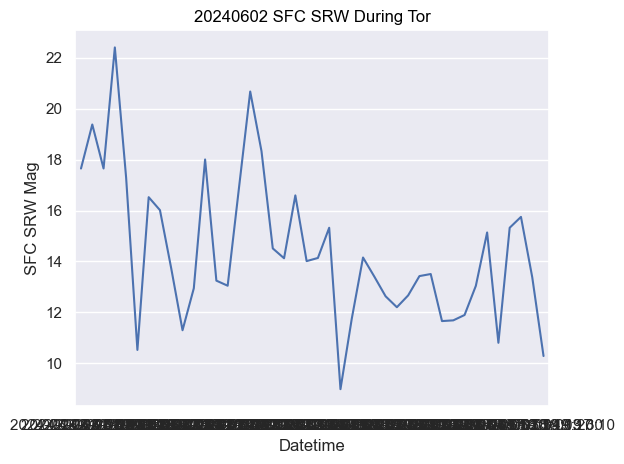

In [301]:
from seaborn import objects
import warnings
warnings.filterwarnings('ignore')

for d in sorted(set(df_all_new['Date'])):
    if df_all_new[df_all_new['Date'] == d]['Time From Tor (min)'].ne('nontor').any():
        df0 = df_all_new[df_all_new['Date'] == d]
        df = df0[df0['Time From Tor (min)'] == 0]
        fig = plt.figure(figsize=(6,4))
        p = sns.objects.Plot(data = df, x="Datetime", y="SFC SRW Mag").add(sns.objects.Line()).label(title=f'{d} SFC SRW During Tor')
        p.show()

<Figure size 600x400 with 0 Axes>

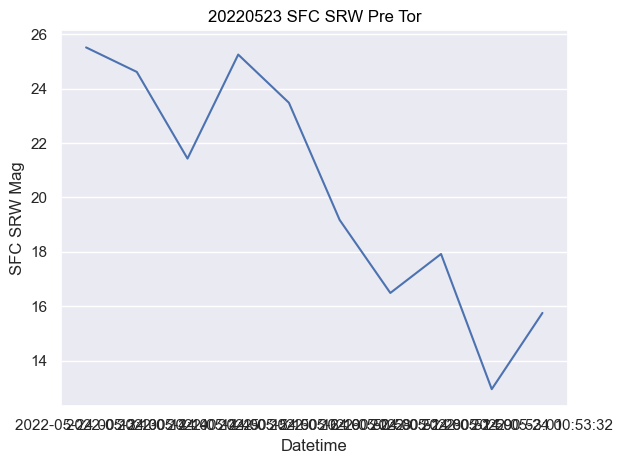

<Figure size 600x400 with 0 Axes>

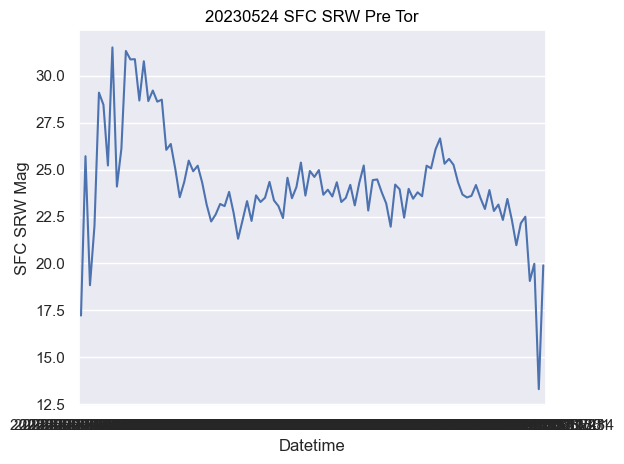

<Figure size 600x400 with 0 Axes>

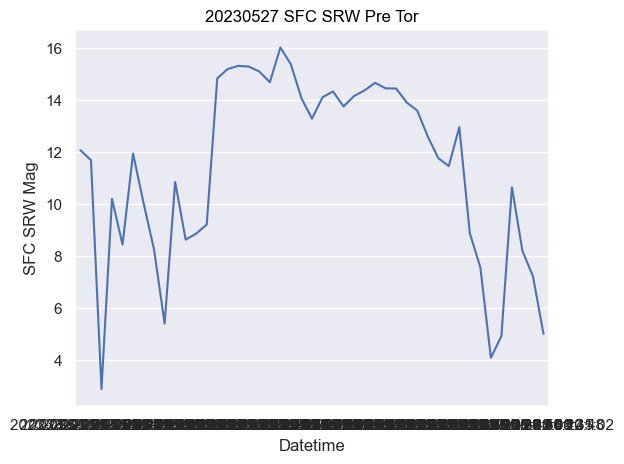

<Figure size 600x400 with 0 Axes>

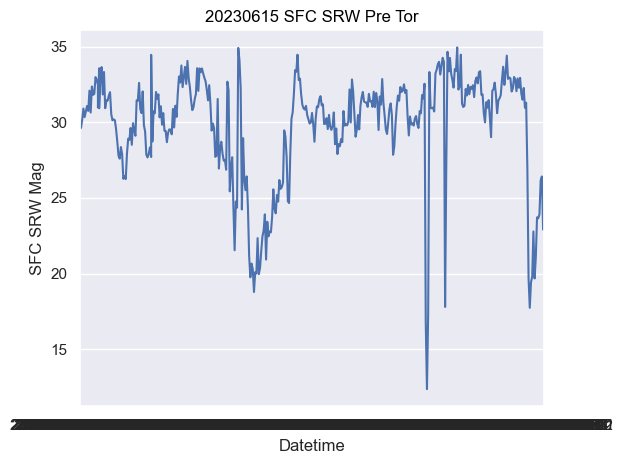

<Figure size 600x400 with 0 Axes>

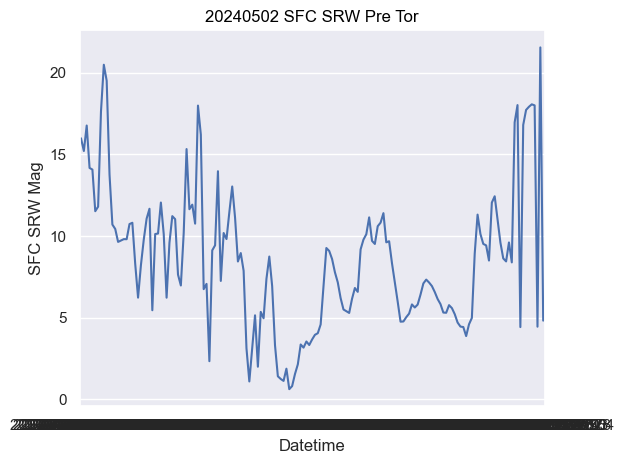

<Figure size 600x400 with 0 Axes>

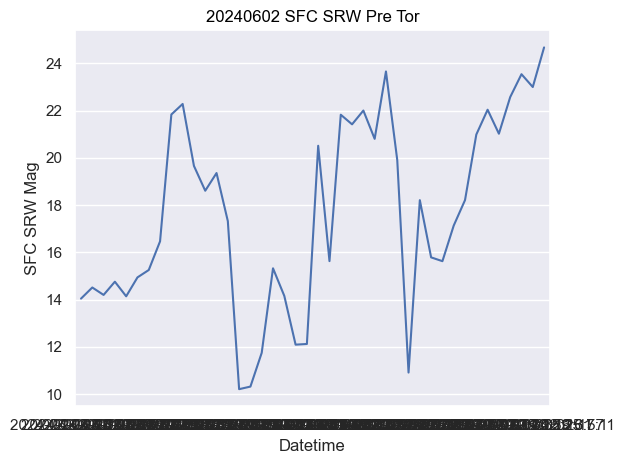

In [302]:
from seaborn import objects
import warnings
warnings.filterwarnings('ignore')

for d in sorted(set(df_all_new['Date'])):
    if df_all_new[df_all_new['Date'] == d]['Time From Tor (min)'].ne('nontor').any():
        df0 = df_all_new[df_all_new['Date'] == d]
        df = df0[df0['Time From Tor (min)'] > 0]
        fig = plt.figure(figsize=(6,4))
        p = sns.objects.Plot(data = df, x="Datetime", y="SFC SRW Mag").add(sns.objects.Line()).label(title=f'{d} SFC SRW Pre Tor')
        p.show()

In [159]:
df_all_new

,0,1,2,3,4,5,6,7,8,9,...,Time From Tor (min),Datetime,Date,Tor or Nontor,SFC SRW Mag,0-500m SRW Mag,0-1km SRW Mag,0-2km SRW Mag,0-2km SRH,0-1km SRH
0,-16.835770,-16.755274,-16.687143,-16.646894,-16.591278,-16.606508,-16.596056,-16.624393,-16.698717,-16.813435,...,-54.833333,2022-05-23 22:55:10,20220523,tor,18.084001,19.302792,18.473383,13.340017,119.748598,81.601290
1,-14.939102,-15.009944,-15.074447,-15.129332,-15.258727,-15.290950,-15.374236,-15.448551,-15.529462,-15.613126,...,-54.333333,2022-05-23 22:55:40,20220523,tor,16.929266,18.590600,17.777007,13.117256,98.612390,53.953928
2,-14.908146,-15.014770,-15.122228,-15.226007,-15.440908,-15.526935,-15.692964,-15.829327,-15.938499,-16.014187,...,-53.833333,2022-05-23 22:56:10,20220523,tor,16.606345,18.680288,17.533481,12.630869,100.986069,63.738470
3,-14.967583,-15.150704,-15.295214,-15.410604,-15.666528,-15.871101,-15.918962,-16.046745,-16.148834,-16.246586,...,-53.35,2022-05-23 22:56:39,20220523,tor,17.077444,18.364092,17.398431,11.940222,90.521531,52.715599
4,-15.580977,-15.710516,-15.809145,-15.890134,-16.091858,-16.142567,-16.262787,-16.348358,-16.409420,-16.458860,...,-52.85,2022-05-23 22:57:09,20220523,tor,18.654303,18.533768,18.004913,12.514061,104.417661,52.484157
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6595,-1.635275,-1.568471,-1.420855,-1.320286,-1.320286,-1.102728,-1.051306,-0.936231,-0.836507,-0.828301,...,63.566667,2023-06-16 00:34:34,20230615,tor,23.652900,24.142144,12.620730,4.804360,244.074307,221.865744
6596,-3.691865,-3.578943,-3.513133,-3.421503,-3.421503,-3.236247,-3.157359,-3.030900,-2.966462,-2.847811,...,63.783333,2023-06-16 00:34:47,20230615,tor,23.917808,23.224960,11.152169,3.214427,226.896842,217.227740
6597,-3.230326,-3.062784,-2.947798,-2.882831,-2.882831,-2.730972,-2.657030,-2.451415,-2.396161,-2.222835,...,64.0,2023-06-16 00:35:00,20230615,tor,26.158343,23.125663,11.074837,3.195468,206.528619,195.927016
6598,-4.028626,-3.970635,-3.912552,-3.842394,-3.842394,-3.703241,-3.636965,-3.529508,-3.464480,-3.379116,...,66.033333,2023-06-16 00:37:02,20230615,tor,26.418142,23.072401,10.245528,2.997714,218.595898,201.388554


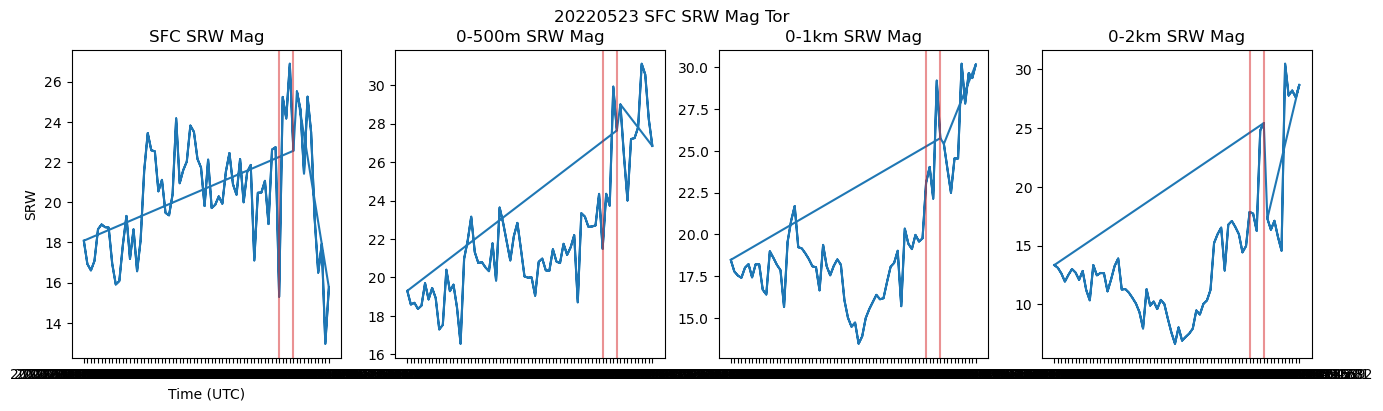

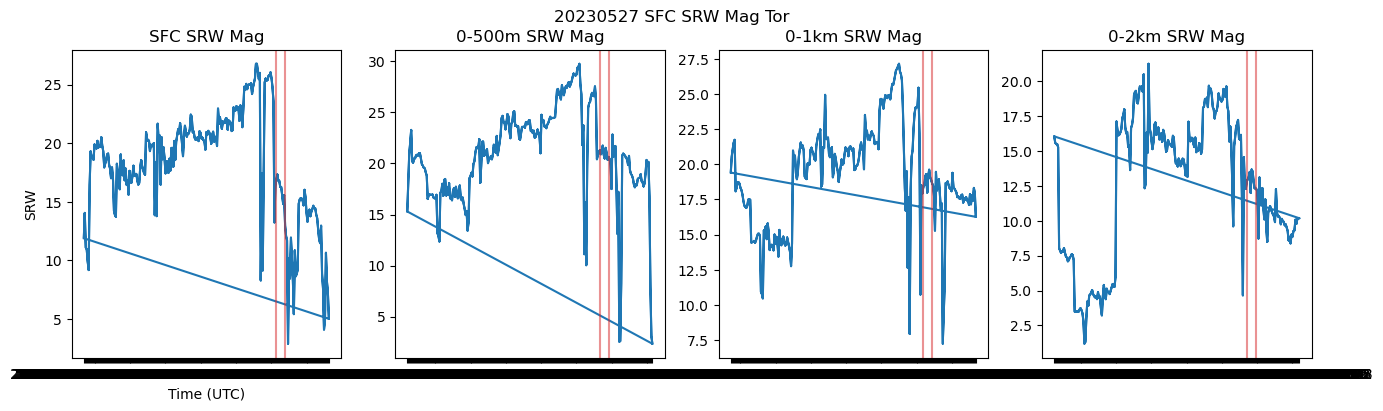

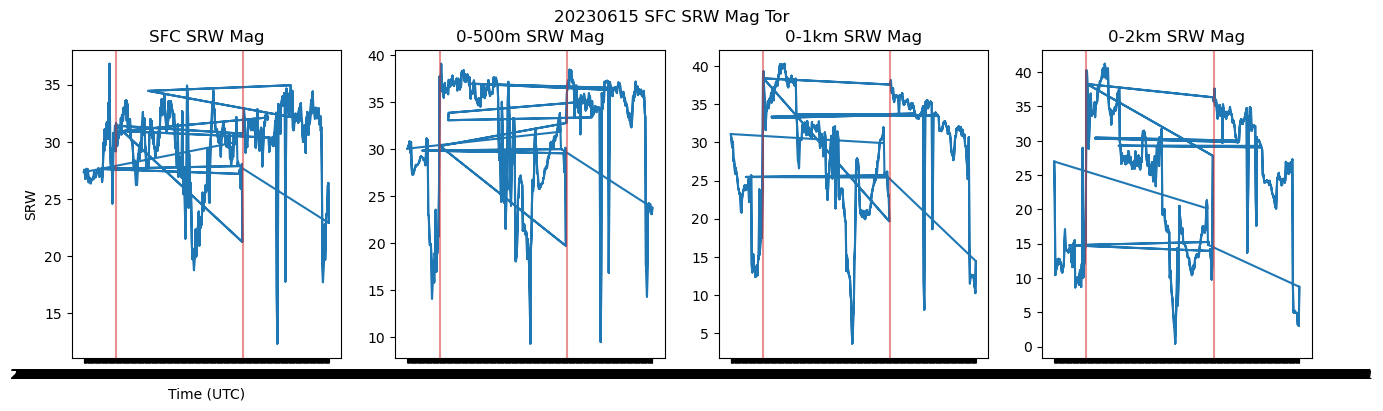

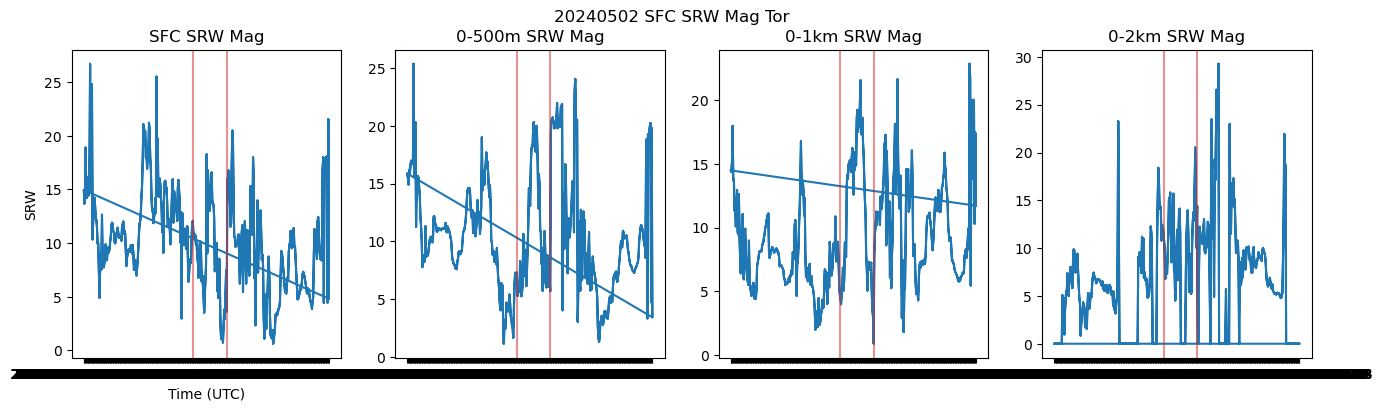

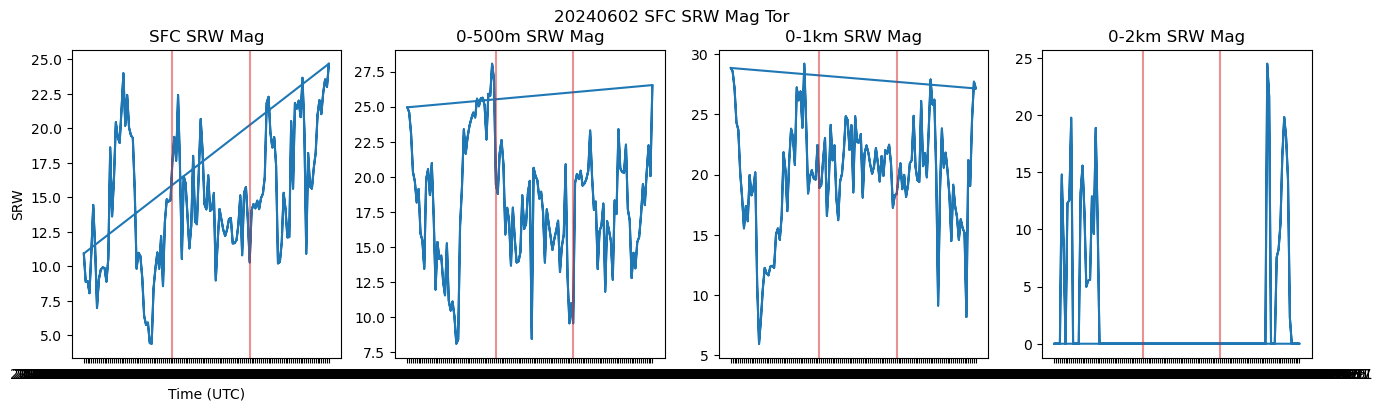

In [324]:
from seaborn import objects
import warnings
warnings.filterwarnings('ignore')
col = 'SFC SRW Mag'
n = 10

for d in sorted(set(df_all_new['Date'])):
    if df_all_new[df_all_new['Date'] == d]['Time From Tor (min)'].ne('nontor').any():
        df = df_all_new[df_all_new['Date'] == d]
        
        if not df[df['Time From Tor (min)'] == 0].empty:
            tor_start_idx = np.where(df['Time From Tor (min)'] == 0)
            #tor_end_idx = np.where(df['Time From Tor (min)'] == 0)
            tor_start = df['Datetime'].iloc[tor_start_idx[0]].reset_index(drop=True)
            #tor_end = df['Datetime'].iloc[tor_start_idx[0][-1]]
            
            # ax0.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            # ax0.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
            # ax0.set_ylabel(col)
            # ax0.set_xlabel('Time (UTC)')
            # plt.suptitle(f'{d} {col} Tor')
            
            #df = df_all_new[df_all_new['Date'] == d]
            fig, (ax0, ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=4, figsize=(16,4))
            #p = sns.objects.Plot(data = df, x="Datetime", y="0-2km SRH").add(sns.objects.Line()).label(title=f'{d} 0-2km SRH Nontor')
            ax0.plot(df['Datetime'], df['SFC SRW Mag'])
            #ax0.xticks(df['Datetime'][::20], rotation=45, ha='right')
            ax0.set_title('SFC SRW Mag')
        
            ax1.plot(df['Datetime'], df['0-500m SRW Mag'])
            #ax1.xticks(df['Datetime'][::20], rotation=45, ha='right')
            ax1.set_title('0-500m SRW Mag')
        
            ax2.plot(df['Datetime'], df['0-1km SRW Mag'])
            #ax2.xticks(df['Datetime'][::20], rotation=45, ha='right')
            ax2.set_title('0-1km SRW Mag')
        
            ax3.plot(df['Datetime'], df['0-2km SRW Mag'])
            ax3.set_title('0-2km SRW Mag')
            #ax3.xticks(df['Datetime'][::20], rotation=45, ha='right')
            #plt.setp(plot.axes.get_xticklabels(), visible=False)
            #plt.setp(plot.axes.get_xticklabels()[::5], visible=True)

            ax0.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            ax0.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
            ax0.set_ylabel('SRW')
            ax0.set_xlabel('Time (UTC)')

            ax1.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            ax1.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
            
            ax2.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            ax2.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)

            ax3.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            ax3.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
            
            plt.suptitle(f'{d} {col} Tor')

            plt.show()
            
        # if not df[df['Time From Tor (min)'] == 0].empty:
        #     tor_start_idx = np.where(df['Time From Tor (min)'] == 0)
        #     #tor_end_idx = np.where(df['Time From Tor (min)'] == 0)
        #     tor_start = df['Datetime'].iloc[tor_start_idx[0]].reset_index(drop=True)
        #     #tor_end = df['Datetime'].iloc[tor_start_idx[0][-1]]
            
        #     plt.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
        #     plt.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
        #     plt.ylabel(col)
        #     plt.xlabel('Time (UTC)')
        #     plt.title(f'{d} {col} Tor')
            
        #     plt.show()
            
        # else:
        #     plt.show()

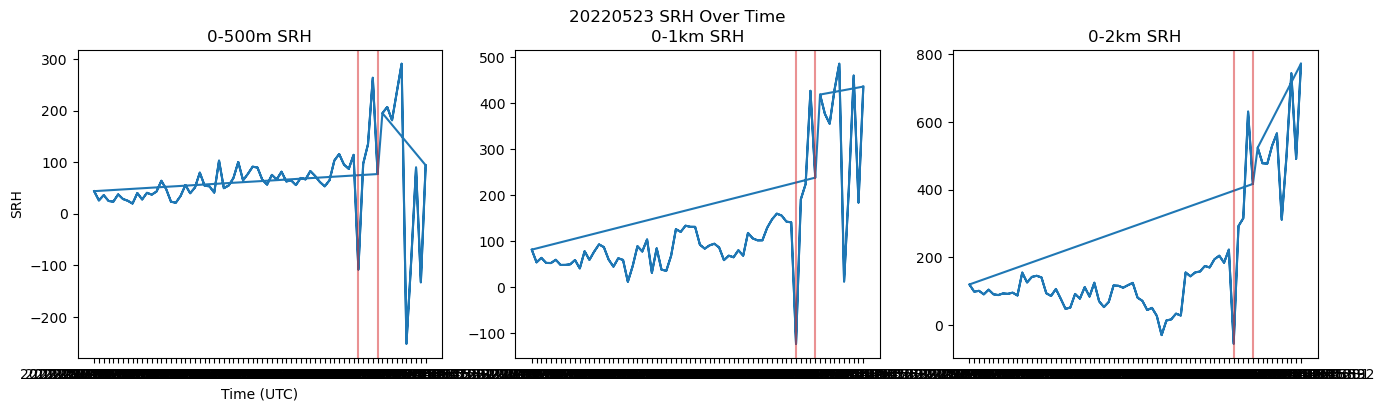

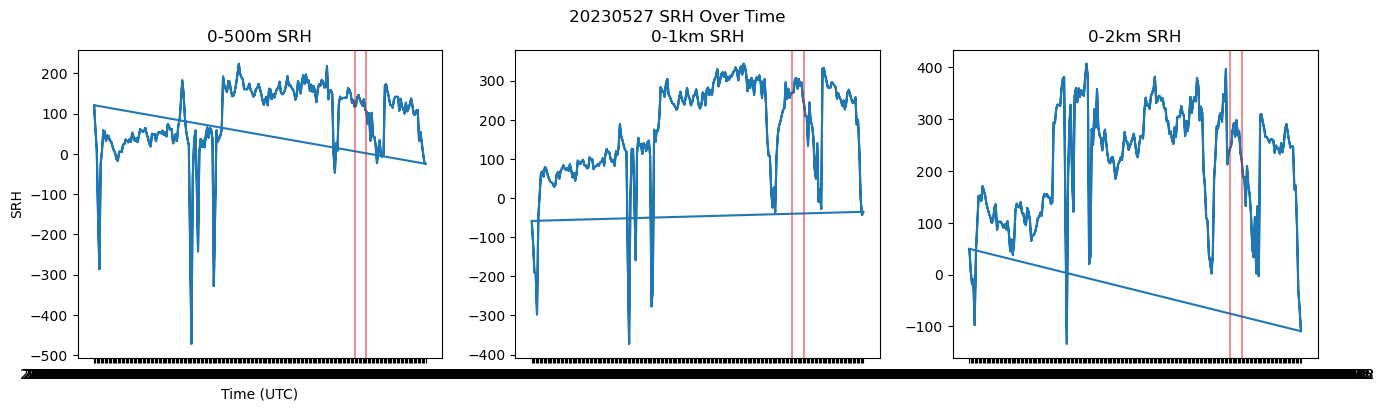

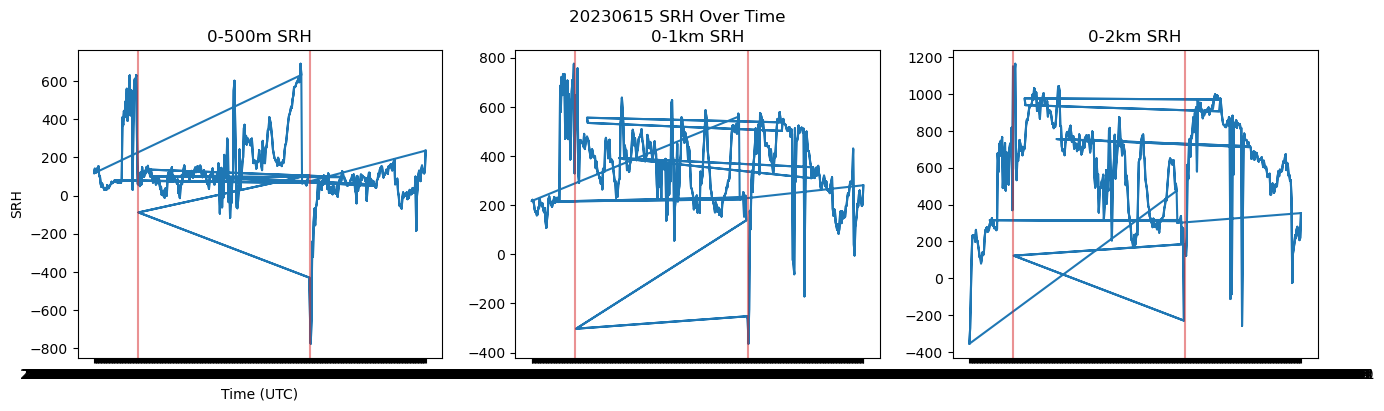

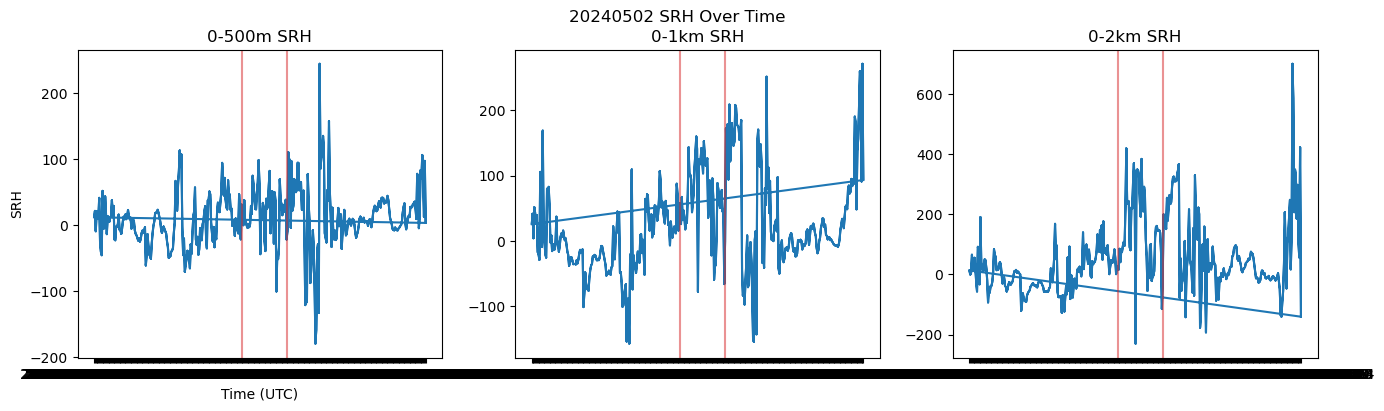

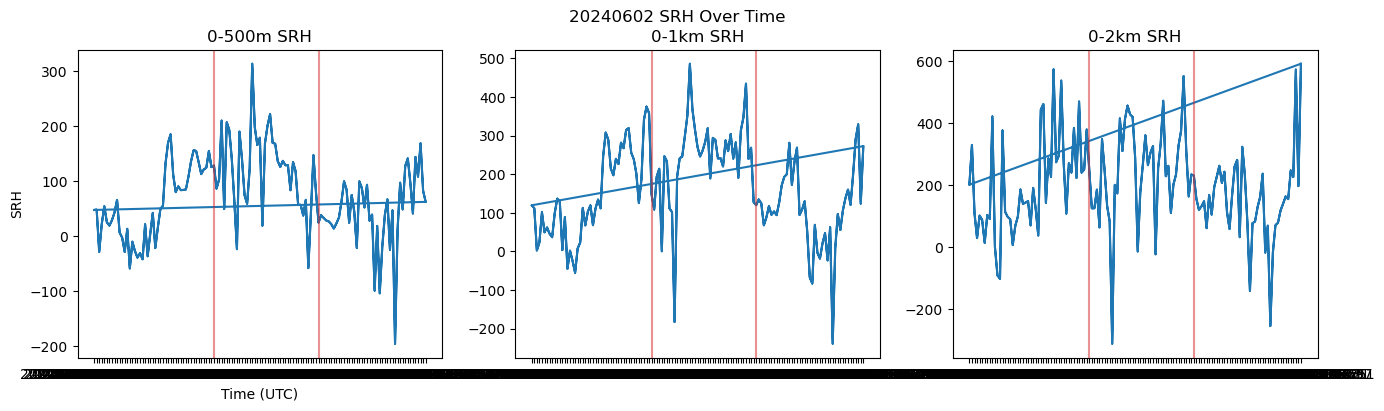

In [328]:
from seaborn import objects
import warnings
warnings.filterwarnings('ignore')
n = 10

for d in sorted(set(df_all_new['Date'])):
    if df_all_new[df_all_new['Date'] == d]['Time From Tor (min)'].ne('nontor').any():
        df = df_all_new[df_all_new['Date'] == d]
        
        if not df[df['Time From Tor (min)'] == 0].empty:
            tor_start_idx = np.where(df['Time From Tor (min)'] == 0)
            #tor_end_idx = np.where(df['Time From Tor (min)'] == 0)
            tor_start = df['Datetime'].iloc[tor_start_idx[0]].reset_index(drop=True)
            #tor_end = df['Datetime'].iloc[tor_start_idx[0][-1]]
            
            # ax0.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            # ax0.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
            # ax0.set_ylabel(col)
            # ax0.set_xlabel('Time (UTC)')
            # plt.suptitle(f'{d} {col} Tor')
            
            #df = df_all_new[df_all_new['Date'] == d]
            fig, (ax0, ax1, ax2) = plt.subplots(nrows=1, ncols=3, figsize=(16,4))
            #p = sns.objects.Plot(data = df, x="Datetime", y="0-2km SRH").add(sns.objects.Line()).label(title=f'{d} 0-2km SRH Nontor')
            ax0.plot(df['Datetime'], df['0-500m SRH'])
            #ax0.xticks(df['Datetime'][::20], rotation=45, ha='right')
            ax0.set_title('0-500m SRH')
        
            ax1.plot(df['Datetime'], df['0-1km SRH'])
            #ax1.xticks(df['Datetime'][::20], rotation=45, ha='right')
            ax1.set_title('0-1km SRH')
        
            ax2.plot(df['Datetime'], df['0-2km SRH'])
            #ax2.xticks(df['Datetime'][::20], rotation=45, ha='right')
            ax2.set_title('0-2km SRH')
        
            # ax3.plot(df['Datetime'], df['0-2km SRW Mag'])
            # ax3.set_title('0-2km SRW Mag')
            #ax3.xticks(df['Datetime'][::20], rotation=45, ha='right')
            #plt.setp(plot.axes.get_xticklabels(), visible=False)
            #plt.setp(plot.axes.get_xticklabels()[::5], visible=True)

            ax0.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            ax0.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
            ax0.set_ylabel('SRH')
            ax0.set_xlabel('Time (UTC)')

            ax1.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            ax1.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)

            ax2.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            ax2.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
            
            # ax2.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            # ax2.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)

            # ax3.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            # ax3.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
            
            plt.suptitle(f'{d} SRH Over Time')

            plt.show()
            
        # if not df[df['Time From Tor (min)'] == 0].empty:
        #     tor_start_idx = np.where(df['Time From Tor (min)'] == 0)
        #     #tor_end_idx = np.where(df['Time From Tor (min)'] == 0)
        #     tor_start = df['Datetime'].iloc[tor_start_idx[0]].reset_index(drop=True)
        #     #tor_end = df['Datetime'].iloc[tor_start_idx[0][-1]]
            
        #     plt.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
        #     plt.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
        #     plt.ylabel(col)
        #     plt.xlabel('Time (UTC)')
        #     plt.title(f'{d} {col} Tor')
            
        #     plt.show()
            
        # else:
        #     plt.show()

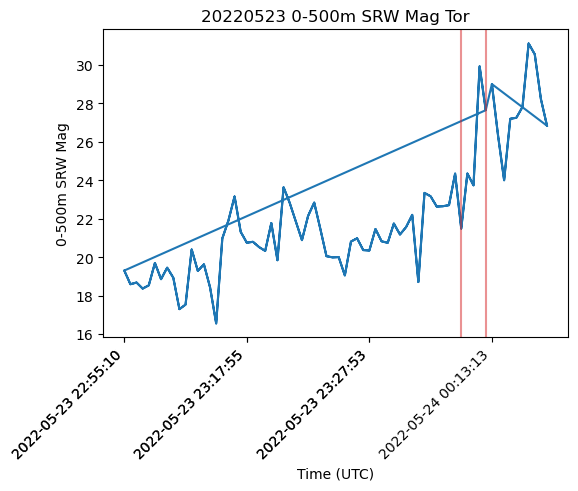

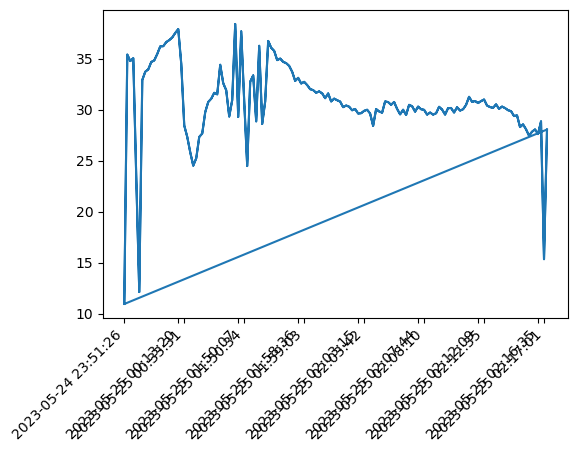

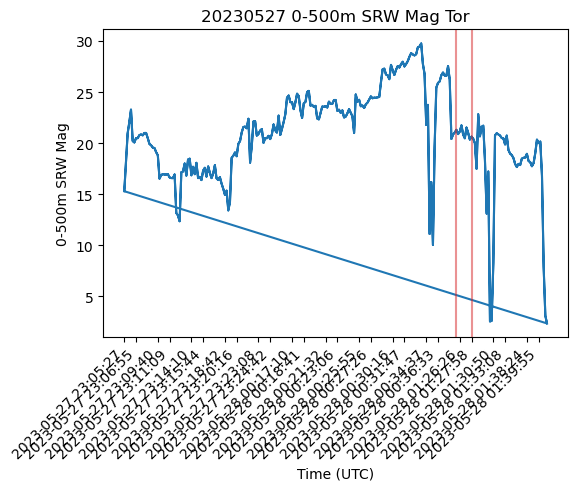

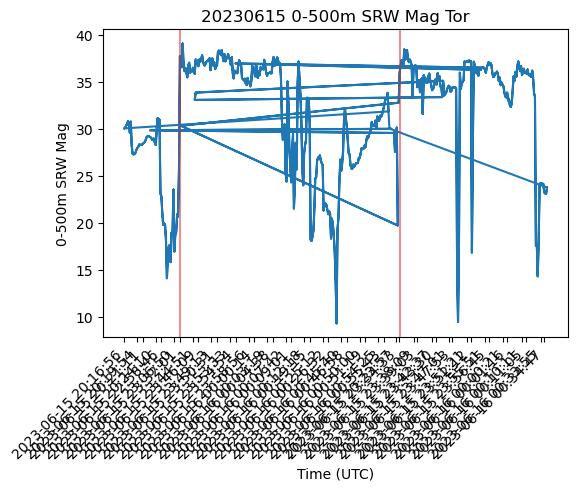

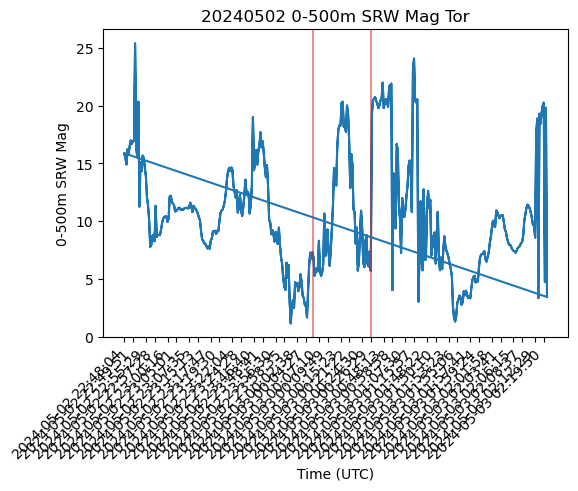

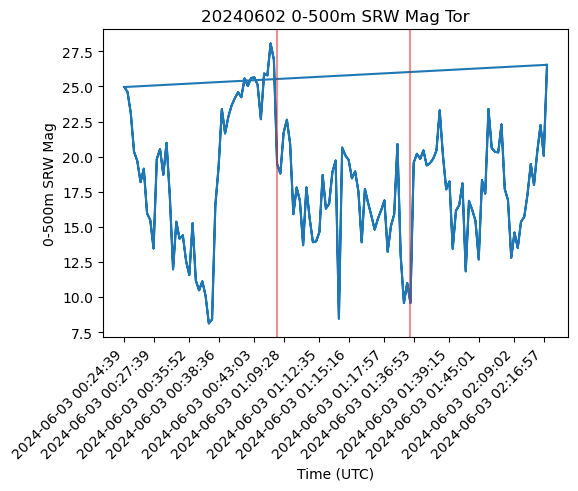

In [305]:
from seaborn import objects
import warnings
warnings.filterwarnings('ignore')
col = '0-500m SRW Mag'
n = 10
for d in sorted(set(df_all_new['Date'])):
    if df_all_new[df_all_new['Date'] == d]['Time From Tor (min)'].ne('nontor').any():
        df = df_all_new[df_all_new['Date'] == d]
        fig = plt.figure(figsize=(6,4))
        #p = sns.objects.Plot(data = df, x="Datetime", y="0-2km SRH").add(sns.objects.Line()).label(title=f'{d} 0-2km SRH Nontor')
        plot = plt.plot(df['Datetime'], df[col])
        plt.xticks(df['Datetime'][::20], rotation=45, ha='right')
        #plt.setp(plot.axes.get_xticklabels(), visible=False)
        #plt.setp(plot.axes.get_xticklabels()[::5], visible=True)
        if not df[df['Time From Tor (min)'] == 0].empty:
            tor_start_idx = np.where(df['Time From Tor (min)'] == 0)
            #tor_end_idx = np.where(df['Time From Tor (min)'] == 0)
            tor_start = df['Datetime'].iloc[tor_start_idx[0]].reset_index(drop=True)
            #tor_end = df['Datetime'].iloc[tor_start_idx[0][-1]]
            
            plt.axvline(tor_start.iloc[0], color='tab:red', alpha=0.5)
            plt.axvline(tor_start.iloc[-1], color='tab:red', alpha=0.5)
            plt.ylabel(col)
            plt.xlabel('Time (UTC)')
            plt.title(f'{d} {col} Tor')
            
            plt.show()
            
        else:
            plt.show()

# Mesocyclone strength

In [ ]:
def meso_stats_get(meso_stats, features_shear_xr, d, meso_id, df_all_new):
    meso_max = []
    dates = []
    if not isinstance(meso_id, (list, set)):
        meso_id = [meso_id]
        
        meso_indeces = tobac_features_xr_shear['cell'].where(tobac_features_xr_shear['cell'].isin(meso_id), drop=True)
    
    meso_ids = meso_indeces.index
    
    if not isinstance(meso_ids, (list, set)):
        meso_ids = [meso_ids]
        
        meso_indeces2 = meso_stats['idx'].index.where(meso_stats['idx'].index.isin(meso_ids), drop=True)
    
    meso_ids_stats = meso_indeces2.index

    nearest_vad_time_idx = []
    
    df_all_new_date = df_all_new[df_all_new['Date'] == d]

    #df_datetime = pd.to_datetime(df_all_new_date['Datetime'])
    
    for i in df_all_new_date['Datetime']:
        timet = meso_stats['time'].to_pandas()    
        time = pd.to_datetime(timet)
        dt_df = pd.Series(i)
        dta = pd.to_datetime(dt_df)
        dt = np.array(dta)
        nearest_vad_time = find_nearest(time, dt)
        nearest_vad_time_idx.append(nearest_vad_time)

    # timet = meso_stats['time'].to_pandas()
    # for i in timet:
    #     #timet = meso_stats['time'].to_pandas()
    #     # for t in timet:
    #     #     t0 = datetime.strptime(t, '%Y-%m-%d %H:%M:%S')
    #     #     t1 = np.array(t0)
    #     #     t2 = t1.astype('datetime64[ns]')
            
    #     #time = pd.to_datetime(i)
    #     #dt = datetime.fromtimestamp(dt_ts)
    #     #dt = to_dt[i]
    #     #dt_strp = datetime.strptime(i, '%Y-%m-%d %H:%M:%S')
    #     #dt_array = np.array(dt_strp)
    #     #dt = dt_array.astype('datetime64[ns]')
    #     time_df = pd.Series(i)
    #     timea = pd.to_datetime(time_df)
    #     time = np.array(timea)
    #     #dta = pd.to_datetime(dt_df)
    #     #dt = np.array(dta)
    #     df_datetime = pd.to_datetime(df_all_new_date['Datetime'])
    #     #print(f'i dtype: {dt.dtype}')
    #     #print((df_datetime).dtype)
    #     #print(f'time dtype: {(time).dtype}')
        
    #     #print(f'time shape:{np.shape(time)}')
    #     #print(f'i shape:{np.shape(dt)}')
    #     nearest_vad_time = find_nearest(df_datetime, time)
        #nearest_vad_time_idx.append(nearest_vad_time)
    
    wanted_meso_max = meso_stats['max'][meso_ids_stats].values
    meso_max.append(wanted_meso_max)
    wanted_meso_max_nearest = meso_stats['max'][nearest_vad_time_idx].values
    dates.append(d)

    time = meso_stats['time'][nearest_vad_time_idx]

    fig = plt.figure()
    plt.plot(meso_stats['time'][meso_ids_stats], wanted_meso_max)
    plt.title(f'Maximum Azimuthal Shear Over Time Of Target Mesocyclones {d}')
    plt.xlabel('Time')
    plt.ylabel('Azshear')
    plt.show()

    return wanted_meso_max_nearest, dates, time

In [ ]:
dates = ['20220523', '20220524','20220611','20230524', '20230527', '20230601', '20230609',
        '20230611', '20230612', '20230613','20230615', '20240427', '20240501', '20240502', '20240504', '20240506', '20240519'
          '20240523', '20240528', '20240602']

In [ ]:
meso_ids_dict = {
    
    '20220523': [8, 24, 44, 10, 26],
    '20220524': [1, 11],
    '20220611': [9, 18, 59, 119, 186, 236, 289, 427],
    '20230524': [8, 27],
    '20230527': [8,16, 36, 57],
    '20230601': [3, 5],
    '20230609': [1, 13, 15],
    '20230611': [13, 27, 43,55, 80, 82, 84, 145, 162],
    '20230612': [21, 32, 81, 106, 136],
    '20230613': [1],
    '20230615': [201, 481, 749, 1178],
    '20240427': [15, 191, 506],
    '20240502': [1, 23, 38, 58],
    '20240504': [15, 192, 224, 311],
    '20240519': [3, 9, 12, 27, 29, 43],
    '20240523': [1, 10, 17, 20],
    '20240528': [49, 194, 237, 308],
    '20240602': [1, 5, 8]
}
    


In [ ]:
meso_azshear_df = pd.DataFrame()

for key in meso_ids_dict:
    d = key
    print(d)
    meso_id = np.array(meso_ids_dict[d])
    print(meso_id)
    meso_stats = xr.open_dataset(f'/Users/juliabman/Desktop/research2024/tobac_Save/{d}_tobac_Plot/{d}_Features_shear.nc')
    tobac_features_xr_shear = xr.open_dataset(f'/Users/juliabman/Desktop/research2024/tobac_Save/{d}_tobac_Plot/{d}_Track_shear.nc')
    # tobac_df_shear = tobac_id(tobac_features_xr_shear, meso_id)
    # latitude_weighted_tobac_meso, longitude_weighted_tobac_meso, meso_bearing, meso_speed, meso_times = storm_speed_and_bearing(tobac_df_shear, weights)
    # meso_vad_times, meso_times, meso_indeces, meso_lats, meso_lons = nearest_tobac_time(easterlies_vads, 
    #                                                                            np.array(latitude_weighted_tobac_meso),
    #                                                                            np.array(longitude_weighted_tobac_meso),
    #                                                                            meso_times[:-1])
    meso_max, dates, time = meso_stats_get(meso_stats, tobac_features_xr_shear, d, meso_id, df_all_new)

    df = pd.DataFrame()
    df['Time'] = time
    print(np.shape(time))
    df['Meso_Max'] = pd.Series(np.array(meso_max).flatten())
    print(np.shape(df['Meso_Max']))
    df['Date'] = dates * np.size(df['Meso_Max'])

    meso_azshear_df = pd.concat([meso_azshear_df, df])

In [ ]:
meso_azshear_df

In [ ]:
df_all_new

In [ ]:
import matplotlib.colors as mcolors
#title = f'{d} 0-2km SRH Per VAD'
vmax = 30
vmin = 0
from matplotlib import rcParams, rcParamsDefault
rcParams.update(rcParamsDefault)

max_radius = 60
#vmin = 0
#vmax = 30
for d in sorted(set(meso_azshear_df['Date'])):
    
    col = '0'
    # Create two subplots side by side
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, subplot_kw={'projection': 'polar'}, figsize=(13, 5))
    plt.subplots_adjust(wspace=0.3)  # Adjust space between subplots
    
    # ========== First Subplot (Tornadic VADs) ==========
    ax0.set_rlabel_position(-22.5)
    ax0.grid(True, linestyle=':')
    # ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
    ax0.set_theta_zero_location('E')
    ax0.set_theta_direction(-1)
    ax0.set_ylim([0, max_radius])
    
    # Shade regions
    nf0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
    ff0 = ax0.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')

    df_all_new_d = df_all_new[df_all_new['Date'] == d]
    #df_all_new_tor = df_all_new[df_all_new['Time From Tor (min)'] != 'nontor']
    u = df_all_new_d[df_all_new_d['u or v'] == 'u']
    v = df_all_new_d[df_all_new_d['u or v'] == 'v']

    print(f'u shape: {np.shape(u)}')

    meso_d = meso_azshear_df[meso_azshear_df['Date'] == d]
    meso_max = meso_d['Meso_Max']
    
    print(f' meso shape: {np.shape(meso_max)}')
    
    # Compute wind speed
    ta = np.nansum([t_u[col]**2, t_v[col]**2], axis=0)
    tspeed = np.sqrt(ta)
    
    # Get Py-ART colormap
    #cmap = pyart.graph.cm.pyart_BuDRd18
    
    # Normalize speed for colormap (adjust vmin/vmax as needed)
    norm = mcolors.Normalize(vmin=np.min(tspeed), vmax=np.max(tspeed))
    sm = plt.cm.ScalarMappable(cmap='pyart_BuDRd18', norm=norm)  # For colorbar
    tcolors = sm.to_rgba(tspeed)
    # Tornadic points
    points = ax0.barbs(u['Angle'][::10] * (np.pi/180), u['Distance'][::10], 
                              u[col][::10], v[col][::10], meso_d['Meso_Max'][::10], cmap='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))

    if df_all_new_d['Time From Tor (min)'].ne('nontor').any():
        ax0.set_title(f'All Tor {d} Per VAD')

    else:
        ax0.set_title(f'All NonTor {d} Per VAD')
    
    # ax1.set_rlabel_position(-22.5)
    # ax1.grid(True, linestyle=':')
    # # ax0.set_title('Tornadic VADs', fontsize=13, fontweight='bold')
    # ax1.set_theta_zero_location('E')
    # ax1.set_theta_direction(-1)
    # ax1.set_ylim([0, max_radius])
    # # Shade regions
    # nf1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='gray', alpha=0.5, label='Near-field')
    # ff1 = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='lightgrey', alpha=0.3, label='Far-field')
    
    
    # df_all_new_nontor = df_all_new[df_all_new['Time From Tor (min)'] == 'nontor']
    # nt_u = df_all_new_nontor[df_all_new_nontor['u or v'] == 'u']
    # nt_v = df_all_new_nontor[df_all_new_nontor['u or v'] == 'v']
    
    # # Compute wind speed
    # nta = np.nansum([nt_u[col]**2, nt_v[col]**2], axis=0)
    # ntspeed = np.sqrt(nta)
    
    # nontor_points = ax1.barbs(nt_u['Angle'][::10] * (np.pi/180), nt_u['Distance'][::10], 
    #                          nt_u[col][::10], nt_v[col][::10], ntspeed[::10], cmap ='pyart_BuDRd18', length=5, sizes=dict(spacing=0.2))
    # ax1.set_title(f'All Nontor {col} Per VAD')
    
    # nf = ax1.fill_between(np.linspace(0, np.pi/2), 0, 20, color='orange', alpha=0.5, label='Near-field')
    # ff = ax1.fill_between(np.linspace(0, np.pi/2), 0, max_radius, color='pink', alpha=0.3, label='Far-field')
    
    theta_start = np.deg2rad(100)
    ax0.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
    ax0.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
    
    # ax1.quiver(theta_start, 0.5, 20, 0, scale_units='xy', scale=0.2, color='black', label='Storm Motion')
    # ax1.scatter(0, 0, color='black', marker='x', label='Mesocyclone', s=400, linewidths=4)
        
    # Colorbar
    cbar = fig.colorbar(tor_points, ax=[ax1], pad=0.1, shrink=0.8)
    cbar.set_label('Meso AzShear (s$^{-1})$')
    
    #plt.suptitle(title, fontsize=13, fontweight='bold', ha='center')
    # Legend
    #plt.legend([nf, ff], ['Near-Field', 'Far-Field'], loc='upper left', fontsize=11)
    # plt.legend([storm_motion, nf, ff, meso], 
               #['Storm Motion', 'Near-Field', 'Far-Field', 'Mesocyclone'], loc = 'upper right', fontsize=11)
    
    #plt.savefig(f'/Users/juliabman/Desktop/spring2025_seminar/NontorvsTorPolarPlotsSRW', bbox_inches='tight')
    #fig.tight_layout()
    #plt.tight_layout()
    plt.suptitle('SFC SRW Every 10 points')
    plt.show()